<a href="https://colab.research.google.com/github/phuongtrang1301-maker/Trang-Portfolio/blob/main/Electricity_729_Powell_Model_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# FULL END-TO-END CODE (FOR YOUR EXACT FILES)
# Model: Electricity = BaseLoad + ProductionLoad + SecondaryLoad
# BaseLoad      -> billing DAYS
# ProductionLoad-> production KG
# SecondaryLoad -> runtime on secondary lines (115–118)
# ============================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================
# CONFIG - UPDATE THESE PATHS
# =========================
QTY_2024     = "/content/Quantity 2024.xlsx"
QTY_2025     = "/content/Quantity 2025.xlsx"
OP_2024      = "/content/Operation 2024.xlsx"
OP_2025      = "/content/Operation 2025.xlsx"
POWELL_UTIL  = "/content/Powell Utilities.xlsx"

ITEM_LEDGER_SHEET = "Item Ledger Entries"
ELECTRICITY_SHEET = "Electricity"   # 729 Powell inside Powell Utilities

SECONDARY_LINES = {"115", "116", "117", "118"}

# Production column preference order
PROD_COL_CANDIDATES = [
    "2. Total Weight (kg)",   # Quantity 2024/2025 (your files)
    "exclude 12022",
    "KG only",
    "Total Weight (kg)",
    "FG Total Weight",
    "3. FG Total Weight (kg and Ltr)",
    "Tray in KG & 12022 Ltrs"
]

# Electricity column candidates
ELEC_START_CANDS = ["Start Date", "Start", "From", "Bill Start", "StartDate"]
ELEC_END_CANDS   = ["End Date", "End", "To", "Bill End", "EndDate"]
ELEC_KWH_CANDS   = ["Energy Used", "Energy Used (kWh)", "kWh", "KWH", "Usage (kWh)", "Consumption (kWh)"]

# Capacity Ledger column candidates
CAP_POSTING_DATE_CANDS = ["Posting Date", "Posting date", "Date"]
CAP_NO_CANDS           = ["No.", "No", "Line Code", "Line code", "Work Center No.", "Machine No."]
CAP_RUN_CANDS          = ["Run Time", "Run time", "Run Time (Min.)", "Run Time (Minutes)", "RunTime"]
CAP_SETUP_CANDS        = ["Setup Time", "Setup time", "Setup Time (Min.)", "Setup Time (Minutes)", "SetupTime"]


# =========================
# UTILS
# =========================
def _normalize_cols(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def _pick_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}' column. Tried: {candidates}\nAvailable: {list(df.columns)}")

def read_sheet_with_header_search(xlsx_path, sheet_name, key="Posting Date", scan_rows=80):
    """
    Handles messy sheets where the true header isn't row 1 (common in Quantity exports).
    Finds the row containing `key` and uses it as header.
    """
    raw = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=None)

    header_row = None
    for i in range(min(scan_rows, len(raw))):
        row_vals = raw.iloc[i].astype(str).str.strip()
        if (row_vals == key).any():
            header_row = i
            break

    if header_row is None:
        raise ValueError(
            f"Could not find a header row containing '{key}' in {xlsx_path}::{sheet_name}.\n"
            f"Tip: open Excel and confirm the exact header text."
        )

    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=header_row)
    df = _normalize_cols(df)
    return df

def get_capacity_sheet_name(op_path):
    """
    For your exact situation:
    - Operation 2025 has: 'Capacity Ledger Entries'
    - Operation 2024 has: 'Capapcity Ledger Entries' (misspelled)
    """
    xl = pd.ExcelFile(op_path)
    sheets = xl.sheet_names

    if "Capacity Ledger Entries" in sheets:
        return "Capacity Ledger Entries"
    if "Capapcity Ledger Entries" in sheets:
        return "Capapcity Ledger Entries"

    raise ValueError(f"Capacity Ledger sheet not found in {op_path}. Available sheets: {sheets}")

def sum_over_window(daily_df, date_col, value_cols, start, end):
    mask = (daily_df[date_col] >= start) & (daily_df[date_col] <= end)
    return daily_df.loc[mask, value_cols].sum(numeric_only=True)


# =========================
# 1) PRODUCTION (DAILY)
# =========================
def load_production_daily(xlsx_path):
    df = read_sheet_with_header_search(xlsx_path, ITEM_LEDGER_SHEET, key="Posting Date")
    df = _normalize_cols(df)

    df["Posting Date"] = pd.to_datetime(df["Posting Date"], errors="coerce")
    df = df.dropna(subset=["Posting Date"])

    weight_col = None
    for c in PROD_COL_CANDIDATES:
        if c in df.columns:
            weight_col = c
            break
    if weight_col is None:
        raise ValueError(
            f"[{xlsx_path}] Could not find production KG column.\n"
            f"Tried: {PROD_COL_CANDIDATES}\nAvailable: {list(df.columns)}"
        )

    print(f"[Production] {xlsx_path} -> using '{weight_col}'")

    df["production_kg"] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

    daily = df.groupby("Posting Date", as_index=False)["production_kg"].sum()
    return daily


# =========================
# 2) RUNTIME (DAILY, SPLIT PRIMARY/SECONDARY)
# =========================
def load_runtime_daily(op_path):
    cap_sheet = get_capacity_sheet_name(op_path)
    print(f"[Runtime] {op_path} -> using sheet '{cap_sheet}'")

    df = pd.read_excel(op_path, sheet_name=cap_sheet)
    df = _normalize_cols(df)

    posting_col = _pick_col(df, CAP_POSTING_DATE_CANDS, "Posting Date")
    no_col      = _pick_col(df, CAP_NO_CANDS, "No. (line code)")
    run_col     = _pick_col(df, CAP_RUN_CANDS, "Run Time")
    setup_col   = _pick_col(df, CAP_SETUP_CANDS, "Setup Time")

    df["Posting Date"] = pd.to_datetime(df[posting_col], errors="coerce")
    df = df.dropna(subset=["Posting Date"])

    df["No."] = df[no_col].astype(str).str.strip()

    df["runtime"] = (
        pd.to_numeric(df[run_col], errors="coerce").fillna(0) +
        pd.to_numeric(df[setup_col], errors="coerce").fillna(0)
    )

    df["stage"] = np.where(df["No."].isin(SECONDARY_LINES), "secondary", "primary")

    out = (
        df.groupby(["Posting Date", "stage"])["runtime"]
          .sum()
          .unstack(fill_value=0)
          .reset_index()
          .rename(columns={"primary": "runtime_primary", "secondary": "runtime_secondary"})
    )

    if "runtime_primary" not in out.columns:
        out["runtime_primary"] = 0.0
    if "runtime_secondary" not in out.columns:
        out["runtime_secondary"] = 0.0

    return out[["Posting Date", "runtime_primary", "runtime_secondary"]]


# =========================
# 3) ELECTRICITY (BILLING PERIOD)
# =========================
def load_electricity_periods(util_path):
    df = pd.read_excel(util_path, sheet_name=ELECTRICITY_SHEET)
    df = _normalize_cols(df)

    start_col = _pick_col(df, ELEC_START_CANDS, "Start Date")
    end_col   = _pick_col(df, ELEC_END_CANDS, "End Date")
    kwh_col   = _pick_col(df, ELEC_KWH_CANDS, "Energy Used (kWh)")

    df["Start Date"] = pd.to_datetime(df[start_col], errors="coerce")
    df["End Date"]   = pd.to_datetime(df[end_col], errors="coerce")
    df["kwh"]        = pd.to_numeric(df[kwh_col], errors="coerce").fillna(0)

    df = df.dropna(subset=["Start Date", "End Date"])
    df["days"] = (df["End Date"] - df["Start Date"]).dt.days + 1

    print(f"[Electricity] Start='{start_col}', End='{end_col}', kWh='{kwh_col}'")

    return df[["Start Date", "End Date", "days", "kwh"]].sort_values(["Start Date", "End Date"]).reset_index(drop=True)


# =========================
# 4) BUILD MODEL TABLE BY BILLING PERIOD
# =========================
def build_model_table(prod_daily, runtime_daily, elec_periods):
    daily = prod_daily.merge(runtime_daily, on="Posting Date", how="outer").fillna(0).sort_values("Posting Date")

    rows = []
    for _, r in elec_periods.iterrows():
        start, end = r["Start Date"], r["End Date"]

        prod_sum = sum_over_window(daily, "Posting Date", ["production_kg"], start, end)["production_kg"]
        run_sums = sum_over_window(daily, "Posting Date", ["runtime_secondary", "runtime_primary"], start, end)

        rows.append({
            "start": start,
            "end": end,
            "days": float(r["days"]),
            "kwh": float(r["kwh"]),
            "production_kg": float(prod_sum),
            "runtime_secondary": float(run_sums.get("runtime_secondary", 0.0)),
            "runtime_primary": float(run_sums.get("runtime_primary", 0.0)),  # diagnostic only
        })

    return pd.DataFrame(rows)


# =========================
# 5) RUN PIPELINE + REGRESSION
# =========================
# Production (daily)
prod_daily = pd.concat(
    [load_production_daily(QTY_2024), load_production_daily(QTY_2025)],
    ignore_index=True
).groupby("Posting Date", as_index=False)["production_kg"].sum()

# Runtime (daily)
runtime_daily = pd.concat(
    [load_runtime_daily(OP_2024), load_runtime_daily(OP_2025)],
    ignore_index=True
).groupby("Posting Date", as_index=False)[["runtime_primary", "runtime_secondary"]].sum()

# Electricity billing periods
elec_periods = load_electricity_periods(POWELL_UTIL)

# Build billing-aligned dataset
model_df = build_model_table(prod_daily, runtime_daily, elec_periods)

print("\n=== Model DF preview ===")
print(model_df.head(10))

# =========================
# REGRESSION: Electricity = BaseLoad + ProductionLoad + SecondaryLoad
# =========================
X = model_df[["days", "production_kg", "runtime_secondary"]].copy()
X = sm.add_constant(X)
y = model_df["kwh"]

model = sm.OLS(y, X).fit()

print("\n=== Regression Summary ===")
print(model.summary())

coef = model.params.to_dict()
print("\n=== Coefficients (for interpretation) ===")
print(f"Intercept (kWh): {coef.get('const', np.nan):,.2f}")
print(f"BaseLoad per day (kWh/day): {coef.get('days', np.nan):,.6f}")
print(f"ProductionLoad per kg (kWh/kg): {coef.get('production_kg', np.nan):,.9f}")
print(f"SecondaryLoad per runtime unit (kWh/runtime): {coef.get('runtime_secondary', np.nan):,.9f}")

# Predictions + residuals
model_df["kwh_pred"] = model.predict(X)
model_df["residual"] = model_df["kwh"] - model_df["kwh_pred"]

print("\n=== Prediction Check (last 10 rows) ===")
print(model_df[["start","end","kwh","kwh_pred","residual","days","production_kg","runtime_secondary"]].tail(10))

# Optional export
# model_df.to_excel("/content/powell_729_model_df.xlsx", index=False)
# print("Saved: /content/powell_729_model_df.xlsx")

[Production] /content/Quantity 2024.xlsx -> using '2. Total Weight (kg)'
[Production] /content/Quantity 2025.xlsx -> using '2. Total Weight (kg)'
[Runtime] /content/Operation 2024.xlsx -> using sheet 'Capapcity Ledger Entries'
[Runtime] /content/Operation 2025.xlsx -> using sheet 'Capacity Ledger Entries'
[Electricity] Start='Start Date', End='End Date', kWh='Energy Used'

=== Model DF preview ===
       start        end  days       kwh  production_kg  runtime_secondary  \
0 2024-01-03 2024-01-31  29.0  120960.0      296447.97            45811.0   
1 2024-02-01 2024-03-01  30.0  116160.0      265450.38            41381.0   
2 2024-03-02 2024-03-31  30.0  108000.0      237767.23            41001.0   
3 2024-04-01 2024-04-02   2.0    7440.0       10840.55              180.0   
4 2024-04-03 2024-05-01  29.0   99840.0      210483.76            33532.0   
5 2024-05-02 2024-05-31  30.0  118800.0      276501.35            43674.0   
6 2024-06-01 2024-07-02  32.0  127200.0      254643.53      

In [ ]:
# ============================================
# FULL END-TO-END CODE (PRIMARY + SECONDARY LINES)
# Powell 729 Electricity Model
#
# Stages:
#   Primary lines   = 110, 111, 112, 113
#   Secondary lines = 115, 116, 117, 118
#   Other lines     = everything else (tracked as runtime_other)
#
# Models you can run at the end:
#   A) kwh ~ days + production_kg + runtime_secondary   (Base + Production + Secondary)
#   B) kwh ~ days + runtime_primary + runtime_secondary (Base + Primary + Secondary)
#   C) kwh ~ days + production_kg + runtime_primary + runtime_secondary + runtime_other (Full)
# ============================================

import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================
# CONFIG - UPDATE THESE PATHS
# =========================
QTY_2024     = "/content/Quantity 2024.xlsx"
QTY_2025     = "/content/Quantity 2025.xlsx"
OP_2024      = "/content/Operation 2024.xlsx"
OP_2025      = "/content/Operation 2025.xlsx"
POWELL_UTIL  = "/content/Powell Utilities.xlsx"

ITEM_LEDGER_SHEET = "Item Ledger Entries"
ELECTRICITY_SHEET = "Electricity"   # 729 Powell inside Powell Utilities

PRIMARY_LINES   = {"110", "111", "112", "113"}
SECONDARY_LINES = {"115", "116", "117", "118"}

# Production column preference order (robust across your Quantity layouts)
PROD_COL_CANDIDATES = [
    "2. Total Weight (kg)",   # your Quantity files
    "exclude 12022",
    "KG only",
    "Total Weight (kg)",
    "FG Total Weight",
    "3. FG Total Weight (kg and Ltr)",
    "Tray in KG & 12022 Ltrs"
]

# Electricity column candidates
ELEC_START_CANDS = ["Start Date", "Start", "From", "Bill Start", "StartDate"]
ELEC_END_CANDS   = ["End Date", "End", "To", "Bill End", "EndDate"]
ELEC_KWH_CANDS   = ["Energy Used", "Energy Used (kWh)", "kWh", "KWH", "Usage (kWh)", "Consumption (kWh)"]

# Capacity Ledger column candidates
CAP_POSTING_DATE_CANDS = ["Posting Date", "Posting date", "Date"]
CAP_NO_CANDS           = ["No.", "No", "Line Code", "Line code", "Work Center No.", "Machine No."]
CAP_RUN_CANDS          = ["Run Time", "Run time", "Run Time (Min.)", "Run Time (Minutes)", "RunTime"]
CAP_SETUP_CANDS        = ["Setup Time", "Setup time", "Setup Time (Min.)", "Setup Time (Minutes)", "SetupTime"]


# =========================
# UTILS
# =========================
def _normalize_cols(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def _pick_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}' column. Tried: {candidates}\nAvailable: {list(df.columns)}")

def read_sheet_with_header_search(xlsx_path, sheet_name, key="Posting Date", scan_rows=80):
    """
    Handles messy sheets where the true header isn't row 1 (common in Quantity exports).
    Finds the row containing `key` and uses it as header.
    """
    raw = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=None)

    header_row = None
    for i in range(min(scan_rows, len(raw))):
        row_vals = raw.iloc[i].astype(str).str.strip()
        if (row_vals == key).any():
            header_row = i
            break

    if header_row is None:
        raise ValueError(
            f"Could not find a header row containing '{key}' in {xlsx_path}::{sheet_name}.\n"
            f"Tip: open Excel and confirm the exact header text."
        )

    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, header=header_row)
    df = _normalize_cols(df)
    return df

def get_capacity_sheet_name(op_path):
    """
    Your exact situation:
      - Operation 2024: 'Capapcity Ledger Entries' (misspelled)
      - Operation 2025: 'Capacity Ledger Entries'
    """
    xl = pd.ExcelFile(op_path)
    sheets = xl.sheet_names

    if "Capacity Ledger Entries" in sheets:
        return "Capacity Ledger Entries"
    if "Capapcity Ledger Entries" in sheets:
        return "Capapcity Ledger Entries"

    raise ValueError(f"Capacity Ledger sheet not found in {op_path}. Available sheets: {sheets}")

def sum_over_window(daily_df, date_col, value_cols, start, end):
    mask = (daily_df[date_col] >= start) & (daily_df[date_col] <= end)
    return daily_df.loc[mask, value_cols].sum(numeric_only=True)


# =========================
# 1) PRODUCTION (DAILY)
# =========================
def load_production_daily(xlsx_path):
    df = read_sheet_with_header_search(xlsx_path, ITEM_LEDGER_SHEET, key="Posting Date")
    df = _normalize_cols(df)

    df["Posting Date"] = pd.to_datetime(df["Posting Date"], errors="coerce")
    df = df.dropna(subset=["Posting Date"])

    weight_col = None
    for c in PROD_COL_CANDIDATES:
        if c in df.columns:
            weight_col = c
            break
    if weight_col is None:
        raise ValueError(
            f"[{xlsx_path}] Could not find production KG column.\n"
            f"Tried: {PROD_COL_CANDIDATES}\nAvailable: {list(df.columns)}"
        )

    print(f"[Production] {xlsx_path} -> using '{weight_col}'")

    df["production_kg"] = pd.to_numeric(df[weight_col], errors="coerce").fillna(0)

    daily = df.groupby("Posting Date", as_index=False)["production_kg"].sum()
    return daily


# =========================
# 2) RUNTIME (DAILY, SPLIT PRIMARY/SECONDARY/OTHER)
# =========================
def load_runtime_daily(op_path):
    cap_sheet = get_capacity_sheet_name(op_path)
    print(f"[Runtime] {op_path} -> using sheet '{cap_sheet}'")

    df = pd.read_excel(op_path, sheet_name=cap_sheet)
    df = _normalize_cols(df)

    posting_col = _pick_col(df, CAP_POSTING_DATE_CANDS, "Posting Date")
    no_col      = _pick_col(df, CAP_NO_CANDS, "No. (line code)")
    run_col     = _pick_col(df, CAP_RUN_CANDS, "Run Time")
    setup_col   = _pick_col(df, CAP_SETUP_CANDS, "Setup Time")

    df["Posting Date"] = pd.to_datetime(df[posting_col], errors="coerce")
    df = df.dropna(subset=["Posting Date"])

    df["line_code"] = df[no_col].astype(str).str.strip()

    df["runtime"] = (
        pd.to_numeric(df[run_col], errors="coerce").fillna(0) +
        pd.to_numeric(df[setup_col], errors="coerce").fillna(0)
    )

    # explicit stage assignment
    df["stage"] = np.select(
        [
            df["line_code"].isin(PRIMARY_LINES),
            df["line_code"].isin(SECONDARY_LINES),
        ],
        ["primary", "secondary"],
        default="other"
    )

    out = (
        df.groupby(["Posting Date", "stage"])["runtime"]
          .sum()
          .unstack(fill_value=0)
          .reset_index()
    )

    # ensure columns exist
    for col in ["primary", "secondary", "other"]:
        if col not in out.columns:
            out[col] = 0.0

    out = out.rename(columns={
        "primary": "runtime_primary",
        "secondary": "runtime_secondary",
        "other": "runtime_other"
    })

    return out[["Posting Date", "runtime_primary", "runtime_secondary", "runtime_other"]]


# =========================
# 3) ELECTRICITY (BILLING PERIOD)
# =========================
def load_electricity_periods(util_path):
    df = pd.read_excel(util_path, sheet_name=ELECTRICITY_SHEET)
    df = _normalize_cols(df)

    start_col = _pick_col(df, ELEC_START_CANDS, "Start Date")
    end_col   = _pick_col(df, ELEC_END_CANDS, "End Date")
    kwh_col   = _pick_col(df, ELEC_KWH_CANDS, "Energy Used (kWh)")

    df["Start Date"] = pd.to_datetime(df[start_col], errors="coerce")
    df["End Date"]   = pd.to_datetime(df[end_col], errors="coerce")
    df["kwh"]        = pd.to_numeric(df[kwh_col], errors="coerce").fillna(0)

    df = df.dropna(subset=["Start Date", "End Date"])
    df["days"] = (df["End Date"] - df["Start Date"]).dt.days + 1

    print(f"[Electricity] Start='{start_col}', End='{end_col}', kWh='{kwh_col}'")

    return df[["Start Date", "End Date", "days", "kwh"]].sort_values(["Start Date", "End Date"]).reset_index(drop=True)


# =========================
# 4) BUILD MODEL TABLE BY BILLING PERIOD
# =========================
def build_model_table(prod_daily, runtime_daily, elec_periods):
    daily = prod_daily.merge(runtime_daily, on="Posting Date", how="outer").fillna(0).sort_values("Posting Date")

    rows = []
    for _, r in elec_periods.iterrows():
        start, end = r["Start Date"], r["End Date"]

        prod_sum = sum_over_window(daily, "Posting Date", ["production_kg"], start, end)["production_kg"]
        run_sums = sum_over_window(daily, "Posting Date",
                                   ["runtime_primary", "runtime_secondary", "runtime_other"],
                                   start, end)

        rows.append({
            "start": start,
            "end": end,
            "days": float(r["days"]),
            "kwh": float(r["kwh"]),
            "production_kg": float(prod_sum),
            "runtime_primary": float(run_sums.get("runtime_primary", 0.0)),
            "runtime_secondary": float(run_sums.get("runtime_secondary", 0.0)),
            "runtime_other": float(run_sums.get("runtime_other", 0.0)),
        })

    return pd.DataFrame(rows)


# =========================
# 5) RUN PIPELINE
# =========================
# Production (daily)
prod_daily = pd.concat(
    [load_production_daily(QTY_2024), load_production_daily(QTY_2025)],
    ignore_index=True
).groupby("Posting Date", as_index=False)["production_kg"].sum()

# Runtime (daily)
runtime_daily = pd.concat(
    [load_runtime_daily(OP_2024), load_runtime_daily(OP_2025)],
    ignore_index=True
).groupby("Posting Date", as_index=False)[["runtime_primary", "runtime_secondary", "runtime_other"]].sum()

# Electricity billing periods
elec_periods = load_electricity_periods(POWELL_UTIL)

# Build billing-aligned dataset
model_df = build_model_table(prod_daily, runtime_daily, elec_periods)

print("\n=== Model DF preview ===")
print(model_df.head(10))

print("\n=== Correlation check (optional) ===")
print(model_df[["kwh","days","production_kg","runtime_primary","runtime_secondary","runtime_other"]].corr())

# =========================
# 6) RUN REGRESSIONS
# =========================
def run_ols(df, features, target="kwh", title=""):
    X = df[features].copy()
    X = sm.add_constant(X)
    y = df[target]
    m = sm.OLS(y, X).fit()

    print("\n" + "="*80)
    print(title)
    print("Features:", ["const"] + features)
    print(m.summary())

    df_out = df.copy()
    df_out["pred"] = m.predict(X)
    df_out["resid"] = df_out[target] - df_out["pred"]
    return m, df_out

# A) Base + Production + Secondary (your original 3-part model)
mA, outA = run_ols(
    model_df,
    features=["days", "production_kg", "runtime_secondary"],
    title="MODEL A: kwh = Base(days) + Production(kg) + Secondary(runtime_secondary)"
)

# B) Base + Primary + Secondary (stage runtime model)
mB, outB = run_ols(
    model_df,
    features=["days", "runtime_primary", "runtime_secondary"],
    title="MODEL B: kwh = Base(days) + Primary(runtime_primary) + Secondary(runtime_secondary)"
)

# C) Full model (diagnostic / max fit)
mC, outC = run_ols(
    model_df,
    features=["days", "production_kg", "runtime_primary", "runtime_secondary", "runtime_other"],
    title="MODEL C: kwh = days + production_kg + runtime_primary + runtime_secondary + runtime_other"
)

print("\n=== Last 10 predictions (Model A) ===")
print(outA[["start","end","kwh","pred","resid","days","production_kg","runtime_secondary"]].tail(10))

# Optional export
# outA.to_excel("/content/powell_729_modelA_predictions.xlsx", index=False)
# outB.to_excel("/content/powell_729_modelB_predictions.xlsx", index=False)
# outC.to_excel("/content/powell_729_modelC_predictions.xlsx", index=False)
# print("Saved prediction files to /content/")

[Production] /content/Quantity 2024.xlsx -> using '2. Total Weight (kg)'
[Production] /content/Quantity 2025.xlsx -> using '2. Total Weight (kg)'
[Runtime] /content/Operation 2024.xlsx -> using sheet 'Capapcity Ledger Entries'
[Runtime] /content/Operation 2025.xlsx -> using sheet 'Capacity Ledger Entries'
[Electricity] Start='Start Date', End='End Date', kWh='Energy Used'

=== Model DF preview ===
       start        end  days       kwh  production_kg  runtime_primary  \
0 2024-01-03 2024-01-31  29.0  120960.0      296447.97         101933.0   
1 2024-02-01 2024-03-01  30.0  116160.0      265450.38          87989.0   
2 2024-03-02 2024-03-31  30.0  108000.0      237767.23          79577.0   
3 2024-04-01 2024-04-02   2.0    7440.0       10840.55           5716.0   
4 2024-04-03 2024-05-01  29.0   99840.0      210483.76          73737.0   
5 2024-05-02 2024-05-31  30.0  118800.0      276501.35          91472.0   
6 2024-06-01 2024-07-02  32.0  127200.0      254643.53          82938.0   

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


# **Electricity vs Production Scatter Plot**

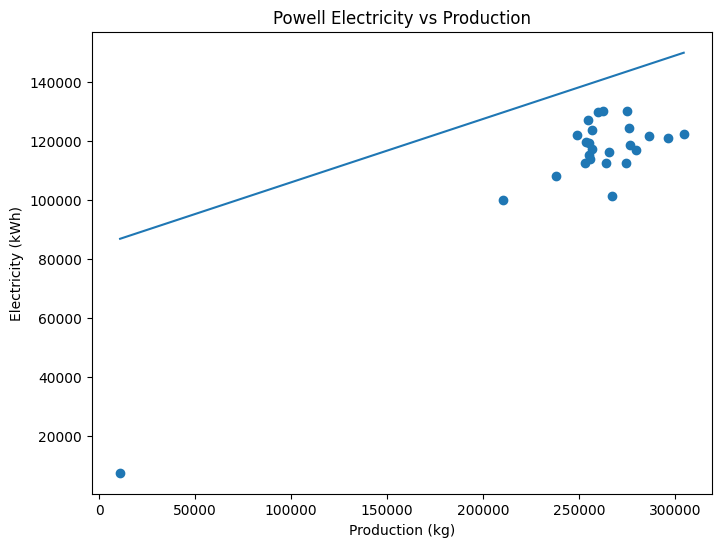

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Scatter Plot
# =========================

plt.figure(figsize=(8,6))

# scatter points
plt.scatter(
    model_df["production_kg"],
    model_df["kwh"],
)

# regression line (Model A)
x_vals = np.linspace(
    model_df["production_kg"].min(),
    model_df["production_kg"].max(),
    100
)

y_vals = (
    -1273
    + 2946 * model_df["days"].mean()
    + 0.215 * x_vals
)

plt.plot(x_vals, y_vals)

plt.xlabel("Production (kg)")
plt.ylabel("Electricity (kWh)")
plt.title("Powell Electricity vs Production")

plt.show()

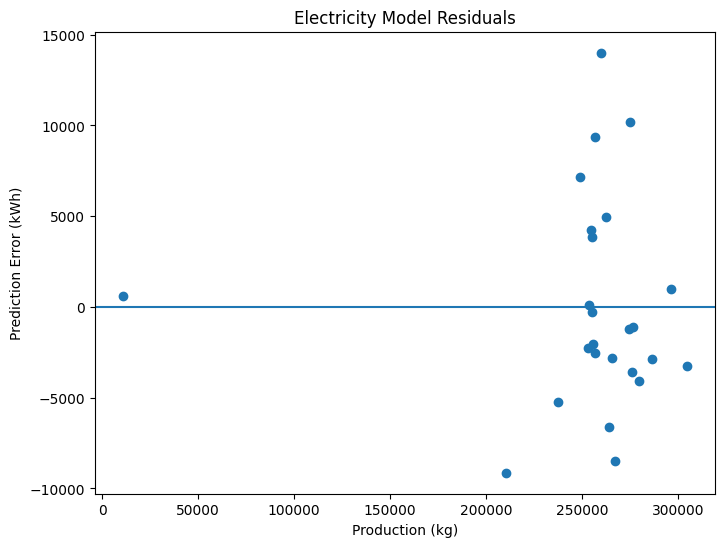

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    outA["production_kg"],
    outA["resid"],
)

plt.axhline(0)

plt.xlabel("Production (kg)")
plt.ylabel("Prediction Error (kWh)")
plt.title("Electricity Model Residuals")

plt.show()

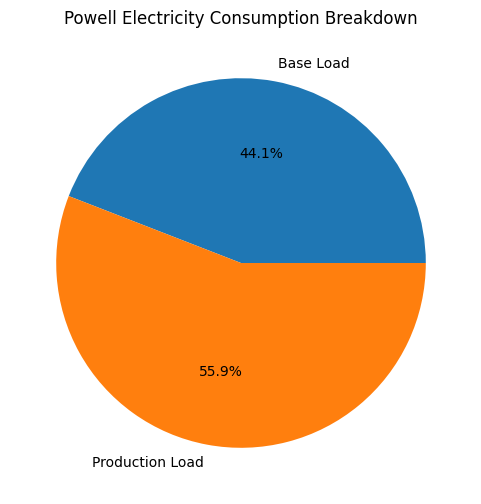

In [ ]:
base_load = 2946 * 365

production_load = model_df["production_kg"].sum() * 0.215

labels = ["Base Load", "Production Load"]
values = [base_load, production_load]

plt.figure(figsize=(6,6))

plt.pie(values, labels=labels, autopct="%1.1f%%")

plt.title("Powell Electricity Consumption Breakdown")

plt.show()

In [ ]:
import pandas as pd
import numpy as np

OP_2024 = "/content/Operation 2024.xlsx"
OP_2025 = "/content/Operation 2025.xlsx"

PRIMARY_LINES   = {"110", "111", "112", "113"}
SECONDARY_LINES = {"115", "116", "117", "118"}

def _normalize_cols(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def get_capacity_sheet_name(op_path):
    xl = pd.ExcelFile(op_path)
    sheets = xl.sheet_names
    if "Capacity Ledger Entries" in sheets:
        return "Capacity Ledger Entries"
    if "Capapcity Ledger Entries" in sheets:  # your OP_2024 typo
        return "Capapcity Ledger Entries"
    raise ValueError(f"Capacity ledger sheet not found in {op_path}. Sheets: {sheets}")

def pick_first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def load_capacity(op_path):
    sheet = get_capacity_sheet_name(op_path)
    df = pd.read_excel(op_path, sheet_name=sheet)
    df = _normalize_cols(df)

    # Candidate columns (adjusts automatically if your file uses slightly different headers)
    posting_col = pick_first_col(df, ["Posting Date", "Date"])
    line_col    = pick_first_col(df, ["No.", "No", "Line Code", "Work Center No.", "Machine No."])
    run_col     = pick_first_col(df, ["Run Time", "Run Time (Min.)", "RunTime"])
    setup_col   = pick_first_col(df, ["Setup Time", "Setup Time (Min.)", "SetupTime"])

    item_col    = pick_first_col(df, ["Item No.", "Item No", "Item"])
    order_col   = pick_first_col(df, ["Order No.", "Prod. Order No.", "Production Order No.", "Document No.", "Source No."])

    required = [posting_col, line_col, run_col, setup_col]
    if any(c is None for c in required):
        raise ValueError(
            f"[{op_path}::{sheet}] Missing one of required cols.\n"
            f"Found posting={posting_col}, line={line_col}, run={run_col}, setup={setup_col}\n"
            f"Available: {list(df.columns)}"
        )

    df["Posting Date"] = pd.to_datetime(df[posting_col], errors="coerce")
    df = df.dropna(subset=["Posting Date"])

    df["line_code"] = df[line_col].astype(str).str.strip()

    df["runtime"] = (
        pd.to_numeric(df[run_col], errors="coerce").fillna(0) +
        pd.to_numeric(df[setup_col], errors="coerce").fillna(0)
    )

    # Keep identifiers (item/order) if available
    if item_col:
        df["Item No."] = df[item_col].astype(str).str.strip()
    else:
        df["Item No."] = np.nan

    if order_col:
        df["Order/Doc No."] = df[order_col].astype(str).str.strip()
    else:
        df["Order/Doc No."] = np.nan

    return df[["Posting Date", "line_code", "runtime", "Item No.", "Order/Doc No."]]

# -------------------------
# 1) Load capacity ledgers
# -------------------------
cap24 = load_capacity(OP_2024)
cap25 = load_capacity(OP_2025)
cap = pd.concat([cap24, cap25], ignore_index=True)

# -------------------------
# 2) Filter to secondary lines
# -------------------------
sec = cap[cap["line_code"].isin(SECONDARY_LINES)].copy()

print(f"Secondary rows: {len(sec):,}")
print("Columns available for mapping:", sec.columns.tolist())

# -------------------------
# 3) If Item No. exists -> list products directly
# -------------------------
if sec["Item No."].notna().any():
    # remove blanks like "nan" or "" if any
    sec = sec[sec["Item No."].notna() & (sec["Item No."].astype(str).str.strip() != "")]

    products = (
        sec.groupby("Item No.", as_index=False)
           .agg(
               secondary_runtime=("runtime", "sum"),
               secondary_records=("runtime", "size"),
               first_date=("Posting Date", "min"),
               last_date=("Posting Date", "max")
           )
           .sort_values("secondary_runtime", ascending=False)
           .reset_index(drop=True)
    )

    print("\n✅ Products that required SECONDARY runtime (115–118):")
    display(products.head(50))  # show top 50 by runtime

else:
    # -------------------------
    # 4) Fallback: no Item No. in sheet
    #    List orders/docs that hit secondary lines
    # -------------------------
    sec = sec[sec["Order/Doc No."].notna() & (sec["Order/Doc No."].astype(str).str.strip() != "")]
    orders = (
        sec.groupby("Order/Doc No.", as_index=False)
           .agg(
               secondary_runtime=("runtime", "sum"),
               secondary_records=("runtime", "size"),
               first_date=("Posting Date", "min"),
               last_date=("Posting Date", "max")
           )
           .sort_values("secondary_runtime", ascending=False)
           .reset_index(drop=True)
    )

    print("\n⚠️ Capacity Ledger Entries does NOT contain Item No. in this file layout.")
    print("Here are the orders/docs that required SECONDARY runtime (115–118):")
    display(orders.head(50))

# -------------------------
# 5) Optional: export results
# -------------------------
# products.to_excel("/content/secondary_products.xlsx", index=False)
# orders.to_excel("/content/secondary_orders.xlsx", index=False)

Secondary rows: 2,386
Columns available for mapping: ['Posting Date', 'line_code', 'runtime', 'Item No.', 'Order/Doc No.']

✅ Products that required SECONDARY runtime (115–118):


,Item No.,secondary_runtime,secondary_records,first_date,last_date
0,W11058,472847,807,2024-01-03,2025-12-30
1,W11021,238696,433,2024-01-03,2025-12-30
2,W11019,109988,343,2024-01-04,2025-12-27
3,W11076,106158,362,2024-01-08,2025-12-29
4,W11203,56921,235,2024-01-03,2025-12-29
5,W11063,28334,134,2024-01-03,2025-12-24
6,W11210,22407,72,2024-03-04,2025-12-19


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# -------------------------
# 0) Helpers
# -------------------------
def add_predictions_and_errors(df, model, X_cols):
    X = sm.add_constant(df[X_cols].copy())
    out = df.copy()
    out["kwh_pred"] = model.predict(X)
    out["error_kwh"] = out["kwh"] - out["kwh_pred"]
    out["abs_error_kwh"] = out["error_kwh"].abs()
    out["ape"] = np.where(out["kwh"] != 0, out["abs_error_kwh"] / out["kwh"], np.nan)  # absolute % error
    out["kwh_per_day_actual"] = out["kwh"] / out["days"]
    out["kwh_per_day_pred"] = out["kwh_pred"] / out["days"]
    return out

def metrics(out):
    mae = out["abs_error_kwh"].mean()
    rmse = np.sqrt(np.mean(out["error_kwh"]**2))
    mape = out["ape"].mean() * 100
    wape = out["abs_error_kwh"].sum() / out["kwh"].sum() * 100  # weighted MAPE
    return {"MAE_kWh": mae, "RMSE_kWh": rmse, "MAPE_%": mape, "WAPE_%": wape}

# -------------------------
# 1) Ensure your model_df has year column
# -------------------------
bt = model_df.copy()
bt["year"] = bt["start"].dt.year

# -------------------------
# 2) (OPTIONAL) Add NonProductionDays
# If you already built it earlier, skip this section.
# If not, set it to 0 so the code still runs.
# -------------------------
if "non_production_days" not in bt.columns:
    bt["non_production_days"] = 0.0

# -------------------------
# 3) Choose model structure to backtest
# A) Base + Production
# B) Base + Production + IdlePenalty (recommended if you have non_production_days)
# -------------------------

# --- Model A: kwh = days + production_kg
X_cols_A = ["days", "production_kg"]

XA = sm.add_constant(bt[X_cols_A])
y = bt["kwh"]
model_A = sm.OLS(y, XA).fit()

out_A = add_predictions_and_errors(bt, model_A, X_cols_A)
m_A = metrics(out_A)

print("\n========================")
print("BACKTEST MODEL A: kwh ~ days + production_kg")
print(model_A.summary())
print("Metrics:", m_A)

# --- Model B: kwh = days + production_kg + non_production_days
# Only meaningful if non_production_days is not always 0
X_cols_B = ["days", "production_kg", "non_production_days"]

XB = sm.add_constant(bt[X_cols_B])
model_B = sm.OLS(y, XB).fit()

out_B = add_predictions_and_errors(bt, model_B, X_cols_B)
m_B = metrics(out_B)

print("\n========================")
print("BACKTEST MODEL B: kwh ~ days + production_kg + non_production_days")
print(model_B.summary())
print("Metrics:", m_B)

# -------------------------
# 4) Year-by-year metrics (2024 vs 2025)
# -------------------------
def year_metrics(out):
    res = []
    for yr, g in out.groupby("year"):
        res.append({"year": int(yr), **metrics(g)})
    return pd.DataFrame(res).sort_values("year")

print("\n=== Year metrics: Model A ===")
display(year_metrics(out_A))

print("\n=== Year metrics: Model B ===")
display(year_metrics(out_B))

# -------------------------
# 5) Output clean variance tables
# -------------------------
def variance_table(out):
    t = out.copy()
    t["variance_%"] = np.where(t["kwh"] != 0, (t["kwh_pred"] - t["kwh"]) / t["kwh"], np.nan) * 100
    cols = [
        "start","end","year","days",
        "production_kg","non_production_days",
        "kwh","kwh_pred","error_kwh","variance_%","ape"
    ]
    return t[cols].sort_values(["start"])

var_A = variance_table(out_A)
var_B = variance_table(out_B)

print("\n=== Variance table (Model A) ===")
display(var_A)

print("\n=== Variance table (Model B) ===")
display(var_B)

# -------------------------
# 6) Show worst periods (largest absolute error)
# -------------------------
print("\n=== Worst 5 periods: Model A ===")
display(var_A.assign(abs_error=lambda d: d["error_kwh"].abs()).sort_values("abs_error", ascending=False).head(5))

print("\n=== Worst 5 periods: Model B ===")
display(var_B.assign(abs_error=lambda d: d["error_kwh"].abs()).sort_values("abs_error", ascending=False).head(5))

# -------------------------
# 7) Export (optional)
# -------------------------
# var_A.to_excel("/content/powell_backtest_modelA.xlsx", index=False)
# var_B.to_excel("/content/powell_backtest_modelB.xlsx", index=False)
# print("Saved backtest files to /content/")


BACKTEST MODEL A: kwh ~ days + production_kg
                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     146.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.93e-13
Time:                        15:52:13   Log-Likelihood:                -253.31
No. Observations:                  25   AIC:                             512.6
Df Residuals:                      22   BIC:                             516.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


,year,MAE_kWh,RMSE_kWh,MAPE_%,WAPE_%
0,2024,3788.752239,4651.671687,3.531365,3.484280
1,2025,6167.595668,7327.460193,5.156159,5.172422



=== Year metrics: Model B ===


,year,MAE_kWh,RMSE_kWh,MAPE_%,WAPE_%
0,2024,3788.752239,4651.671687,3.531365,3.484280
1,2025,6167.595668,7327.460193,5.156159,5.172422


...

,start,end,year,days,production_kg,non_production_days,kwh,kwh_pred,error_kwh,variance_%,ape
0,2024-01-03,2024-01-31,2024,29.0,296447.97,0.0,120960.0,119550.995111,1409.004889,-1.164852,0.011649
1,2024-02-01,2024-03-01,2024,30.0,265450.38,0.0,116160.0,117791.139710,-1631.139710,1.404218,0.014042
2,2024-03-02,2024-03-31,2024,30.0,237767.23,0.0,108000.0,113860.693333,-5860.693333,5.426568,0.054266
3,2024-04-01,2024-04-02,2024,2.0,10840.55,0.0,7440.0,7688.822473,-248.822473,3.344388,0.033444
4,2024-04-03,2024-05-01,2024,29.0,210483.76,0.0,99840.0,107345.819120,-7505.819120,7.517848,0.075178
5,2024-05-02,2024-05-31,2024,30.0,276501.35,0.0,118800.0,119360.153532,-560.153532,0.471510,0.004715
6,2024-06-01,2024-07-02,2024,32.0,254643.53,0.0,127200.0,121539.134578,5660.865422,-4.450366,0.044504
7,2024-07-03,2024-07-30,2024,28.0,255409.50,0.0,119280.0,111083.189605,8196.810395,-6.871907,0.068719
8,2024-07-31,2024-08-29,2024,30.0,253762.96,0.0,119760.0,116131.762884,3628.237116,-3.029590,0.030296
9,2024-08-30,2024-09-27,2024,29.0,279904.10,0.0,116880.0,117202.100787,-322.100787,0.275582,0.002756



=== Worst 5 periods: Model A ===


,start,end,year,days,production_kg,non_production_days,kwh,kwh_pred,error_kwh,variance_%,ape,abs_error
20,2025-07-30,2025-08-28,2025,30.0,259887.23,0.0,129840.0,117001.285132,12838.714868,-9.888104,0.098881,12838.714868
15,2025-03-04,2025-03-31,2025,28.0,267259.70,0.0,101520.0,112765.677893,-11245.677893,11.077303,0.110773,11245.677893
23,2025-10-30,2025-11-28,2025,30.0,274926.42,0.0,130080.0,119136.545384,10943.454616,-8.412865,0.084129,10943.454616
19,2025-07-01,2025-07-29,2025,29.0,256770.39,0.0,123840.0,113917.582708,9922.417292,-8.012288,0.080123,9922.417292
7,2024-07-03,2024-07-30,2024,28.0,255409.50,0.0,119280.0,111083.189605,8196.810395,-6.871907,0.068719,8196.810395



=== Worst 5 periods: Model B ===


,start,end,year,days,production_kg,non_production_days,kwh,kwh_pred,error_kwh,variance_%,ape,abs_error
20,2025-07-30,2025-08-28,2025,30.0,259887.23,0.0,129840.0,117001.285132,12838.714868,-9.888104,0.098881,12838.714868
15,2025-03-04,2025-03-31,2025,28.0,267259.70,0.0,101520.0,112765.677893,-11245.677893,11.077303,0.110773,11245.677893
23,2025-10-30,2025-11-28,2025,30.0,274926.42,0.0,130080.0,119136.545384,10943.454616,-8.412865,0.084129,10943.454616
19,2025-07-01,2025-07-29,2025,29.0,256770.39,0.0,123840.0,113917.582708,9922.417292,-8.012288,0.080123,9922.417292
7,2024-07-03,2024-07-30,2024,28.0,255409.50,0.0,119280.0,111083.189605,8196.810395,-6.871907,0.068719,8196.810395


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# -------------------------
# 0) Helpers
# -------------------------
def add_predictions_and_errors(df, model, X_cols):
    X = sm.add_constant(df[X_cols].copy())
    out = df.copy()
    out["kwh_pred"] = model.predict(X)
    out["error_kwh"] = out["kwh"] - out["kwh_pred"]
    out["abs_error_kwh"] = out["error_kwh"].abs()
    out["ape"] = np.where(out["kwh"] != 0, out["abs_error_kwh"] / out["kwh"], np.nan)  # absolute % error
    out["kwh_per_day_actual"] = out["kwh"] / out["days"]
    out["kwh_per_day_pred"] = out["kwh_pred"] / out["days"]
    return out

def metrics(out):
    mae = out["abs_error_kwh"].mean()
    rmse = np.sqrt(np.mean(out["error_kwh"]**2))
    mape = out["ape"].mean() * 100
    wape = out["abs_error_kwh"].sum() / out["kwh"].sum() * 100  # weighted MAPE
    return {"MAE_kWh": mae, "RMSE_kWh": rmse, "MAPE_%": mape, "WAPE_%": wape}

# -------------------------
# 1) Ensure your model_df has year column
# -------------------------
bt = model_df.copy()
bt["year"] = bt["start"].dt.year

# -------------------------
# 2) (OPTIONAL) Add NonProductionDays
# If you already built it earlier, skip this section.
# If not, set it to 0 so the code still runs.
# -------------------------
if "non_production_days" not in bt.columns:
    bt["non_production_days"] = 0.0

# -------------------------
# 3) Choose model structure to backtest
# A) Base + Production
# B) Base + Production + IdlePenalty (recommended if you have non_production_days)
# -------------------------

# --- Model A: kwh = days + production_kg
X_cols_A = ["days", "production_kg"]

XA = sm.add_constant(bt[X_cols_A])
y = bt["kwh"]
model_A = sm.OLS(y, XA).fit()

out_A = add_predictions_and_errors(bt, model_A, X_cols_A)
m_A = metrics(out_A)

print("\n========================")
print("BACKTEST MODEL A: kwh ~ days + production_kg")
print(model_A.summary())
print("Metrics:", m_A)

# --- Model B: kwh = days + production_kg + non_production_days
# Only meaningful if non_production_days is not always 0
X_cols_B = ["days", "production_kg", "non_production_days"]

XB = sm.add_constant(bt[X_cols_B])
model_B = sm.OLS(y, XB).fit()

out_B = add_predictions_and_errors(bt, model_B, X_cols_B)
m_B = metrics(out_B)

print("\n========================")
print("BACKTEST MODEL B: kwh ~ days + production_kg + non_production_days")
print(model_B.summary())
print("Metrics:", m_B)

# -------------------------
# 4) Year-by-year metrics (2024 vs 2025)
# -------------------------
def year_metrics(out):
    res = []
    for yr, g in out.groupby("year"):
        res.append({"year": int(yr), **metrics(g)})
    return pd.DataFrame(res).sort_values("year")

print("\n=== Year metrics: Model A ===")
display(year_metrics(out_A))

print("\n=== Year metrics: Model B ===")
display(year_metrics(out_B))

# -------------------------
# 5) Output clean variance tables
# -------------------------
def variance_table(out):
    t = out.copy()
    t["variance_%"] = np.where(t["kwh"] != 0, (t["kwh_pred"] - t["kwh"]) / t["kwh"], np.nan) * 100
    cols = [
        "start","end","year","days",
        "production_kg","non_production_days",
        "kwh","kwh_pred","error_kwh","variance_%","ape"
    ]
    return t[cols].sort_values(["start"])

var_A = variance_table(out_A)
var_B = variance_table(out_B)

print("\n=== Variance table (Model A) ===")
display(var_A)

print("\n=== Variance table (Model B) ===")
display(var_B)

# -------------------------
# 6) Show worst periods (largest absolute error)
# -------------------------
print("\n=== Worst 5 periods: Model A ===")
display(var_A.assign(abs_error=lambda d: d["error_kwh"].abs()).sort_values("abs_error", ascending=False).head(5))

print("\n=== Worst 5 periods: Model B ===")
display(var_B.assign(abs_error=lambda d: d["error_kwh"].abs()).sort_values("abs_error", ascending=False).head(5))

# -------------------------
# 7) Export (optional)
# -------------------------
# var_A.to_excel("/content/powell_backtest_modelA.xlsx", index=False)
# var_B.to_excel("/content/powell_backtest_modelB.xlsx", index=False)
# print("Saved backtest files to /content/")


BACKTEST MODEL A: kwh ~ days + production_kg
                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     146.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.93e-13
Time:                        15:52:13   Log-Likelihood:                -253.31
No. Observations:                  25   AIC:                             512.6
Df Residuals:                      22   BIC:                             516.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


,year,MAE_kWh,RMSE_kWh,MAPE_%,WAPE_%
0,2024,3788.752239,4651.671687,3.531365,3.484280
1,2025,6167.595668,7327.460193,5.156159,5.172422



=== Year metrics: Model B ===


,year,MAE_kWh,RMSE_kWh,MAPE_%,WAPE_%
0,2024,3788.752239,4651.671687,3.531365,3.484280
1,2025,6167.595668,7327.460193,5.156159,5.172422


...

,start,end,year,days,production_kg,non_production_days,kwh,kwh_pred,error_kwh,variance_%,ape
0,2024-01-03,2024-01-31,2024,29.0,296447.97,0.0,120960.0,119550.995111,1409.004889,-1.164852,0.011649
1,2024-02-01,2024-03-01,2024,30.0,265450.38,0.0,116160.0,117791.139710,-1631.139710,1.404218,0.014042
2,2024-03-02,2024-03-31,2024,30.0,237767.23,0.0,108000.0,113860.693333,-5860.693333,5.426568,0.054266
3,2024-04-01,2024-04-02,2024,2.0,10840.55,0.0,7440.0,7688.822473,-248.822473,3.344388,0.033444
4,2024-04-03,2024-05-01,2024,29.0,210483.76,0.0,99840.0,107345.819120,-7505.819120,7.517848,0.075178
5,2024-05-02,2024-05-31,2024,30.0,276501.35,0.0,118800.0,119360.153532,-560.153532,0.471510,0.004715
6,2024-06-01,2024-07-02,2024,32.0,254643.53,0.0,127200.0,121539.134578,5660.865422,-4.450366,0.044504
7,2024-07-03,2024-07-30,2024,28.0,255409.50,0.0,119280.0,111083.189605,8196.810395,-6.871907,0.068719
8,2024-07-31,2024-08-29,2024,30.0,253762.96,0.0,119760.0,116131.762884,3628.237116,-3.029590,0.030296
9,2024-08-30,2024-09-27,2024,29.0,279904.10,0.0,116880.0,117202.100787,-322.100787,0.275582,0.002756



=== Worst 5 periods: Model A ===


,start,end,year,days,production_kg,non_production_days,kwh,kwh_pred,error_kwh,variance_%,ape,abs_error
20,2025-07-30,2025-08-28,2025,30.0,259887.23,0.0,129840.0,117001.285132,12838.714868,-9.888104,0.098881,12838.714868
15,2025-03-04,2025-03-31,2025,28.0,267259.70,0.0,101520.0,112765.677893,-11245.677893,11.077303,0.110773,11245.677893
23,2025-10-30,2025-11-28,2025,30.0,274926.42,0.0,130080.0,119136.545384,10943.454616,-8.412865,0.084129,10943.454616
19,2025-07-01,2025-07-29,2025,29.0,256770.39,0.0,123840.0,113917.582708,9922.417292,-8.012288,0.080123,9922.417292
7,2024-07-03,2024-07-30,2024,28.0,255409.50,0.0,119280.0,111083.189605,8196.810395,-6.871907,0.068719,8196.810395



=== Worst 5 periods: Model B ===


,start,end,year,days,production_kg,non_production_days,kwh,kwh_pred,error_kwh,variance_%,ape,abs_error
20,2025-07-30,2025-08-28,2025,30.0,259887.23,0.0,129840.0,117001.285132,12838.714868,-9.888104,0.098881,12838.714868
15,2025-03-04,2025-03-31,2025,28.0,267259.70,0.0,101520.0,112765.677893,-11245.677893,11.077303,0.110773,11245.677893
23,2025-10-30,2025-11-28,2025,30.0,274926.42,0.0,130080.0,119136.545384,10943.454616,-8.412865,0.084129,10943.454616
19,2025-07-01,2025-07-29,2025,29.0,256770.39,0.0,123840.0,113917.582708,9922.417292,-8.012288,0.080123,9922.417292
7,2024-07-03,2024-07-30,2024,28.0,255409.50,0.0,119280.0,111083.189605,8196.810395,-6.871907,0.068719,8196.810395


In [ ]:
import numpy as np
import pandas as pd

# =========================
# Model coefficients from regression
# =========================

INTERCEPT = -1273.1402
BASE_PER_DAY = 2946.6992
PROD_PER_KG = 0.215151

# =========================
# Predict electricity bill
# =========================

bt = model_df.copy()

bt["kwh_pred"] = (
    INTERCEPT
    + BASE_PER_DAY * bt["days"]
    + PROD_PER_KG * bt["production_kg"]
)

# =========================
# Calculate errors
# =========================

bt["error_kwh"] = bt["kwh"] - bt["kwh_pred"]
bt["abs_error_kwh"] = abs(bt["error_kwh"])

bt["error_%"] = bt["error_kwh"] / bt["kwh"] * 100
bt["abs_error_%"] = abs(bt["error_%"])

# =========================
# Model accuracy metrics
# =========================

MAE = bt["abs_error_kwh"].mean()
RMSE = np.sqrt((bt["error_kwh"]**2).mean())
MAPE = bt["abs_error_%"].mean()

print("Backtest Accuracy")
print("----------------------------")
print(f"MAE   : {MAE:,.0f} kWh")
print(f"RMSE  : {RMSE:,.0f} kWh")
print(f"MAPE  : {MAPE:.2f}%")

# =========================
# Show bill comparison
# =========================

result = bt[[
    "start",
    "end",
    "days",
    "production_kg",
    "kwh",
    "kwh_pred",
    "error_kwh",
    "error_%"
]].copy()

print("\nBacktest Table")
print(result)

# =========================
# Identify worst bills
# =========================

print("\nWorst prediction periods")
print(
    result.assign(abs_error=lambda x: abs(x["error_kwh"]))
    .sort_values("abs_error", ascending=False)
    .head(5)
)

# =========================
# Overall electricity totals
# =========================

actual_total = bt["kwh"].sum()
pred_total = bt["kwh_pred"].sum()

print("\nTotal Electricity Comparison")
print("----------------------------")
print(f"Actual kWh   : {actual_total:,.0f}")
print(f"Predicted kWh: {pred_total:,.0f}")
print(f"Difference   : {actual_total - pred_total:,.0f} kWh")

Backtest Accuracy
----------------------------
MAE   : 25,349 kWh
RMSE  : 26,611 kWh
MAPE  : 22.01%

Backtest Table
        start        end  days  production_kg       kwh       kwh_pred  \
0  2024-01-03 2024-01-31  29.0      296447.97  120960.0  147962.213793   
1  2024-02-01 2024-03-01  30.0      265450.38  116160.0  144239.750507   
2  2024-03-02 2024-03-31  30.0      237767.23  108000.0  138283.693102   
3  2024-04-01 2024-04-02   2.0       10840.55    7440.0    6952.613373   
4  2024-04-03 2024-05-01  29.0      210483.76   99840.0  129466.928048   
5  2024-05-02 2024-05-31  30.0      276501.35  118800.0  146617.377754   
6  2024-06-01 2024-07-02  32.0      254643.53  127200.0  147808.044323   
7  2024-07-03 2024-07-30  28.0      255409.50  119280.0  136186.046735   
8  2024-07-31 2024-08-29  30.0      253762.96  119760.0  141725.190407   
9  2024-08-30 2024-09-27  29.0      279904.10  116880.0  144402.783619   
10 2024-09-28 2024-10-30  33.0      276286.51  124320.0  155411.252313

In [ ]:
import statsmodels.api as sm
import numpy as np

bt = model_df.copy()

X_cols = ["days", "production_kg"]
X = sm.add_constant(bt[X_cols])
y = bt["kwh"]

m = sm.OLS(y, X).fit()
print(m.summary())

bt["kwh_pred"] = m.predict(X)
bt["error_kwh"] = bt["kwh"] - bt["kwh_pred"]
bt["abs_error_kwh"] = bt["error_kwh"].abs()
bt["ape"] = np.where(bt["kwh"] != 0, bt["abs_error_kwh"] / bt["kwh"], np.nan)

MAE = bt["abs_error_kwh"].mean()
RMSE = np.sqrt(np.mean(bt["error_kwh"]**2))
WAPE = bt["abs_error_kwh"].sum() / bt["kwh"].sum() * 100

print(f"MAE:  {MAE:,.0f} kWh")
print(f"RMSE: {RMSE:,.0f} kWh")
print(f"WAPE: {WAPE:.2f}%")

display(bt[["start","end","days","production_kg","kwh","kwh_pred","error_kwh","ape"]])

                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     146.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.93e-13
Time:                        15:52:13   Log-Likelihood:                -253.31
No. Observations:                  25   AIC:                             512.6
Df Residuals:                      22   BIC:                             516.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           867.3354   6754.017      0.128

,start,end,days,production_kg,kwh,kwh_pred,error_kwh,ape
0,2024-01-03,2024-01-31,29.0,296447.97,120960.0,119550.995111,1409.004889,0.011649
1,2024-02-01,2024-03-01,30.0,265450.38,116160.0,117791.139710,-1631.139710,0.014042
2,2024-03-02,2024-03-31,30.0,237767.23,108000.0,113860.693333,-5860.693333,0.054266
3,2024-04-01,2024-04-02,2.0,10840.55,7440.0,7688.822473,-248.822473,0.033444
4,2024-04-03,2024-05-01,29.0,210483.76,99840.0,107345.819120,-7505.819120,0.075178
5,2024-05-02,2024-05-31,30.0,276501.35,118800.0,119360.153532,-560.153532,0.004715
6,2024-06-01,2024-07-02,32.0,254643.53,127200.0,121539.134578,5660.865422,0.044504
7,2024-07-03,2024-07-30,28.0,255409.50,119280.0,111083.189605,8196.810395,0.068719
8,2024-07-31,2024-08-29,30.0,253762.96,119760.0,116131.762884,3628.237116,0.030296
9,2024-08-30,2024-09-27,29.0,279904.10,116880.0,117202.100787,-322.100787,0.002756


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ============================================
# CONFIG
# ============================================
POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"

# ============================================
# HELPERS
# ============================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried: {candidates}\nAvailable: {list(df.columns)}")

def find_next_matching_col(columns, start_idx, keywords):
    """
    From a starting column index, find the next column whose name contains all keywords.
    """
    cols = list(columns)
    for i in range(start_idx + 1, len(cols)):
        c = cols[i].lower()
        if all(k.lower() in c for k in keywords):
            return cols[i]
    return None

def find_energy_subtotal_col(df, energy_used_col):
    """
    Find the Subtotal column corresponding to the Energy Used section by looking to the right
    of Energy Used and finding the next 'Subtotal' column.
    """
    cols = list(df.columns)
    idx = cols.index(energy_used_col)

    # first try next column containing 'subtotal'
    for i in range(idx + 1, len(cols)):
        c = cols[i].lower()
        if "subtotal" in c:
            return cols[i]

    raise ValueError(f"Could not find energy subtotal column after '{energy_used_col}'")

# ============================================
# 1) FIT THE MODEL ON 2024-2025
# ============================================
bt = model_df.copy()

X_cols = ["days", "production_kg"]
X = sm.add_constant(bt[X_cols])
y = bt["kwh"]

model = sm.OLS(y, X).fit()

print(model.summary())

bt["kwh_pred"] = model.predict(X)
bt["error_kwh"] = bt["kwh"] - bt["kwh_pred"]
bt["abs_error_kwh"] = bt["error_kwh"].abs()

print(f"\nMAE kWh : {bt['abs_error_kwh'].mean():,.0f}")
print(f"RMSE kWh: {np.sqrt((bt['error_kwh']**2).mean()):,.0f}")
print(f"WAPE kWh: {bt['abs_error_kwh'].sum()/bt['kwh'].sum()*100:.2f}%")

# ============================================
# 2) LOAD ELECTRICITY BILL SHEET
# ============================================
elec = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
elec = normalize_cols(elec)
elec.columns = make_unique_columns(elec.columns)

# Identify key columns
start_col = pick_first_col(elec, ["Start Date"], "Start Date")
end_col   = pick_first_col(elec, ["End Date"], "End Date")
days_col  = pick_first_col(elec, ["Days"], "Days")
kwh_col   = pick_first_col(elec, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
total_col = pick_first_col(
    elec,
    ["Total Due", "Total Due $", "Total Due $.1", "Total Due  ", "Total Due Amount"],
    "Total Due"
)

# GST column optional
gst_candidates = [c for c in elec.columns if "gst" in c.lower()]
gst_col = gst_candidates[0] if len(gst_candidates) > 0 else None

# Energy subtotal column (the one tied to kWh)
energy_subtotal_col = find_energy_subtotal_col(elec, kwh_col)

# Parse types
elec[start_col] = pd.to_datetime(elec[start_col], errors="coerce")
elec[end_col]   = pd.to_datetime(elec[end_col], errors="coerce")
elec[days_col]  = pd.to_numeric(elec[days_col], errors="coerce")
elec[kwh_col]   = pd.to_numeric(elec[kwh_col], errors="coerce")
elec[energy_subtotal_col] = pd.to_numeric(elec[energy_subtotal_col], errors="coerce")
elec[total_col] = pd.to_numeric(elec[total_col], errors="coerce")

if gst_col:
    elec[gst_col] = pd.to_numeric(elec[gst_col], errors="coerce").fillna(0)

# Keep only usable rows
bill = elec.dropna(subset=[start_col, end_col, kwh_col, energy_subtotal_col, total_col]).copy()

print("\nDetected columns:")
print(" start_col           =", start_col)
print(" end_col             =", end_col)
print(" days_col            =", days_col)
print(" kwh_col             =", kwh_col)
print(" energy_subtotal_col =", energy_subtotal_col)
print(" total_col           =", total_col)
print(" gst_col             =", gst_col)

# ============================================
# 3) MERGE MODEL PREDICTION TO ACTUAL BILL
# ============================================
bt = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="left",
    suffixes=("", "_bill")
)

# sanity check
missing_merge = bt[total_col].isna().sum()
print(f"\nMerged bill rows missing actual bill info: {missing_merge}")

# ============================================
# 4) REBUILD BILL USING PREDICTED KWH
#    COPY ALL OTHER CHARGES FROM ACTUAL BILL
# ============================================

# implied actual energy rate from actual bill
bt["energy_rate_actual"] = np.where(
    bt[kwh_col] != 0,
    bt[energy_subtotal_col] / bt[kwh_col],
    np.nan
)

# predicted energy subtotal using model kWh
bt["energy_subtotal_pred"] = bt["kwh_pred"] * bt["energy_rate_actual"]

# strict copy version:
# keep every other charge exactly the same, only replace energy subtotal
bt["pred_total_due_copy"] = (
    bt[total_col]
    - bt[energy_subtotal_col]
    + bt["energy_subtotal_pred"]
)

# optional GST-adjusted version
if gst_col:
    bt["gst_pred"] = bt[gst_col] + 0.05 * (bt["energy_subtotal_pred"] - bt[energy_subtotal_col])

    bt["pred_total_due_gst_adj"] = (
        bt[total_col]
        - bt[energy_subtotal_col]
        - bt[gst_col]
        + bt["energy_subtotal_pred"]
        + bt["gst_pred"]
    )
else:
    bt["gst_pred"] = np.nan
    bt["pred_total_due_gst_adj"] = bt["pred_total_due_copy"]

# ============================================
# 5) COST VARIANCE
# ============================================

# strict copy version
bt["cost_variance_copy_$"] = bt[total_col] - bt["pred_total_due_copy"]
bt["abs_cost_variance_copy_$"] = bt["cost_variance_copy_$"].abs()
bt["cost_variance_copy_%"] = np.where(
    bt[total_col] != 0,
    bt["cost_variance_copy_$"] / bt[total_col] * 100,
    np.nan
)

# GST adjusted version
bt["cost_variance_gst_adj_$"] = bt[total_col] - bt["pred_total_due_gst_adj"]
bt["abs_cost_variance_gst_adj_$"] = bt["cost_variance_gst_adj_$"].abs()
bt["cost_variance_gst_adj_%"] = np.where(
    bt[total_col] != 0,
    bt["cost_variance_gst_adj_$"] / bt[total_col] * 100,
    np.nan
)

# metrics
print("\n========================")
print("COST BACKTEST METRICS - STRICT COPY")
print("========================")
print(f"MAE $  : {bt['abs_cost_variance_copy_$'].mean():,.2f}")
print(f"RMSE $ : {np.sqrt((bt['cost_variance_copy_$']**2).mean()):,.2f}")
print(f"WAPE % : {bt['abs_cost_variance_copy_$'].sum()/bt[total_col].sum()*100:.2f}%")

print("\n========================")
print("COST BACKTEST METRICS - GST ADJUSTED")
print("========================")
print(f"MAE $  : {bt['abs_cost_variance_gst_adj_$'].mean():,.2f}")
print(f"RMSE $ : {np.sqrt((bt['cost_variance_gst_adj_$']**2).mean()):,.2f}")
print(f"WAPE % : {bt['abs_cost_variance_gst_adj_$'].sum()/bt[total_col].sum()*100:.2f}%")

# ============================================
# 6) FINAL COST BACKTEST TABLE
# ============================================
cost_backtest = bt[[
    "start",
    "end",
    "days",
    "production_kg",
    kwh_col,
    "kwh_pred",
    energy_subtotal_col,
    "energy_subtotal_pred",
    total_col,
    "pred_total_due_copy",
    "pred_total_due_gst_adj",
    "cost_variance_copy_$",
    "cost_variance_copy_%",
    "cost_variance_gst_adj_$",
    "cost_variance_gst_adj_%"
]].copy()

cost_backtest = cost_backtest.rename(columns={
    kwh_col: "kwh_actual",
    energy_subtotal_col: "energy_subtotal_actual",
    total_col: "actual_total_due"
})

print("\n=== COST BACKTEST TABLE ===")
display(cost_backtest)

# ============================================
# 7) WORST PERIODS BY COST VARIANCE
# ============================================
print("\n=== WORST 5 PERIODS - STRICT COPY ===")
display(
    cost_backtest.assign(abs_var=lambda d: d["cost_variance_copy_$"].abs())
    .sort_values("abs_var", ascending=False)
    .head(5)
)

print("\n=== WORST 5 PERIODS - GST ADJUSTED ===")
display(
    cost_backtest.assign(abs_var=lambda d: d["cost_variance_gst_adj_$"].abs())
    .sort_values("abs_var", ascending=False)
    .head(5)
)

# ============================================
# 8) YEARLY COST VARIANCE
# ============================================
cost_backtest["year"] = cost_backtest["start"].dt.year

year_cost = (
    cost_backtest.groupby("year")
    .apply(lambda g: pd.Series({
        "MAE_copy_$": g["cost_variance_copy_$"].abs().mean(),
        "WAPE_copy_%": g["cost_variance_copy_$"].abs().sum() / g["actual_total_due"].sum() * 100,
        "MAE_gst_adj_$": g["cost_variance_gst_adj_$"].abs().mean(),
        "WAPE_gst_adj_%": g["cost_variance_gst_adj_$"].abs().sum() / g["actual_total_due"].sum() * 100
    }))
    .reset_index()
)

print("\n=== YEARLY COST VARIANCE ===")
display(year_cost)

# ============================================
# 9) OPTIONAL EXPORT
# ============================================
# cost_backtest.to_excel("/content/powell_729_cost_backtest.xlsx", index=False)
# print("Saved: /content/powell_729_cost_backtest.xlsx")

                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     146.5
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.93e-13
Time:                        15:52:14   Log-Likelihood:                -253.31
No. Observations:                  25   AIC:                             512.6
Df Residuals:                      22   BIC:                             516.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           867.3354   6754.017      0.128

,start,end,days,production_kg,kwh_actual,kwh_pred,energy_subtotal_actual,energy_subtotal_pred,actual_total_due,pred_total_due_copy,pred_total_due_gst_adj,cost_variance_copy_$,cost_variance_copy_%,cost_variance_gst_adj_$,cost_variance_gst_adj_%
0,2024-01-03,2024-01-31,29.0,296447.97,120960.0,119550.995111,7426.944,7340.431100,11600.6000,11514.087100,11509.761455,86.512900,0.745762,90.838545,0.783050
1,2024-02-01,2024-03-01,30.0,265450.38,116160.0,117791.139710,7132.224,7232.375978,11112.6100,11212.761978,11217.769577,-100.151978,-0.901246,-105.159577,-0.946309
2,2024-03-02,2024-03-31,30.0,237767.23,108000.0,113860.693333,6631.200,6991.046571,11122.4000,11482.246571,11500.238899,-359.846571,-3.235332,-377.838899,-3.397099
3,2024-04-01,2024-04-02,2.0,10840.55,NaN,7688.822473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-04-03,2024-05-01,29.0,210483.76,99840.0,107345.819120,6519.552,7009.681989,9624.5600,10114.689989,10139.196488,-490.129989,-5.092492,-514.636488,-5.347117
5,2024-05-02,2024-05-31,30.0,276501.35,118800.0,119360.153532,7757.640,7794.218026,11145.1100,11181.688026,11183.516927,-36.578026,-0.328198,-38.406927,-0.344608
6,2024-06-01,2024-07-02,32.0,254643.53,127200.0,121539.134578,8306.160,7936.505488,12410.4900,12040.835488,12022.352762,369.654512,2.978565,388.137238,3.127493
7,2024-07-03,2024-07-30,28.0,255409.50,119280.0,111083.189605,7788.984,7253.732281,11758.9500,11223.698281,11196.935695,535.251719,4.551867,562.014305,4.779460
8,2024-07-31,2024-08-29,30.0,253762.96,119760.0,116131.762884,7820.328,7583.404116,12055.4400,11818.516116,11806.669922,236.923884,1.965286,248.770078,2.063550
9,2024-08-30,2024-09-27,29.0,279904.10,116880.0,117202.100787,7632.264,7653.297181,11366.9200,11387.953181,11389.004840,-21.033181,-0.185039,-22.084840,-0.194290



=== WORST 5 PERIODS - STRICT COPY ===


,start,end,days,production_kg,kwh_actual,kwh_pred,energy_subtotal_actual,energy_subtotal_pred,actual_total_due,pred_total_due_copy,pred_total_due_gst_adj,cost_variance_copy_$,cost_variance_copy_%,cost_variance_gst_adj_$,cost_variance_gst_adj_%,abs_var
20,2025-07-30,2025-08-28,30.0,259887.23,129840.0,117001.285132,8764.200,7897.586746,13809.43,12942.816746,12899.486084,866.613254,6.275518,909.943916,6.589294,866.613254
23,2025-10-30,2025-11-28,30.0,274926.42,130080.0,119136.545384,8780.400,8041.716813,12128.77,11390.086813,11353.152654,738.683187,6.090339,775.617346,6.394856,738.683187
15,2025-03-04,2025-03-31,28.0,267259.70,101520.0,112765.677893,6629.256,7363.598766,9788.92,10523.262766,10559.979905,-734.342766,-7.501775,-771.059905,-7.876864,734.342766
19,2025-07-01,2025-07-29,29.0,256770.39,123840.0,113917.582708,8359.200,7689.436833,12925.71,12255.946833,12222.458674,669.763167,5.181635,703.251326,5.440717,669.763167
7,2024-07-03,2024-07-30,28.0,255409.50,119280.0,111083.189605,7788.984,7253.732281,11758.95,11223.698281,11196.935695,535.251719,4.551867,562.014305,4.779460,535.251719



=== WORST 5 PERIODS - GST ADJUSTED ===


,start,end,days,production_kg,kwh_actual,kwh_pred,energy_subtotal_actual,energy_subtotal_pred,actual_total_due,pred_total_due_copy,pred_total_due_gst_adj,cost_variance_copy_$,cost_variance_copy_%,cost_variance_gst_adj_$,cost_variance_gst_adj_%,abs_var
20,2025-07-30,2025-08-28,30.0,259887.23,129840.0,117001.285132,8764.200,7897.586746,13809.43,12942.816746,12899.486084,866.613254,6.275518,909.943916,6.589294,909.943916
23,2025-10-30,2025-11-28,30.0,274926.42,130080.0,119136.545384,8780.400,8041.716813,12128.77,11390.086813,11353.152654,738.683187,6.090339,775.617346,6.394856,775.617346
15,2025-03-04,2025-03-31,28.0,267259.70,101520.0,112765.677893,6629.256,7363.598766,9788.92,10523.262766,10559.979905,-734.342766,-7.501775,-771.059905,-7.876864,771.059905
19,2025-07-01,2025-07-29,29.0,256770.39,123840.0,113917.582708,8359.200,7689.436833,12925.71,12255.946833,12222.458674,669.763167,5.181635,703.251326,5.440717,703.251326
7,2024-07-03,2024-07-30,28.0,255409.50,119280.0,111083.189605,7788.984,7253.732281,11758.95,11223.698281,11196.935695,535.251719,4.551867,562.014305,4.779460,562.014305



=== YEARLY COST VARIANCE ===


/tmp/ipykernel_212/1330274563.py:282: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,year,MAE_copy_$,WAPE_copy_%,MAE_gst_adj_$,WAPE_gst_adj_%
0,2024,263.775867,2.336553,276.964660,2.453380
1,2025,413.240872,3.427389,433.902915,3.598758


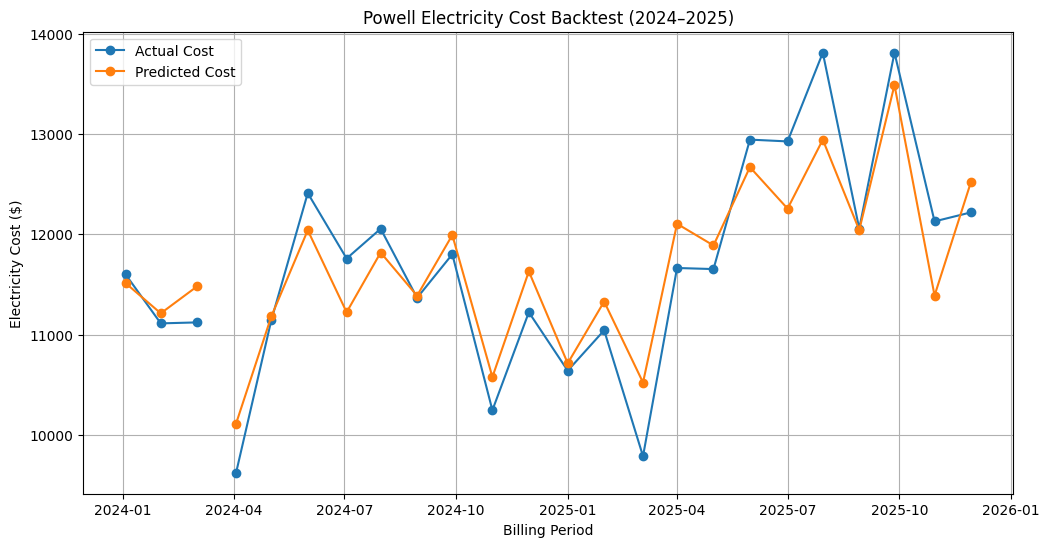

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    cost_backtest["start"],
    cost_backtest["actual_total_due"],
    marker="o",
    label="Actual Cost"
)

plt.plot(
    cost_backtest["start"],
    cost_backtest["pred_total_due_copy"],
    marker="o",
    label="Predicted Cost"
)

plt.title("Powell Electricity Cost Backtest (2024–2025)")
plt.xlabel("Billing Period")
plt.ylabel("Electricity Cost ($)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
variance_pct = cost_backtest[["start", "end", "cost_variance_copy_%"]].copy()
variance_pct["cost_variance_copy_%"] = variance_pct["cost_variance_copy_%"].round(2)
print(variance_pct)

        start        end  cost_variance_copy_%
0  2024-01-03 2024-01-31                  0.75
1  2024-02-01 2024-03-01                 -0.90
2  2024-03-02 2024-03-31                 -3.24
3  2024-04-01 2024-04-02                   NaN
4  2024-04-03 2024-05-01                 -5.09
5  2024-05-02 2024-05-31                 -0.33
6  2024-06-01 2024-07-02                  2.98
7  2024-07-03 2024-07-30                  4.55
8  2024-07-31 2024-08-29                  1.97
9  2024-08-30 2024-09-27                 -0.19
10 2024-09-28 2024-10-30                 -1.62
11 2024-10-31 2024-11-29                 -3.23
12 2024-11-30 2024-12-31                 -3.62
13 2025-01-01 2025-01-30                 -0.69
14 2025-01-31 2025-03-03                 -2.59
15 2025-03-04 2025-03-31                 -7.50
16 2025-04-01 2025-04-30                 -3.78
17 2025-05-01 2025-05-30                 -2.02
18 2025-05-31 2025-06-30                  2.12
19 2025-07-01 2025-07-29                  5.18
20 2025-07-30

In [ ]:
cost_backtest[cost_backtest["actual_total_due"].isna()][["start","end"]]

,start,end
3,2024-04-01,2024-04-02


Rows remaining after removing 2-day bill: 24

=== ELECTRICITY MODEL ===
                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     6.235
Date:                Wed, 11 Mar 2026   Prob (F-statistic):            0.00749
Time:                        15:52:14   Log-Likelihood:                -243.65
No. Observations:                  24   AIC:                             493.3
Df Residuals:                      21   BIC:                             496.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------

,start,end,days,production_kg,kwh_actual,kwh_pred,energy_subtotal_actual,energy_subtotal_pred,actual_total_due,pred_total_due_copy,pred_total_due_gst_adj,cost_variance_copy_$,cost_variance_copy_%,cost_variance_gst_adj_$,cost_variance_gst_adj_%
0,2024-01-03,2024-01-31,29.0,296447.97,120960,119561.654898,7426.944,7341.085611,11600.6000,11514.741611,11510.448691,85.858389,0.740120,90.151309,0.777126
1,2024-02-01,2024-03-01,30.0,265450.38,116160,117826.177365,7132.224,7234.527290,11112.6100,11214.913290,11220.028455,-102.303290,-0.920605,-107.418455,-0.966636
2,2024-03-02,2024-03-31,30.0,237767.23,108000,114038.246590,6631.200,7001.948341,11122.4000,11493.148341,11511.685758,-370.748341,-3.333348,-389.285758,-3.500016
3,2024-04-03,2024-05-01,29.0,210483.76,99840,107799.031187,6519.552,7039.276736,9624.5600,10144.284736,10170.270973,-519.724736,-5.399984,-545.710973,-5.669984
4,2024-05-02,2024-05-31,30.0,276501.35,118800,119338.299698,7757.640,7792.790970,11145.1100,11180.260970,11182.018519,-35.150970,-0.315394,-36.908519,-0.331163
5,2024-06-01,2024-07-02,32.0,254643.53,127200,121359.405369,8306.160,7924.769171,12410.4900,12029.099171,12010.029629,381.390829,3.073133,400.460371,3.226789
6,2024-07-03,2024-07-30,28.0,255409.50,119280,111440.320306,7788.984,7277.052916,11758.9500,11247.018916,11221.422362,511.931084,4.353544,537.527638,4.571221
7,2024-07-31,2024-08-29,30.0,253762.96,119760,116226.968536,7820.328,7589.621045,12055.4400,11824.733045,11813.197698,230.706955,1.913717,242.242302,2.009402
8,2024-08-30,2024-09-27,29.0,279904.10,116880,117297.930058,7632.264,7659.554833,11366.9200,11394.210833,11395.575374,-27.290833,-0.240090,-28.655374,-0.252094
9,2024-09-28,2024-10-30,33.0,276286.51,124320,126826.823284,8118.096,8281.791560,11801.2700,11964.965560,11973.150338,-163.695560,-1.387101,-171.880338,-1.456456



=== WORST 5 PERIODS - STRICT COPY ===


,start,end,days,production_kg,kwh_actual,kwh_pred,energy_subtotal_actual,energy_subtotal_pred,actual_total_due,pred_total_due_copy,pred_total_due_gst_adj,cost_variance_copy_$,cost_variance_copy_%,cost_variance_gst_adj_$,cost_variance_gst_adj_%,abs_var
19,2025-07-30,2025-08-28,30.0,259887.23,129840,117064.962435,8764.200,7901.884964,13809.43,12947.114964,12903.999213,862.315036,6.244393,905.430787,6.556612,862.315036
14,2025-03-04,2025-03-31,28.0,267259.70,101520,113061.802589,6629.256,7382.935709,9788.92,10542.599709,10580.283695,-753.679709,-7.699314,-791.363695,-8.084280,753.679709
22,2025-10-30,2025-11-28,30.0,274926.42,130080,119122.799446,8780.400,8040.788963,12128.77,11389.158963,11352.178411,739.611037,6.097989,776.591589,6.402888,739.611037
18,2025-07-01,2025-07-29,29.0,256770.39,123840,114132.506613,8359.200,7703.944196,12925.71,12270.454196,12237.691406,655.255804,5.069399,688.018594,5.322869,655.255804
3,2024-04-03,2024-05-01,29.0,210483.76,99840,107799.031187,6519.552,7039.276736,9624.56,10144.284736,10170.270973,-519.724736,-5.399984,-545.710973,-5.669984,519.724736



=== WORST 5 PERIODS - GST ADJUSTED ===


,start,end,days,production_kg,kwh_actual,kwh_pred,energy_subtotal_actual,energy_subtotal_pred,actual_total_due,pred_total_due_copy,pred_total_due_gst_adj,cost_variance_copy_$,cost_variance_copy_%,cost_variance_gst_adj_$,cost_variance_gst_adj_%,abs_var
19,2025-07-30,2025-08-28,30.0,259887.23,129840,117064.962435,8764.200,7901.884964,13809.43,12947.114964,12903.999213,862.315036,6.244393,905.430787,6.556612,905.430787
14,2025-03-04,2025-03-31,28.0,267259.70,101520,113061.802589,6629.256,7382.935709,9788.92,10542.599709,10580.283695,-753.679709,-7.699314,-791.363695,-8.084280,791.363695
22,2025-10-30,2025-11-28,30.0,274926.42,130080,119122.799446,8780.400,8040.788963,12128.77,11389.158963,11352.178411,739.611037,6.097989,776.591589,6.402888,776.591589
18,2025-07-01,2025-07-29,29.0,256770.39,123840,114132.506613,8359.200,7703.944196,12925.71,12270.454196,12237.691406,655.255804,5.069399,688.018594,5.322869,688.018594
3,2024-04-03,2024-05-01,29.0,210483.76,99840,107799.031187,6519.552,7039.276736,9624.56,10144.284736,10170.270973,-519.724736,-5.399984,-545.710973,-5.669984,545.710973



=== YEARLY COST VARIANCE ===


/tmp/ipykernel_212/1848723191.py:301: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,year,MAE_copy_$,WAPE_copy_%,MAE_gst_adj_$,WAPE_gst_adj_%
0,2024,261.720289,2.318344,274.806303,2.434261
1,2025,412.403276,3.420442,433.023440,3.591464


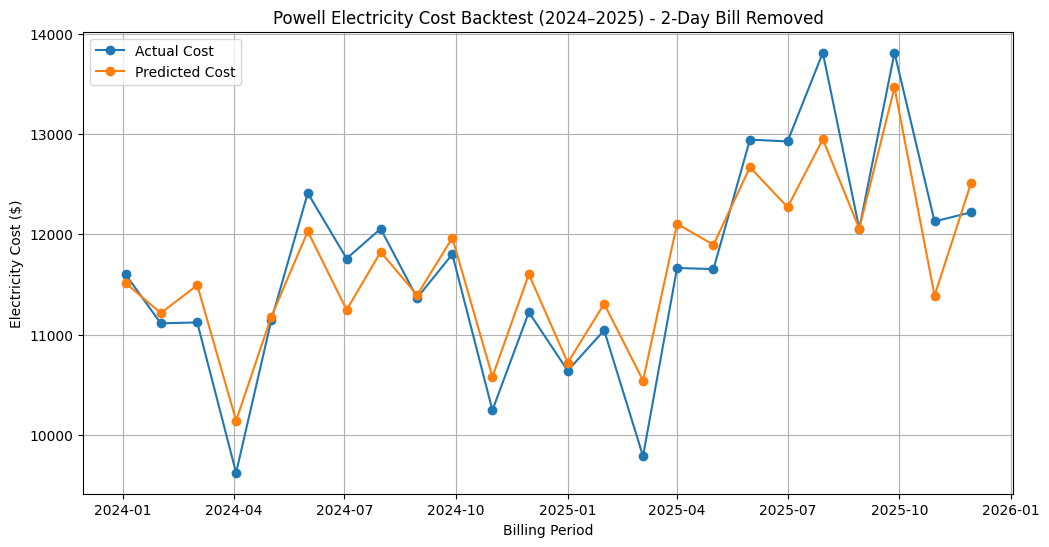


=== VARIANCE % PER BILLING PERIOD ===


,start,end,cost_variance_copy_%,cost_variance_gst_adj_%
0,2024-01-03,2024-01-31,0.74,0.78
1,2024-02-01,2024-03-01,-0.92,-0.97
2,2024-03-02,2024-03-31,-3.33,-3.50
3,2024-04-03,2024-05-01,-5.40,-5.67
4,2024-05-02,2024-05-31,-0.32,-0.33
5,2024-06-01,2024-07-02,3.07,3.23
6,2024-07-03,2024-07-30,4.35,4.57
7,2024-07-31,2024-08-29,1.91,2.01
8,2024-08-30,2024-09-27,-0.24,-0.25
9,2024-09-28,2024-10-30,-1.39,-1.46


In [ ]:
# ============================================
# POWELL ELECTRICITY BACKTEST (REMOVE 2-DAY BILL)
# Model:
#   kWh = const + b1*days + b2*production_kg
#
# Backtest logic:
#   1) fit model on 2024-2025 billing periods
#   2) remove short 2-day bill (2024-04-01 to 2024-04-02)
#   3) predict kWh
#   4) rebuild bill by copying all old bill charges
#      and replacing only the energy subtotal
#   5) compare actual vs predicted total due
# ============================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ============================================
# CONFIG
# ============================================
POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"

# model_df must already exist from your earlier pipeline
# expected columns in model_df:
#   start, end, days, production_kg, kwh

# ============================================
# HELPERS
# ============================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried: {candidates}\nAvailable: {list(df.columns)}")

def find_energy_subtotal_col(df, energy_used_col):
    cols = list(df.columns)
    idx = cols.index(energy_used_col)
    for i in range(idx + 1, len(cols)):
        if "subtotal" in cols[i].lower():
            return cols[i]
    raise ValueError(f"Could not find energy subtotal column after '{energy_used_col}'")

# ============================================
# 1) CLEAN MODEL DATA
#    Remove the 2-day transition bill
# ============================================
bt = model_df.copy()

bt["start"] = pd.to_datetime(bt["start"])
bt["end"] = pd.to_datetime(bt["end"])

# remove the short 2-day bill
bt = bt[bt["days"] > 2].copy()

# optional: if you want to remove that exact bill explicitly too
bt = bt[
    ~(
        (bt["start"] == pd.Timestamp("2024-04-01")) &
        (bt["end"] == pd.Timestamp("2024-04-02"))
    )
].copy()

print("Rows remaining after removing 2-day bill:", len(bt))

# ============================================
# 2) FIT ELECTRICITY MODEL
# ============================================
X_cols = ["days", "production_kg"]
X = sm.add_constant(bt[X_cols])
y = bt["kwh"]

model = sm.OLS(y, X).fit()

print("\n=== ELECTRICITY MODEL ===")
print(model.summary())

bt["kwh_pred"] = model.predict(X)
bt["error_kwh"] = bt["kwh"] - bt["kwh_pred"]
bt["abs_error_kwh"] = bt["error_kwh"].abs()
bt["ape_kwh"] = np.where(bt["kwh"] != 0, bt["abs_error_kwh"] / bt["kwh"], np.nan)

MAE_kwh = bt["abs_error_kwh"].mean()
RMSE_kwh = np.sqrt((bt["error_kwh"]**2).mean())
WAPE_kwh = bt["abs_error_kwh"].sum() / bt["kwh"].sum() * 100

print("\n=== KWH BACKTEST METRICS ===")
print(f"MAE kWh : {MAE_kwh:,.0f}")
print(f"RMSE kWh: {RMSE_kwh:,.0f}")
print(f"WAPE kWh: {WAPE_kwh:.2f}%")

# ============================================
# 3) LOAD ELECTRICITY BILL SHEET
# ============================================
elec = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
elec = normalize_cols(elec)
elec.columns = make_unique_columns(elec.columns)

start_col = pick_first_col(elec, ["Start Date"], "Start Date")
end_col   = pick_first_col(elec, ["End Date"], "End Date")
days_col  = pick_first_col(elec, ["Days"], "Days")
kwh_col   = pick_first_col(elec, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
total_col = pick_first_col(
    elec,
    ["Total Due", "Total Due $", "Total Due $.1", "Total Due  ", "Total Due Amount"],
    "Total Due"
)

gst_candidates = [c for c in elec.columns if "gst" in c.lower()]
gst_col = gst_candidates[0] if len(gst_candidates) > 0 else None

energy_subtotal_col = find_energy_subtotal_col(elec, kwh_col)

elec[start_col] = pd.to_datetime(elec[start_col], errors="coerce")
elec[end_col]   = pd.to_datetime(elec[end_col], errors="coerce")
elec[days_col]  = pd.to_numeric(elec[days_col], errors="coerce")
elec[kwh_col]   = pd.to_numeric(elec[kwh_col], errors="coerce")
elec[energy_subtotal_col] = pd.to_numeric(elec[energy_subtotal_col], errors="coerce")
elec[total_col] = pd.to_numeric(elec[total_col], errors="coerce")

if gst_col:
    elec[gst_col] = pd.to_numeric(elec[gst_col], errors="coerce").fillna(0)

bill = elec.dropna(subset=[start_col, end_col, kwh_col, energy_subtotal_col, total_col]).copy()

# remove the short 2-day bill from bill table too
bill = bill[
    ~(
        (bill[start_col] == pd.Timestamp("2024-04-01")) &
        (bill[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

print("\n=== DETECTED BILL COLUMNS ===")
print("start_col           =", start_col)
print("end_col             =", end_col)
print("days_col            =", days_col)
print("kwh_col             =", kwh_col)
print("energy_subtotal_col =", energy_subtotal_col)
print("total_col           =", total_col)
print("gst_col             =", gst_col)

# ============================================
# 4) MERGE MODEL PREDICTIONS WITH BILL TABLE
# ============================================
bt = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="left",
    suffixes=("", "_bill")
)

missing_merge = bt[total_col].isna().sum()
print("\nMerged bill rows missing actual bill info:", missing_merge)

# ============================================
# 5) REBUILD COST USING MODEL KWH
#    Copy all old charges, replace energy subtotal only
# ============================================
bt["energy_rate_actual"] = np.where(
    bt[kwh_col] != 0,
    bt[energy_subtotal_col] / bt[kwh_col],
    np.nan
)

bt["energy_subtotal_pred"] = bt["kwh_pred"] * bt["energy_rate_actual"]

# strict copy: all other charges unchanged
bt["pred_total_due_copy"] = (
    bt[total_col]
    - bt[energy_subtotal_col]
    + bt["energy_subtotal_pred"]
)

# GST adjusted version
if gst_col:
    bt["gst_pred"] = bt[gst_col] + 0.05 * (bt["energy_subtotal_pred"] - bt[energy_subtotal_col])

    bt["pred_total_due_gst_adj"] = (
        bt[total_col]
        - bt[energy_subtotal_col]
        - bt[gst_col]
        + bt["energy_subtotal_pred"]
        + bt["gst_pred"]
    )
else:
    bt["gst_pred"] = np.nan
    bt["pred_total_due_gst_adj"] = bt["pred_total_due_copy"]

# ============================================
# 6) COST VARIANCE
# ============================================
bt["cost_variance_copy_$"] = bt[total_col] - bt["pred_total_due_copy"]
bt["abs_cost_variance_copy_$"] = bt["cost_variance_copy_$"].abs()
bt["cost_variance_copy_%"] = np.where(
    bt[total_col] != 0,
    bt["cost_variance_copy_$"] / bt[total_col] * 100,
    np.nan
)

bt["cost_variance_gst_adj_$"] = bt[total_col] - bt["pred_total_due_gst_adj"]
bt["abs_cost_variance_gst_adj_$"] = bt["cost_variance_gst_adj_$"].abs()
bt["cost_variance_gst_adj_%"] = np.where(
    bt[total_col] != 0,
    bt["cost_variance_gst_adj_$"] / bt[total_col] * 100,
    np.nan
)

print("\n=== COST BACKTEST METRICS - STRICT COPY ===")
print(f"MAE $  : {bt['abs_cost_variance_copy_$'].mean():,.2f}")
print(f"RMSE $ : {np.sqrt((bt['cost_variance_copy_$']**2).mean()):,.2f}")
print(f"WAPE % : {bt['abs_cost_variance_copy_$'].sum()/bt[total_col].sum()*100:.2f}%")

print("\n=== COST BACKTEST METRICS - GST ADJUSTED ===")
print(f"MAE $  : {bt['abs_cost_variance_gst_adj_$'].mean():,.2f}")
print(f"RMSE $ : {np.sqrt((bt['cost_variance_gst_adj_$']**2).mean()):,.2f}")
print(f"WAPE % : {bt['abs_cost_variance_gst_adj_$'].sum()/bt[total_col].sum()*100:.2f}%")

# ============================================
# 7) FINAL COST BACKTEST TABLE
# ============================================
cost_backtest = bt[[
    "start",
    "end",
    "days",
    "production_kg",
    kwh_col,
    "kwh_pred",
    energy_subtotal_col,
    "energy_subtotal_pred",
    total_col,
    "pred_total_due_copy",
    "pred_total_due_gst_adj",
    "cost_variance_copy_$",
    "cost_variance_copy_%",
    "cost_variance_gst_adj_$",
    "cost_variance_gst_adj_%"
]].copy()

cost_backtest = cost_backtest.rename(columns={
    kwh_col: "kwh_actual",
    energy_subtotal_col: "energy_subtotal_actual",
    total_col: "actual_total_due"
})

cost_backtest = cost_backtest.sort_values("start").reset_index(drop=True)

print("\n=== COST BACKTEST TABLE ===")
display(cost_backtest)

# ============================================
# 8) WORST PERIODS
# ============================================
print("\n=== WORST 5 PERIODS - STRICT COPY ===")
display(
    cost_backtest.assign(abs_var=lambda d: d["cost_variance_copy_$"].abs())
    .sort_values("abs_var", ascending=False)
    .head(5)
)

print("\n=== WORST 5 PERIODS - GST ADJUSTED ===")
display(
    cost_backtest.assign(abs_var=lambda d: d["cost_variance_gst_adj_$"].abs())
    .sort_values("abs_var", ascending=False)
    .head(5)
)

# ============================================
# 9) YEARLY COST VARIANCE
# ============================================
cost_backtest["year"] = cost_backtest["start"].dt.year

year_cost = (
    cost_backtest.groupby("year", as_index=False)
    .apply(lambda g: pd.Series({
        "MAE_copy_$": g["cost_variance_copy_$"].abs().mean(),
        "WAPE_copy_%": g["cost_variance_copy_$"].abs().sum() / g["actual_total_due"].sum() * 100,
        "MAE_gst_adj_$": g["cost_variance_gst_adj_$"].abs().mean(),
        "WAPE_gst_adj_%": g["cost_variance_gst_adj_$"].abs().sum() / g["actual_total_due"].sum() * 100
    }))
    .reset_index(drop=True)
)

print("\n=== YEARLY COST VARIANCE ===")
display(year_cost)

# ============================================
# 10) ACTUAL VS PREDICTED COST PLOT
# ============================================
plot_df = cost_backtest.dropna(subset=["actual_total_due", "pred_total_due_copy"]).copy()

plt.figure(figsize=(12,6))
plt.plot(plot_df["start"], plot_df["actual_total_due"], marker="o", label="Actual Cost")
plt.plot(plot_df["start"], plot_df["pred_total_due_copy"], marker="o", label="Predicted Cost")
plt.title("Powell Electricity Cost Backtest (2024–2025) - 2-Day Bill Removed")
plt.xlabel("Billing Period")
plt.ylabel("Electricity Cost ($)")
plt.legend()
plt.grid(True)
plt.show()

# ============================================
# 11) VARIANCE % TABLE PER BILLING PERIOD
# ============================================
variance_pct = cost_backtest[["start", "end", "cost_variance_copy_%", "cost_variance_gst_adj_%"]].copy()
variance_pct["cost_variance_copy_%"] = variance_pct["cost_variance_copy_%"].round(2)
variance_pct["cost_variance_gst_adj_%"] = variance_pct["cost_variance_gst_adj_%"].round(2)

print("\n=== VARIANCE % PER BILLING PERIOD ===")
display(variance_pct)

# ============================================
# 12) OPTIONAL EXPORT
# ============================================
# cost_backtest.to_excel("/content/powell_729_cost_backtest_no_2day_bill.xlsx", index=False)
# print("Saved: /content/powell_729_cost_backtest_no_2day_bill.xlsx")

# **Back test with full break down cost**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"

# model_df must already exist
# expected columns: start, end, days, production_kg, kwh

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    print("\nAvailable columns:\n", list(df.columns))
    raise ValueError(f"Could not find '{label}'. Tried: {candidates}")

def safe_num(df, col):
    if col is None or col not in df.columns:
        return pd.Series(0.0, index=df.index)
    return pd.to_numeric(df[col], errors="coerce").fillna(0)

# =========================================================
# 1) FIT KWH MODEL
# =========================================================
bt = model_df.copy()
bt["start"] = pd.to_datetime(bt["start"])
bt["end"] = pd.to_datetime(bt["end"])

# optional: remove 2-day transition bill
bt = bt[
    ~(
        (bt["start"] == pd.Timestamp("2024-04-01")) &
        (bt["end"] == pd.Timestamp("2024-04-02"))
    )
].copy()

X = sm.add_constant(bt[["days", "production_kg"]])
y = bt["kwh"]

model = sm.OLS(y, X).fit()
bt["kwh_pred"] = model.predict(X)

print(model.summary())

# =========================================================
# 2) LOAD BILL
# =========================================================
elec = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
elec = normalize_cols(elec)
elec.columns = make_unique_columns(elec.columns)

# key fields
start_col = pick_first_col(elec, ["Start Date"], "Start Date")
end_col   = pick_first_col(elec, ["End Date"], "End Date")
days_col  = pick_first_col(elec, ["Days"], "Days")
kwh_col   = pick_first_col(elec, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
total_col = pick_first_col(
    elec,
    ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"],
    "Total Due"
)

# likely cost component columns
basic_charge_col = next((c for c in elec.columns if "basic charges" in c.lower()), None)
energy_subtotal_col = next((c for c in elec.columns if "subtotal" in c.lower()), None)

# second subtotal often demand
subtotal_cols = [c for c in elec.columns if "subtotal" in c.lower()]
demand_subtotal_col = subtotal_cols[1] if len(subtotal_cols) > 1 else None

kw_col = next((c for c in elec.columns if "demand registered" in c.lower()), None)
gst_col = next((c for c in elec.columns if "gst" in c.lower()), None)
transformer_col = next((c for c in elec.columns if "transformer" in c.lower()), None)
trade_adj_col = next((c for c in elec.columns if "trade" in c.lower()), None)
rate_rider_col = next((c for c in elec.columns if "rate rider" in c.lower() and "trade" not in c.lower()), None)
credit_col = next((c for c in elec.columns if "credit" in c.lower()), None)

# parse
elec[start_col] = pd.to_datetime(elec[start_col], errors="coerce")
elec[end_col] = pd.to_datetime(elec[end_col], errors="coerce")

for c in [
    days_col, kwh_col, total_col, basic_charge_col, energy_subtotal_col,
    demand_subtotal_col, kw_col, gst_col, transformer_col,
    trade_adj_col, rate_rider_col, credit_col
]:
    if c is not None and c in elec.columns:
        elec[c] = pd.to_numeric(elec[c], errors="coerce")

# remove the 2-day row if present
elec = elec[
    ~(
        (elec[start_col] == pd.Timestamp("2024-04-01")) &
        (elec[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

# =========================================================
# 3) MERGE MODEL WITH BILL
# =========================================================
detail = bt.merge(
    elec,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="left"
)

# =========================================================
# 4) BUILD DETAIL COST TABLE
# =========================================================
detail["days_actual"] = safe_num(detail, days_col)
detail["kwh_actual"] = safe_num(detail, kwh_col)
detail["kwh_pred"] = pd.to_numeric(detail["kwh_pred"], errors="coerce").fillna(0)

# actual bill components
detail["basic_actual_$"] = safe_num(detail, basic_charge_col)
detail["energy_actual_$"] = safe_num(detail, energy_subtotal_col)
detail["demand_actual_$"] = safe_num(detail, demand_subtotal_col)
detail["kw_actual"] = safe_num(detail, kw_col)
detail["transformer_actual_$"] = safe_num(detail, transformer_col)
detail["rate_rider_actual_$"] = safe_num(detail, rate_rider_col)
detail["trade_adj_actual_$"] = safe_num(detail, trade_adj_col)
detail["credit_actual_$"] = safe_num(detail, credit_col)
detail["gst_actual_$"] = safe_num(detail, gst_col)
detail["total_actual_$"] = safe_num(detail, total_col)

# derive actual energy rate
detail["energy_rate_actual"] = np.where(
    detail["kwh_actual"] != 0,
    detail["energy_actual_$"] / detail["kwh_actual"],
    np.nan
)

# predicted energy only
detail["energy_pred_$"] = detail["kwh_pred"] * detail["energy_rate_actual"]

# copy all other charges exactly
detail["basic_pred_$"] = detail["basic_actual_$"]
detail["demand_pred_$"] = detail["demand_actual_$"]
detail["kw_pred"] = detail["kw_actual"]
detail["transformer_pred_$"] = detail["transformer_actual_$"]
detail["rate_rider_pred_$"] = detail["rate_rider_actual_$"]
detail["trade_adj_pred_$"] = detail["trade_adj_actual_$"]
detail["credit_pred_$"] = detail["credit_actual_$"]

# pretax
detail["pretax_actual_$"] = (
    detail["basic_actual_$"]
    + detail["energy_actual_$"]
    + detail["demand_actual_$"]
    + detail["transformer_actual_$"]
    + detail["rate_rider_actual_$"]
    + detail["trade_adj_actual_$"]
    + detail["credit_actual_$"]
)

detail["pretax_pred_$"] = (
    detail["basic_pred_$"]
    + detail["energy_pred_$"]
    + detail["demand_pred_$"]
    + detail["transformer_pred_$"]
    + detail["rate_rider_pred_$"]
    + detail["trade_adj_pred_$"]
    + detail["credit_pred_$"]
)

# GST predicted on pretax basis
detail["gst_pred_$"] = detail["pretax_pred_$"] * 0.05

# totals
detail["total_pred_$"] = detail["pretax_pred_$"] + detail["gst_pred_$"]

# variances by line
detail["basic_var_$"] = detail["basic_actual_$"] - detail["basic_pred_$"]
detail["energy_var_$"] = detail["energy_actual_$"] - detail["energy_pred_$"]
detail["demand_var_$"] = detail["demand_actual_$"] - detail["demand_pred_$"]
detail["transformer_var_$"] = detail["transformer_actual_$"] - detail["transformer_pred_$"]
detail["rate_rider_var_$"] = detail["rate_rider_actual_$"] - detail["rate_rider_pred_$"]
detail["trade_adj_var_$"] = detail["trade_adj_actual_$"] - detail["trade_adj_pred_$"]
detail["credit_var_$"] = detail["credit_actual_$"] - detail["credit_pred_$"]
detail["pretax_var_$"] = detail["pretax_actual_$"] - detail["pretax_pred_$"]
detail["gst_var_$"] = detail["gst_actual_$"] - detail["gst_pred_$"]
detail["total_var_$"] = detail["total_actual_$"] - detail["total_pred_$"]

detail["total_var_%"] = np.where(
    detail["total_actual_$"] != 0,
    detail["total_var_$"] / detail["total_actual_$"] * 100,
    np.nan
)

# =========================================================
# 5) FINAL DETAIL VIEW
# =========================================================
detail_view = detail[[
    "start",
    "end",
    "days",
    "production_kg",
    "kwh_actual",
    "kwh_pred",
    "energy_rate_actual",
    "kw_actual",
    "kw_pred",

    "basic_actual_$",
    "basic_pred_$",
    "basic_var_$",

    "energy_actual_$",
    "energy_pred_$",
    "energy_var_$",

    "demand_actual_$",
    "demand_pred_$",
    "demand_var_$",

    "transformer_actual_$",
    "transformer_pred_$",
    "transformer_var_$",

    "rate_rider_actual_$",
    "rate_rider_pred_$",
    "rate_rider_var_$",

    "trade_adj_actual_$",
    "trade_adj_pred_$",
    "trade_adj_var_$",

    "credit_actual_$",
    "credit_pred_$",
    "credit_var_$",

    "pretax_actual_$",
    "pretax_pred_$",
    "pretax_var_$",

    "gst_actual_$",
    "gst_pred_$",
    "gst_var_$",

    "total_actual_$",
    "total_pred_$",
    "total_var_$",
    "total_var_%"
]].copy()

print("\n=== DETAIL BACKTEST TABLE ===")
display(detail_view)

# =========================================================
# 6) OPTIONAL: EXPORT
# =========================================================
# detail_view.to_excel("/content/powell_detail_backtest.xlsx", index=False)
# print("Saved to /content/powell_detail_backtest.xlsx")

                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     6.235
Date:                Wed, 11 Mar 2026   Prob (F-statistic):            0.00749
Time:                        15:52:15   Log-Likelihood:                -243.65
No. Observations:                  24   AIC:                             493.3
Df Residuals:                      21   BIC:                             496.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6324.9620    3.2e+04      0.197

,start,end,days,production_kg,kwh_actual,kwh_pred,energy_rate_actual,kw_actual,kw_pred,basic_actual_$,...,pretax_actual_$,pretax_pred_$,pretax_var_$,gst_actual_$,gst_pred_$,gst_var_$,total_actual_$,total_pred_$,total_var_$,total_var_%
0,2024-01-03,2024-01-31,29.0,296447.97,120960,119561.654898,0.000065,298.0000,298.0000,29,...,7352.196060,7352.105311,0.090749,552.409803,367.605266,184.804537,11600.6000,7719.710576,3880.889424,33.454213
1,2024-02-01,2024-03-01,30.0,265450.38,116160,117826.177365,0.000070,284.0000,284.0000,30,...,7063.440560,7063.557032,-0.116472,529.172028,353.177852,175.994176,11112.6100,7416.734883,3695.875117,33.258389
2,2024-03-02,2024-03-31,30.0,237767.23,108000,114038.246590,0.000075,269.0624,269.0624,30,...,6569.294000,6569.747987,-0.453987,495.128700,328.487399,166.641301,11122.4000,6898.235386,4224.164614,37.978895
3,2024-04-03,2024-05-01,29.0,210483.76,99840,107799.031187,0.000084,253.0000,253.0000,29,...,5817.757024,5818.423465,-0.666441,470.897851,290.921173,179.976678,9624.5600,6109.344639,3515.215361,36.523388
4,2024-05-02,2024-05-31,30.0,276501.35,118800,119338.299698,0.000073,293.0000,293.0000,30,...,6758.840218,6758.879412,-0.039194,566.271201,337.943971,228.327230,11145.1100,7096.823383,4048.286617,36.323433
5,2024-06-01,2024-07-02,32.0,254643.53,127200,121359.405369,0.000072,306.0000,306.0000,32,...,7243.491587,7243.068236,0.423351,601.325259,362.153412,239.171848,12410.4900,7605.221648,4805.268352,38.719409
6,2024-07-03,2024-07-30,28.0,255409.50,119280,111440.320306,0.000068,313.0000,313.0000,28,...,6804.174652,6803.644251,0.530401,580.679687,340.182213,240.497474,11758.9500,7143.826464,4615.123536,39.247752
7,2024-07-31,2024-08-29,30.0,253762.96,119760,116226.968536,0.000072,317.0000,317.0000,30,...,6791.267706,6791.012523,0.255183,596.279541,339.550626,256.728915,12055.4400,7130.563149,4924.876851,40.851905
8,2024-08-30,2024-09-27,29.0,279904.10,116880,117297.930058,0.000072,297.0000,297.0000,29,...,6651.272153,6651.302046,-0.029893,562.752832,332.565102,230.187729,11366.9200,6983.867148,4383.052852,38.559723
9,2024-09-28,2024-10-30,33.0,276286.51,124320,126826.823284,0.000076,275.0000,275.0000,33,...,7070.547210,7070.738973,-0.191762,572.190467,353.536949,218.653518,11801.2700,7424.275921,4376.994079,37.089178


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"

# model_df must already exist with:
# start, end, days, production_kg, kwh

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried: {candidates}\nAvailable: {list(df.columns)}")

def to_num(s):
    return pd.to_numeric(s, errors="coerce")

# =========================================================
# 1) FIT KWH MODEL
# =========================================================
bt = model_df.copy()
bt["start"] = pd.to_datetime(bt["start"])
bt["end"] = pd.to_datetime(bt["end"])

# remove 2-day transition bill
bt = bt[
    ~(
        (bt["start"] == pd.Timestamp("2024-04-01")) &
        (bt["end"] == pd.Timestamp("2024-04-02"))
    )
].copy()

X = sm.add_constant(bt[["days", "production_kg"]])
y = bt["kwh"]

model = sm.OLS(y, X).fit()
bt["kwh_pred"] = model.predict(X)

print(model.summary())

# =========================================================
# 2) LOAD BILL SHEET
# =========================================================
elec = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
elec = normalize_cols(elec)
elec.columns = make_unique_columns(elec.columns)

# key columns
start_col = pick_first_col(elec, ["Start Date"], "Start Date")
end_col   = pick_first_col(elec, ["End Date"], "End Date")
days_col  = pick_first_col(elec, ["Days"], "Days")
basic_col = pick_first_col(elec, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col   = pick_first_col(elec, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
total_col = pick_first_col(
    elec,
    ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"],
    "Total Due"
)

# convert date cols
elec[start_col] = pd.to_datetime(elec[start_col], errors="coerce")
elec[end_col] = pd.to_datetime(elec[end_col], errors="coerce")

# =========================================================
# 3) IDENTIFY REPEATED SUBTOTAL COLUMNS BY POSITION
# =========================================================
cols = list(elec.columns)

# all subtotal columns in order
subtotal_cols = [c for c in cols if "subtotal" in c.lower()]

# locate important anchors
kwh_idx = cols.index(kwh_col)
basic_idx = cols.index(basic_col)

# energy subtotal = first subtotal after Energy Used
energy_subtotal_col = None
for c in subtotal_cols:
    if cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break

if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

# demand registered / kW column
kw_actual_col = None
for c in cols:
    cl = c.lower()
    if "demand registered" in cl or cl == "demand registered":
        kw_actual_col = c
        break

if kw_actual_col is None:
    raise ValueError("Could not locate demand registered column.")

kw_idx = cols.index(kw_actual_col)

# demand subtotal = first subtotal after demand registered
demand_subtotal_col = None
for c in subtotal_cols:
    if cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break

if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

# GST / credits / riders
gst_col = next((c for c in cols if "gst" in c.lower()), None)
credit_col = next((c for c in cols if "credit" in c.lower()), None)
transformer_col = next((c for c in cols if "transformer" in c.lower()), None)
trade_adj_col = next((c for c in cols if "trade" in c.lower()), None)
rate_rider_col = next((c for c in cols if "rate rider" in c.lower() and "trade" not in c.lower()), None)

print("Mapped columns:")
print(" start_col            =", start_col)
print(" end_col              =", end_col)
print(" days_col             =", days_col)
print(" basic_col            =", basic_col)
print(" kwh_col              =", kwh_col)
print(" energy_subtotal_col  =", energy_subtotal_col)
print(" kw_actual_col        =", kw_actual_col)
print(" demand_subtotal_col  =", demand_subtotal_col)
print(" transformer_col      =", transformer_col)
print(" rate_rider_col       =", rate_rider_col)
print(" trade_adj_col        =", trade_adj_col)
print(" credit_col           =", credit_col)
print(" gst_col              =", gst_col)
print(" total_col            =", total_col)

# =========================================================
# 4) CLEAN NUMERIC COLUMNS
# =========================================================
num_candidates = [
    days_col, basic_col, kwh_col, energy_subtotal_col,
    kw_actual_col, demand_subtotal_col, transformer_col,
    rate_rider_col, trade_adj_col, credit_col, gst_col, total_col
]

for c in num_candidates:
    if c is not None and c in elec.columns:
        elec[c] = to_num(elec[c])

# remove 2-day row from bill too
elec = elec[
    ~(
        (elec[start_col] == pd.Timestamp("2024-04-01")) &
        (elec[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

# keep only good rows
bill = elec.dropna(subset=[start_col, end_col, kwh_col, total_col]).copy()

# =========================================================
# 5) MERGE MODEL WITH BILL
# =========================================================
detail = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="left"
)

# =========================================================
# 6) BUILD DETAIL BACKTEST TABLE
# =========================================================
detail["days_actual"] = to_num(detail[days_col]).fillna(0)
detail["kwh_actual"] = to_num(detail[kwh_col]).fillna(0)
detail["kwh_pred"] = to_num(detail["kwh_pred"]).fillna(0)

detail["basic_actual_$"] = to_num(detail[basic_col]).fillna(0)
detail["energy_actual_$"] = to_num(detail[energy_subtotal_col]).fillna(0)
detail["demand_actual_$"] = to_num(detail[demand_subtotal_col]).fillna(0)
detail["kw_actual"] = to_num(detail[kw_actual_col]).fillna(0)

detail["transformer_actual_$"] = to_num(detail[transformer_col]).fillna(0) if transformer_col else 0
detail["rate_rider_actual_$"] = to_num(detail[rate_rider_col]).fillna(0) if rate_rider_col else 0
detail["trade_adj_actual_$"] = to_num(detail[trade_adj_col]).fillna(0) if trade_adj_col else 0
detail["credit_actual_$"] = to_num(detail[credit_col]).fillna(0) if credit_col else 0
detail["gst_actual_$"] = to_num(detail[gst_col]).fillna(0) if gst_col else 0
detail["total_actual_$"] = to_num(detail[total_col]).fillna(0)

# actual energy rate
detail["energy_rate_actual"] = np.where(
    detail["kwh_actual"] != 0,
    detail["energy_actual_$"] / detail["kwh_actual"],
    np.nan
)

# predicted energy
detail["energy_pred_$"] = detail["kwh_pred"] * detail["energy_rate_actual"]

# copy everything else
detail["basic_pred_$"] = detail["basic_actual_$"]
detail["kw_pred"] = detail["kw_actual"]
detail["demand_pred_$"] = detail["demand_actual_$"]
detail["transformer_pred_$"] = detail["transformer_actual_$"]
detail["rate_rider_pred_$"] = detail["rate_rider_actual_$"]
detail["trade_adj_pred_$"] = detail["trade_adj_actual_$"]
detail["credit_pred_$"] = detail["credit_actual_$"]

# pretax totals
detail["pretax_actual_$"] = (
    detail["basic_actual_$"]
    + detail["energy_actual_$"]
    + detail["demand_actual_$"]
    + detail["transformer_actual_$"]
    + detail["rate_rider_actual_$"]
    + detail["trade_adj_actual_$"]
    + detail["credit_actual_$"]
)

detail["pretax_pred_$"] = (
    detail["basic_pred_$"]
    + detail["energy_pred_$"]
    + detail["demand_pred_$"]
    + detail["transformer_pred_$"]
    + detail["rate_rider_pred_$"]
    + detail["trade_adj_pred_$"]
    + detail["credit_pred_$"]
)

# GST: use the same bill logic you were using before
detail["gst_pred_$"] = detail["gst_actual_$"] + 0.05 * (
    detail["energy_pred_$"] - detail["energy_actual_$"]
)

detail["total_pred_$"] = detail["pretax_pred_$"] + detail["gst_pred_$"]

# variances
detail["basic_var_$"] = detail["basic_actual_$"] - detail["basic_pred_$"]
detail["energy_var_$"] = detail["energy_actual_$"] - detail["energy_pred_$"]
detail["demand_var_$"] = detail["demand_actual_$"] - detail["demand_pred_$"]
detail["transformer_var_$"] = detail["transformer_actual_$"] - detail["transformer_pred_$"]
detail["rate_rider_var_$"] = detail["rate_rider_actual_$"] - detail["rate_rider_pred_$"]
detail["trade_adj_var_$"] = detail["trade_adj_actual_$"] - detail["trade_adj_pred_$"]
detail["credit_var_$"] = detail["credit_actual_$"] - detail["credit_pred_$"]
detail["pretax_var_$"] = detail["pretax_actual_$"] - detail["pretax_pred_$"]
detail["gst_var_$"] = detail["gst_actual_$"] - detail["gst_pred_$"]
detail["total_var_$"] = detail["total_actual_$"] - detail["total_pred_$"]

detail["total_var_%"] = np.where(
    detail["total_actual_$"] != 0,
    detail["total_var_$"] / detail["total_actual_$"] * 100,
    np.nan
)

# =========================================================
# 7) FINAL VIEW
# =========================================================
detail_view = detail[[
    "start",
    "end",
    "days",
    "production_kg",
    "kwh_actual",
    "kwh_pred",
    "energy_rate_actual",
    "kw_actual",
    "kw_pred",

    "basic_actual_$",
    "basic_pred_$",
    "basic_var_$",

    "energy_actual_$",
    "energy_pred_$",
    "energy_var_$",

    "demand_actual_$",
    "demand_pred_$",
    "demand_var_$",

    "transformer_actual_$",
    "transformer_pred_$",
    "transformer_var_$",

    "rate_rider_actual_$",
    "rate_rider_pred_$",
    "rate_rider_var_$",

    "trade_adj_actual_$",
    "trade_adj_pred_$",
    "trade_adj_var_$",

    "credit_actual_$",
    "credit_pred_$",
    "credit_var_$",

    "pretax_actual_$",
    "pretax_pred_$",
    "pretax_var_$",

    "gst_actual_$",
    "gst_pred_$",
    "gst_var_$",

    "total_actual_$",
    "total_pred_$",
    "total_var_$",
    "total_var_%"
]].copy()

print("\n=== DETAIL BACKTEST TABLE ===")
display(detail_view)

print("\n=== SUMMARY ===")
print("Total actual $ :", round(detail_view["total_actual_$"].sum(), 2))
print("Total pred $   :", round(detail_view["total_pred_$"].sum(), 2))
print("WAPE %         :", round(detail_view["total_var_$"].abs().sum() / detail_view["total_actual_$"].sum() * 100, 2))

# optional export
# detail_view.to_excel("/content/powell_detail_backtest_fixed.xlsx", index=False)
# print("Saved: /content/powell_detail_backtest_fixed.xlsx")

                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     6.235
Date:                Wed, 11 Mar 2026   Prob (F-statistic):            0.00749
Time:                        15:52:15   Log-Likelihood:                -243.65
No. Observations:                  24   AIC:                             493.3
Df Residuals:                      21   BIC:                             496.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          6324.9620    3.2e+04      0.197

,start,end,days,production_kg,kwh_actual,kwh_pred,energy_rate_actual,kw_actual,kw_pred,basic_actual_$,...,pretax_actual_$,pretax_pred_$,pretax_var_$,gst_actual_$,gst_pred_$,gst_var_$,total_actual_$,total_pred_$,total_var_$,total_var_%
0,2024-01-03,2024-01-31,29.0,296447.97,120960,119561.654898,0.0614,298.0000,298.0000,29,...,11069.346060,10983.487671,85.858389,552.409803,548.116884,4.292919,11600.6000,11531.604554,68.995446,0.594758
1,2024-02-01,2024-03-01,30.0,265450.38,116160,117826.177365,0.0614,284.0000,284.0000,30,...,10605.320560,10707.623850,-102.303290,529.172028,534.287193,-5.115165,11112.6100,11241.911043,-129.301043,-1.163552
2,2024-03-02,2024-03-31,30.0,237767.23,108000,114038.246590,0.0614,269.0624,269.0624,30,...,9924.454000,10295.202341,-370.748341,495.128700,513.666117,-18.537417,11122.4000,10808.868458,313.531542,2.818920
3,2024-04-03,2024-05-01,29.0,210483.76,99840,107799.031187,0.0653,253.0000,253.0000,29,...,9174.297024,9694.021760,-519.724736,470.897851,496.884088,-25.986237,9624.5600,10190.905849,-566.345849,-5.884382
4,2024-05-02,2024-05-31,30.0,276501.35,118800,119338.299698,0.0653,293.0000,293.0000,30,...,10647.090218,10682.241188,-35.150970,566.271201,568.028749,-1.757549,11145.1100,11250.269937,-105.159937,-0.943552
5,2024-06-01,2024-07-02,32.0,254643.53,127200,121359.405369,0.0653,306.0000,306.0000,32,...,11304.071587,10922.680758,381.390829,601.325259,582.255718,19.069541,12410.4900,11504.936476,905.553524,7.296678
6,2024-07-03,2024-07-30,28.0,255409.50,119280,111440.320306,0.0653,313.0000,313.0000,28,...,10959.004652,10447.073568,511.931084,580.679687,555.083132,25.596554,11758.9500,11002.156701,756.793299,6.435892
7,2024-07-31,2024-08-29,30.0,253762.96,119760,116226.968536,0.0653,317.0000,317.0000,30,...,10998.717706,10768.010752,230.706955,596.279541,584.744194,11.535348,12055.4400,11352.754945,702.685055,5.828780
8,2024-08-30,2024-09-27,29.0,279904.10,116880,117297.930058,0.0653,297.0000,297.0000,29,...,10593.012153,10620.302986,-27.290833,562.752832,564.117373,-1.364542,11366.9200,11184.420359,182.499641,1.605533
9,2024-09-28,2024-10-30,33.0,276286.51,124320,126826.823284,0.0653,275.0000,275.0000,33,...,10718.537210,10882.232771,-163.695560,572.190467,580.375245,-8.184778,11801.2700,11462.608015,338.661985,2.869708



=== SUMMARY ===
Total actual $ : 280153.45
Total pred $   : 276838.85
WAPE %         : 4.13


In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# MERGE TRANSITION BILL IN model_df
# -----------------------------
model_df = model_df.copy()
model_df["start"] = pd.to_datetime(model_df["start"])
model_df["end"] = pd.to_datetime(model_df["end"])

short_start = pd.Timestamp("2024-04-01")
short_end   = pd.Timestamp("2024-04-02")

# locate short bill row
short_mask = (model_df["start"] == short_start) & (model_df["end"] == short_end)

if short_mask.sum() != 1:
    raise ValueError("Could not find exactly one 2-day row in model_df.")

short_row = model_df.loc[short_mask].iloc[0]

# previous row = row whose end is the day before short bill starts
prev_mask = model_df["end"] == (short_start - pd.Timedelta(days=1))

if prev_mask.sum() != 1:
    raise ValueError("Could not find exactly one previous row to merge into in model_df.")

prev_idx = model_df.index[prev_mask][0]

# merge values
model_df.loc[prev_idx, "end"] = short_end
model_df.loc[prev_idx, "days"] += short_row["days"]
model_df.loc[prev_idx, "kwh"] += short_row["kwh"]
model_df.loc[prev_idx, "production_kg"] += short_row["production_kg"]

# if these columns exist, merge them too
for c in ["runtime_primary", "runtime_secondary", "runtime_other", "non_production_days"]:
    if c in model_df.columns:
        model_df.loc[prev_idx, c] += short_row.get(c, 0)

# drop short row
model_df = model_df.loc[~short_mask].copy()
model_df = model_df.sort_values("start").reset_index(drop=True)

print("Merged transition bill in model_df.")
print(model_df.loc[(model_df["end"] == short_end)].head(1))

Merged transition bill in model_df.
       start        end  days       kwh  production_kg  runtime_primary  \
2 2024-03-02 2024-04-02  32.0  115440.0      248607.78          85293.0   

   runtime_secondary  runtime_other  
2            41181.0            0.0  


In [ ]:
import pandas as pd
import numpy as np

POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"

def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried: {candidates}\nAvailable: {list(df.columns)}")

# -----------------------------
# LOAD BILL TABLE
# -----------------------------
bill = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col   = pick_first_col(bill, ["End Date"], "End Date")
days_col  = pick_first_col(bill, ["Days"], "Days")

bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col]   = pd.to_datetime(bill[end_col], errors="coerce")

short_start = pd.Timestamp("2024-04-01")
short_end   = pd.Timestamp("2024-04-02")

short_mask = (bill[start_col] == short_start) & (bill[end_col] == short_end)
if short_mask.sum() != 1:
    raise ValueError("Could not find exactly one 2-day bill row in Electricity sheet.")

short_row = bill.loc[short_mask].iloc[0]

prev_mask = bill[end_col] == (short_start - pd.Timedelta(days=1))
if prev_mask.sum() != 1:
    raise ValueError("Could not find exactly one previous bill row in Electricity sheet.")

prev_idx = bill.index[prev_mask][0]

# update end date + days
bill.loc[prev_idx, end_col] = short_end
bill.loc[prev_idx, days_col] = pd.to_numeric(bill.loc[prev_idx, days_col], errors="coerce") + pd.to_numeric(short_row[days_col], errors="coerce")

# sum all numeric charge columns except the start/end date columns
exclude_cols = {start_col, end_col}
for c in bill.columns:
    if c in exclude_cols:
        continue
    prev_val = pd.to_numeric(pd.Series([bill.loc[prev_idx, c]]), errors="coerce").iloc[0]
    short_val = pd.to_numeric(pd.Series([short_row[c]]), errors="coerce").iloc[0]

    if not (pd.isna(prev_val) and pd.isna(short_val)):
        bill.loc[prev_idx, c] = (0 if pd.isna(prev_val) else prev_val) + (0 if pd.isna(short_val) else short_val)

# drop short row
bill = bill.loc[~short_mask].copy()
bill = bill.sort_values(start_col).reset_index(drop=True)

print("Merged transition bill in Electricity sheet.")
print(bill.loc[bill[end_col] == short_end, [start_col, end_col, days_col]].head(1))

Merged transition bill in Electricity sheet.
  Start Date   End Date  Days
2 2024-03-02 2024-04-02    34


In [ ]:
import statsmodels.api as sm
import numpy as np

# -----------------------------
# REFIT KWH MODEL
# -----------------------------
bt = model_df.copy()

X = sm.add_constant(bt[["days", "production_kg"]])
y = bt["kwh"]

model = sm.OLS(y, X).fit()
bt["kwh_pred"] = model.predict(X)

print(model.summary())

bt["error_kwh"] = bt["kwh"] - bt["kwh_pred"]
bt["abs_error_kwh"] = bt["error_kwh"].abs()

print("\nKWH Backtest Metrics")
print("MAE kWh :", round(bt["abs_error_kwh"].mean(), 0))
print("RMSE kWh:", round(np.sqrt((bt["error_kwh"]**2).mean()), 0))
print("WAPE kWh:", round(bt["abs_error_kwh"].sum() / bt["kwh"].sum() * 100, 2), "%")

                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     5.338
Date:                Wed, 11 Mar 2026   Prob (F-statistic):             0.0134
Time:                        15:52:16   Log-Likelihood:                -243.48
No. Observations:                  24   AIC:                             493.0
Df Residuals:                      21   BIC:                             496.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          1.426e+04    3.2e+04      0.445

In [ ]:
X = bt[["days", "production_kg"]]
y = bt["kwh"]

model = sm.OLS(y, X).fit()
bt["kwh_pred"] = model.predict(X)

print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                    kwh   R-squared (uncentered):                   0.997
Model:                            OLS   Adj. R-squared (uncentered):              0.997
Method:                 Least Squares   F-statistic:                              4038.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):                    5.95e-29
Time:                        15:52:16   Log-Likelihood:                         -243.59
No. Observations:                  24   AIC:                                      491.2
Df Residuals:                      22   BIC:                                      493.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

# **Demand Registered Regression**

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Load electricity bill
bill = pd.read_excel("/content/Powell Utilities.xlsx", sheet_name="Electricity")

bill["Start Date"] = pd.to_datetime(bill["Start Date"])
bill["End Date"] = pd.to_datetime(bill["End Date"])

# Select relevant columns
bill_kw = bill[[
    "Start Date",
    "End Date",
    "Demand Registered"
]].copy()

bill_kw = bill_kw.rename(columns={
    "Start Date":"start",
    "End Date":"end",
    "Demand Registered":"kw_actual"
})

# Merge with model_df
kw_df = model_df.merge(
    bill_kw,
    on=["start","end"],
    how="inner"
)

print(kw_df.head())

       start        end  days       kwh  production_kg  runtime_primary  \
0 2024-01-03 2024-01-31  29.0  120960.0      296447.97         101933.0   
1 2024-02-01 2024-03-01  30.0  116160.0      265450.38          87989.0   
2 2024-04-03 2024-05-01  29.0   99840.0      210483.76          73737.0   
3 2024-05-02 2024-05-31  30.0  118800.0      276501.35          91472.0   
4 2024-06-01 2024-07-02  32.0  127200.0      254643.53          82938.0   

   runtime_secondary  runtime_other  kw_actual  
0            45811.0            0.0      298.0  
1            41381.0            0.0      284.0  
2            33532.0            0.0      253.0  
3            43674.0            0.0      293.0  
4            40692.0            0.0      306.0  


In [ ]:
X = kw_df[[
    "production_kg",
    "runtime_secondary"
]]

X = sm.add_constant(X)

y = kw_df["kw_actual"]

model_kw = sm.OLS(y, X).fit()

print(model_kw.summary())

                            OLS Regression Results                            
Dep. Variable:              kw_actual   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                 -0.069
Method:                 Least Squares   F-statistic:                    0.2904
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.751
Time:                        15:52:16   Log-Likelihood:                -100.24
No. Observations:                  23   AIC:                             206.5
Df Residuals:                      20   BIC:                             209.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               291.4889     61.33

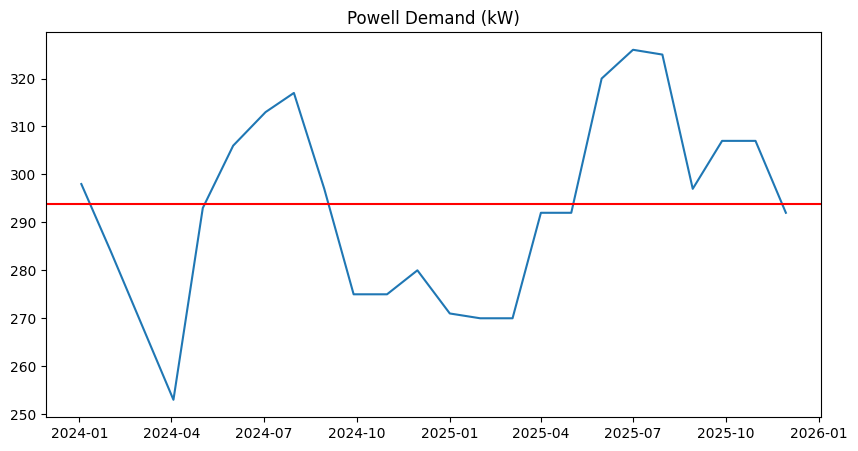

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(kw_df["start"], kw_df["kw_actual"])
plt.axhline(kw_df["kw_actual"].mean(), color="red")
plt.title("Powell Demand (kW)")
plt.show()

In [ ]:
kw_df["primary_runtime_day"] = kw_df["runtime_primary"] / kw_df["days"]
kw_df["secondary_runtime_day"] = kw_df["runtime_secondary"] / kw_df["days"]

X = sm.add_constant(kw_df[[
    "primary_runtime_day",
    "secondary_runtime_day"
]])

y = kw_df["kw_actual"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              kw_actual   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.082
Method:                 Least Squares   F-statistic:                    0.1654
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.849
Time:                        15:52:16   Log-Likelihood:                -100.38
No. Observations:                  23   AIC:                             206.8
Df Residuals:                      20   BIC:                             210.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                   322.15

In [ ]:
kw_df["secondary_share"] = (
    kw_df["runtime_secondary"] /
    (kw_df["runtime_primary"] + kw_df["runtime_secondary"])
)

X = sm.add_constant(kw_df[["secondary_share"]])
y = kw_df["kw_actual"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              kw_actual   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.047
Method:                 Least Squares   F-statistic:                   0.01407
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.907
Time:                        15:52:16   Log-Likelihood:                -100.57
No. Observations:                  23   AIC:                             205.1
Df Residuals:                      21   BIC:                             207.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             303.4094     80.161     

In [ ]:
kw_df = kw_df.sort_values("start")

kw_df["kw_pred"] = kw_df["kw_actual"].rolling(
    window=6,
    min_periods=1
).mean()

In [ ]:
kw_df["error_kw"] = kw_df["kw_actual"] - kw_df["kw_pred"]
kw_df["abs_error_kw"] = kw_df["error_kw"].abs()

import numpy as np

MAE = kw_df["abs_error_kw"].mean()
RMSE = np.sqrt((kw_df["error_kw"]**2).mean())
WAPE = kw_df["abs_error_kw"].sum() / kw_df["kw_actual"].sum()

print("Demand model performance")
print("MAE:", round(MAE,2), "kW")
print("RMSE:", round(RMSE,2))
print("WAPE:", round(WAPE*100,2), "%")

Demand model performance
MAE: 15.13 kW
RMSE: 17.71
WAPE: 5.15 %


In [ ]:
DEMAND_RATE = 12.5

kw_df["demand_pred_$"] = kw_df["kw_pred"] * DEMAND_RATE
kw_df["demand_actual_$"] = kw_df["kw_actual"] * DEMAND_RATE

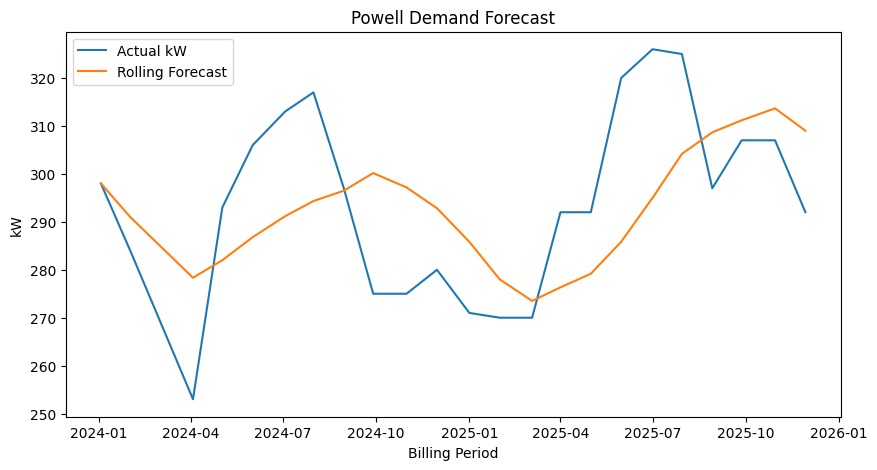

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(kw_df["start"], kw_df["kw_actual"], label="Actual kW")
plt.plot(kw_df["start"], kw_df["kw_pred"], label="Rolling Forecast")

plt.legend()
plt.title("Powell Demand Forecast")
plt.ylabel("kW")
plt.xlabel("Billing Period")

plt.show()

In [ ]:
kw_df["month"] = kw_df["start"].dt.month

kw_df["summer"] = kw_df["month"].isin([6,7,8]).astype(int)

In [ ]:
import statsmodels.api as sm

X = sm.add_constant(kw_df[["summer"]])
y = kw_df["kw_actual"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              kw_actual   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     12.38
Date:                Wed, 11 Mar 2026   Prob (F-statistic):            0.00204
Time:                        15:52:17   Log-Likelihood:                -95.243
No. Observations:                  23   AIC:                             194.5
Df Residuals:                      21   BIC:                             196.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        286.1875      3.980     71.908      0.0

In [ ]:
import pandas as pd
import numpy as np

# =========================
# COPY DATA
# =========================

bt = model_df.copy()

# =========================
# CREATE MONTH + SUMMER FLAG
# =========================

bt["month"] = bt["start"].dt.month

bt["summer"] = bt["month"].isin([6,7,8]).astype(int)

# =========================
# ENERGY MODEL
# =========================

BASE_KWH_DAY = 2646
PROD_KWH_INTENSITY = 0.145

bt["kwh_pred"] = (
    BASE_KWH_DAY * bt["days"]
    + PROD_KWH_INTENSITY * bt["production_kg"]
)

# =========================
# DEMAND MODEL
# =========================

BASE_KW = 286.19
SUMMER_ADJ = 25.38

bt["kw_pred"] = (
    BASE_KW
    + SUMMER_ADJ * bt["summer"]
)

# =========================
# MERGE ACTUAL DATA FROM 'detail' (from zkGJLj_0a2PI)
# =========================
# The 'detail' DataFrame from previous cell zkGJLj_0a2PI already contains
# the kwh_actual, kw_actual, and total_actual_$ aligned with the model_df
# after handling the 2-day bill.

actual_cols_to_merge = [
    "start",
    "end",
    "kwh_actual",
    "kw_actual",
    "total_actual_$",
    "energy_rate_actual", # Added this column
    "demand_actual_$"    # Added this column to calculate demand_rate_actual
]

bt = bt.merge(detail[actual_cols_to_merge], on=['start', 'end'], how='left')

# Calculate demand_rate_actual after merging actuals
bt["demand_rate_actual"] = np.where(
    bt["kw_actual"] != 0,
    bt["demand_actual_$"] / bt["kw_actual"],
    np.nan
)

# =========================
# COST CALCULATIONS
# =========================

# Use the dynamically calculated actual rates
bt["energy_pred_$"] = bt["kwh_pred"] * bt["energy_rate_actual"]
bt["demand_pred_$"] = bt["kw_pred"] * bt["demand_rate_actual"]

bt["pretax_pred_$"] = (
    bt["energy_pred_$"]
    + bt["demand_pred_$"]
)

bt["total_pred_$"] = bt["pretax_pred_$"] * 1.05

# =========================
# COMPARE TO ACTUAL
# =========================

bt["error_$"] = bt["total_actual_$"] - bt["total_pred_$"]
bt["abs_error_$"] = bt["error_$"].abs()

# =========================
# PERFORMANCE METRICS
# =========================

# Ensure there are no NaNs in total_actual_$ for WAPE calculation
bt_cleaned_for_metrics = bt.dropna(subset=['total_actual_$'])

MAE = bt_cleaned_for_metrics["abs_error_$"].mean()
RMSE = np.sqrt((bt_cleaned_for_metrics["error_$"]**2).mean())
WAPE = bt_cleaned_for_metrics["abs_error_$"].sum() / bt_cleaned_for_metrics["total_actual_$"].sum()

print("Backtest Performance")
print("MAE:", round(MAE,2))
print("RMSE:", round(RMSE,2))
print("WAPE:", round(WAPE*100,2), "%")

# =========================
# VIEW RESULTS
# =========================

print(bt[[
    "start",
    "kwh_actual",
    "kwh_pred",
    "kw_actual",
    "kw_pred",
    "total_actual_$",
    "total_pred_$",
    "error_$"
]].tail(12))

Backtest Performance
MAE: 864.88
RMSE: 1029.33
WAPE: 7.39 %
        start  kwh_actual      kwh_pred  kw_actual  kw_pred  total_actual_$  \
12 2025-01-01    115200.0  116374.45320      271.0   286.19      10641.3090   
13 2025-01-31    121680.0  126215.76440      270.0   286.19      11043.7900   
14 2025-03-04    101520.0  112840.65650      270.0   286.19       9788.9200   
15 2025-04-01    112560.0  119192.31650      292.0   286.19      11664.5455   
16 2025-05-01    112560.0  116087.15310      292.0   286.19      11653.6980   
17 2025-05-31    122160.0  118131.33205      320.0   286.19      12943.6300   
18 2025-07-01    123840.0  113965.70655      326.0   311.57      12925.7100   
19 2025-07-30    129840.0  117063.64835      325.0   311.57      13809.4300   
20 2025-08-29    114000.0  113841.06020      297.0   311.57      12056.1915   
21 2025-09-27    130080.0  125399.61970      307.0   286.19      13809.4300   
22 2025-10-30    130080.0  119244.33090      307.0   286.19      12128.

New kW model

In [ ]:
kw_df["runtime_total"] = (
    kw_df["runtime_primary"] +
    kw_df["runtime_secondary"]
)

kw_df["runtime_intensity"] = (
    kw_df["runtime_total"] /
    kw_df["days"]
)

In [ ]:
kw_df["runtime_total"] = (
    kw_df["runtime_primary"] +
    kw_df["runtime_secondary"]
)

kw_df["runtime_intensity"] = (
    kw_df["runtime_total"] /
    kw_df["days"]
)

In [ ]:
X = kw_df[[
    "runtime_primary",
    "runtime_secondary"
]]

X = sm.add_constant(X)

y = kw_df["kw_actual"]

model_kw = sm.OLS(y, X).fit()

In [ ]:
kw_df["runtime_intensity"] = (
    (kw_df["runtime_primary"] + kw_df["runtime_secondary"]) /
    kw_df["days"]
)

X = kw_df[[
    "runtime_intensity",
    "summer"
]]

X = sm.add_constant(X)

y = kw_df["kw_actual"]

model_kw = sm.OLS(y, X).fit()

print(model_kw.summary())

                            OLS Regression Results                            
Dep. Variable:              kw_actual   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     6.283
Date:                Wed, 11 Mar 2026   Prob (F-statistic):            0.00763
Time:                        15:52:17   Log-Likelihood:                -94.966
No. Observations:                  23   AIC:                             195.9
Df Residuals:                      20   BIC:                             199.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               255.1883     44.58

In [ ]:
bt["runtime_intensity"] = (
    (bt["runtime_primary"] + bt["runtime_secondary"]) /
    bt["days"]
)

bt["kw_pred"] = model_kw.predict(
    sm.add_constant(bt[["runtime_intensity","summer"]])
)

In [ ]:
bt["energy_actual_$"] = bt["kwh_actual"] * bt["energy_rate_actual"]
bt["demand_actual_$"] = bt["kw_actual"] * bt["demand_rate_actual"]

bt["energy_pred_$"] = bt["kwh_pred"] * bt["energy_rate_actual"]
bt["demand_pred_$"] = bt["kw_pred"] * bt["demand_rate_actual"]

bt["energy_error_$"] = bt["energy_actual_$"] - bt["energy_pred_$"]
bt["demand_error_$"] = bt["demand_actual_$"] - bt["demand_pred_$"]

print("Energy MAE:", bt["energy_error_$"].abs().mean())
print("Demand MAE:", bt["demand_error_$"].abs().mean())

Energy MAE: 338.7829170328263
Demand MAE: 169.41648360652277


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"
OUTPUT_FILE = "/content/powell_billing_period_detail_backtest.xlsx"

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried {candidates}\nAvailable: {list(df.columns)}")

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

# =========================================================
# 1) START WITH model_df
#    expected columns in model_df:
#    start, end, days, production_kg, kwh
# =========================================================
bt = model_df.copy()
bt["start"] = pd.to_datetime(bt["start"])
bt["end"] = pd.to_datetime(bt["end"])

# remove 2-day transition bill if still present
bt = bt[
    ~(
        (bt["start"] == pd.Timestamp("2024-04-01")) &
        (bt["end"] == pd.Timestamp("2024-04-02"))
    )
].copy()

# summer flag for demand model
bt["month"] = bt["start"].dt.month
bt["summer"] = bt["month"].isin([6, 7, 8]).astype(int)

# =========================================================
# 2) KWH MODEL
#    uncentered model you accepted:
#    kWh = 2645.6461 * days + 0.1448 * production_kg
# =========================================================
KWH_DAY_COEF = 2645.6461
KWH_KG_COEF = 0.1448

bt["kwh_pred"] = (
    KWH_DAY_COEF * bt["days"] +
    KWH_KG_COEF * bt["production_kg"]
)

# =========================================================
# 3) KW MODEL
#    kw = 286.1875 + 25.3839 * summer
# =========================================================
KW_BASE = 286.1875
KW_SUMMER = 25.3839

bt["kw_pred"] = KW_BASE + KW_SUMMER * bt["summer"]

# =========================================================
# 4) LOAD ACTUAL BILL SHEET
# =========================================================
bill = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

# key columns
start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col   = pick_first_col(bill, ["End Date"], "End Date")
days_col  = pick_first_col(bill, ["Days"], "Days")
basic_col = pick_first_col(bill, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col   = pick_first_col(bill, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
kw_col    = pick_first_col(bill, ["Demand Registered"], "Demand Registered")
total_col = pick_first_col(bill, ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"], "Total Due")

# repeated subtotal columns
all_cols = list(bill.columns)
subtotal_cols = [c for c in all_cols if "subtotal" in c.lower()]

# energy subtotal = first subtotal after Energy Used
kwh_idx = all_cols.index(kwh_col)
energy_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break

if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

# demand subtotal = first subtotal after Demand Registered
kw_idx = all_cols.index(kw_col)
demand_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break

if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

# other bill columns if available
gst_col = next((c for c in all_cols if "gst" in c.lower()), None)
transformer_col = next((c for c in all_cols if "transformer" in c.lower()), None)
rate_rider_col = next((c for c in all_cols if "deferral rate rider" in c.lower()), None)
trade_adj_col = next((c for c in all_cols if "trade income rate rider" in c.lower()), None)
credit_col = next((c for c in all_cols if "credit" in c.lower()), None)

# parse dates
bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col]   = pd.to_datetime(bill[end_col], errors="coerce")

# numeric conversion
num_cols = [
    days_col, basic_col, kwh_col, kw_col,
    energy_subtotal_col, demand_subtotal_col,
    gst_col, transformer_col, rate_rider_col,
    trade_adj_col, credit_col, total_col
]

for c in num_cols:
    if c is not None and c in bill.columns:
        bill[c] = to_num(bill[c])

# remove the 2-day transition bill from source bill too
bill = bill[
    ~(
        (bill[start_col] == pd.Timestamp("2024-04-01")) &
        (bill[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

# keep usable rows
bill = bill.dropna(subset=[start_col, end_col, total_col]).copy()

# =========================================================
# 5) MERGE MODEL PREDICTIONS INTO BILL
# =========================================================
detail = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="inner"
)

# =========================================================
# 6) ACTUAL BILL COLUMNS
# =========================================================
detail["days_actual"] = to_num(detail[days_col]).fillna(0)
detail["kwh_actual"] = to_num(detail[kwh_col]).fillna(0)
detail["kw_actual"] = to_num(detail[kw_col]).fillna(0)

detail["basic_actual_$"] = to_num(detail[basic_col]).fillna(0)
detail["energy_actual_$"] = to_num(detail[energy_subtotal_col]).fillna(0)
detail["demand_actual_$"] = to_num(detail[demand_subtotal_col]).fillna(0)

detail["transformer_actual_$"] = to_num(detail[transformer_col]).fillna(0) if transformer_col else 0
detail["rate_rider_actual_$"] = to_num(detail[rate_rider_col]).fillna(0) if rate_rider_col else 0
detail["trade_adj_actual_$"] = to_num(detail[trade_adj_col]).fillna(0) if trade_adj_col else 0
detail["credit_actual_$"] = to_num(detail[credit_col]).fillna(0) if credit_col else 0
detail["gst_actual_$"] = to_num(detail[gst_col]).fillna(0) if gst_col else 0
detail["total_actual_$"] = to_num(detail[total_col]).fillna(0)

# actual rates from invoice
detail["energy_rate_actual"] = np.where(
    detail["kwh_actual"] != 0,
    detail["energy_actual_$"] / detail["kwh_actual"],
    np.nan
)

detail["demand_rate_actual"] = np.where(
    detail["kw_actual"] != 0,
    detail["demand_actual_$"] / detail["kw_actual"],
    np.nan
)

# =========================================================
# 7) PREDICTED BILL COLUMNS
# =========================================================
detail["basic_pred_$"] = detail["basic_actual_$"]   # copy actual
detail["kwh_pred"] = detail["kwh_pred"]
detail["kw_pred"] = detail["kw_pred"]

detail["energy_pred_$"] = detail["kwh_pred"] * detail["energy_rate_actual"]
detail["demand_pred_$"] = detail["kw_pred"] * detail["demand_rate_actual"]

# copy other lines from actual bill
detail["transformer_pred_$"] = detail["transformer_actual_$"]
detail["rate_rider_pred_$"] = detail["rate_rider_actual_$"]
detail["trade_adj_pred_$"] = detail["trade_adj_actual_$"]
detail["credit_pred_$"] = detail["credit_actual_$"]

# pretax
detail["pretax_actual_$"] = (
    detail["basic_actual_$"] +
    detail["energy_actual_$"] +
    detail["demand_actual_$"] +
    detail["transformer_actual_$"] +
    detail["rate_rider_actual_$"] +
    detail["trade_adj_actual_$"] +
    detail["credit_actual_$"]
)

detail["pretax_pred_$"] = (
    detail["basic_pred_$"] +
    detail["energy_pred_$"] +
    detail["demand_pred_$"] +
    detail["transformer_pred_$"] +
    detail["rate_rider_pred_$"] +
    detail["trade_adj_pred_$"] +
    detail["credit_pred_$"]
)

# GST adjusted using predicted pretax
detail["gst_pred_$"] = detail["pretax_pred_$"] * 0.05

# predicted total
detail["total_pred_$"] = detail["pretax_pred_$"] + detail["gst_pred_$"]

# =========================================================
# 8) VARIANCE BY LINE
# =========================================================
detail["basic_var_$"] = detail["basic_actual_$"] - detail["basic_pred_$"]
detail["kwh_var"] = detail["kwh_actual"] - detail["kwh_pred"]
detail["kw_var"] = detail["kw_actual"] - detail["kw_pred"]

detail["energy_var_$"] = detail["energy_actual_$"] - detail["energy_pred_$"]
detail["demand_var_$"] = detail["demand_actual_$"] - detail["demand_pred_$"]
detail["transformer_var_$"] = detail["transformer_actual_$"] - detail["transformer_pred_$"]
detail["rate_rider_var_$"] = detail["rate_rider_actual_$"] - detail["rate_rider_pred_$"]
detail["trade_adj_var_$"] = detail["trade_adj_actual_$"] - detail["trade_adj_pred_$"]
detail["credit_var_$"] = detail["credit_actual_$"] - detail["credit_pred_$"]
detail["pretax_var_$"] = detail["pretax_actual_$"] - detail["pretax_pred_$"]
detail["gst_var_$"] = detail["gst_actual_$"] - detail["gst_pred_$"]
detail["total_var_$"] = detail["total_actual_$"] - detail["total_pred_$"]
detail["total_var_%"] = np.where(
    detail["total_actual_$"] != 0,
    detail["total_var_$"] / detail["total_actual_$"] * 100,
    np.nan
)

# =========================================================
# 9) FINAL TABLE — SAME BILLING PERIOD, NOT GROUPED
# =========================================================
detail_backtest = detail[[
    "start",
    "end",
    "days_actual",

    "production_kg",

    "kwh_actual",
    "kwh_pred",
    "kwh_var",

    "kw_actual",
    "kw_pred",
    "kw_var",

    "energy_rate_actual",
    "demand_rate_actual",

    "basic_actual_$",
    "basic_pred_$",
    "basic_var_$",

    "energy_actual_$",
    "energy_pred_$",
    "energy_var_$",

    "demand_actual_$",
    "demand_pred_$",
    "demand_var_$",

    "transformer_actual_$",
    "transformer_pred_$",
    "transformer_var_$",

    "rate_rider_actual_$",
    "rate_rider_pred_$",
    "rate_rider_var_$",

    "trade_adj_actual_$",
    "trade_adj_pred_$",
    "trade_adj_var_$",

    "credit_actual_$",
    "credit_pred_$",
    "credit_var_$",

    "pretax_actual_$",
    "pretax_pred_$",
    "pretax_var_$",

    "gst_actual_$",
    "gst_pred_$",
    "gst_var_$",

    "total_actual_$",
    "total_pred_$",
    "total_var_$",
    "total_var_%"
]].copy()

detail_backtest = detail_backtest.sort_values("start").reset_index(drop=True)

# =========================================================
# 10) SUMMARY
# =========================================================
mae_total = detail_backtest["total_var_$"].abs().mean()
rmse_total = np.sqrt((detail_backtest["total_var_$"] ** 2).mean())
wape_total = detail_backtest["total_var_$"].abs().sum() / detail_backtest["total_actual_$"].sum() * 100

print("=== BACKTEST SUMMARY ===")
print(f"MAE $  : {mae_total:,.2f}")
print(f"RMSE $ : {rmse_total:,.2f}")
print(f"WAPE % : {wape_total:.2f}%")

print("\n=== DETAIL BACKTEST TABLE ===")
print(detail_backtest)

# =========================================================
# 11) EXPORT TO EXCEL
# =========================================================
detail_backtest.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== BACKTEST SUMMARY ===
MAE $  : 575.40
RMSE $ : 743.04
WAPE % : 4.92%

=== DETAIL BACKTEST TABLE ===
        start        end  days_actual  production_kg  kwh_actual  \
0  2024-01-03 2024-01-31           29      296447.97      120960   
1  2024-02-01 2024-03-01           30      265450.38      116160   
2  2024-04-03 2024-05-01           29      210483.76       99840   
3  2024-05-02 2024-05-31           30      276501.35      118800   
4  2024-06-01 2024-07-02           32      254643.53      127200   
5  2024-07-03 2024-07-30           28      255409.50      119280   
6  2024-07-31 2024-08-29           30      253762.96      119760   
7  2024-08-30 2024-09-27           29      279904.10      116880   
8  2024-09-28 2024-10-30           33      276286.51      124320   
9  2024-10-31 2024-11-29           30      264304.41      112560   
10 2024-11-30 2024-12-31           32      304575.93      122400   
11 2025-01-01 2025-01-30           30      255134.16      115200   
12 2025-01-31

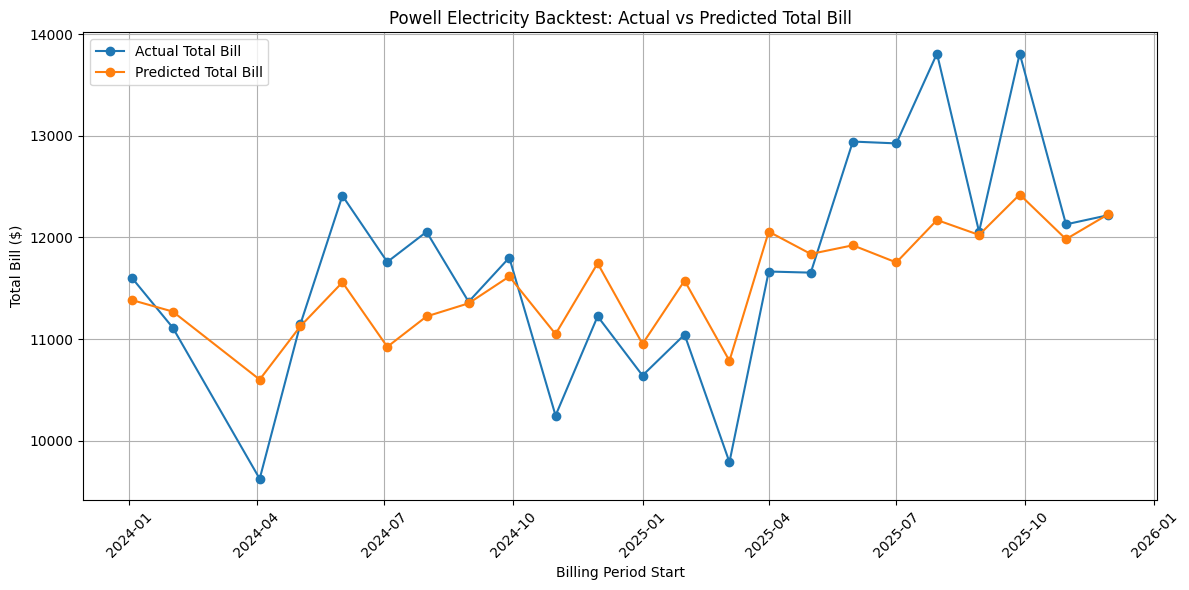

In [ ]:
import matplotlib.pyplot as plt

plot_df = detail_backtest.copy()
plot_df["start"] = pd.to_datetime(plot_df["start"])

plt.figure(figsize=(12, 6))
plt.plot(plot_df["start"], plot_df["total_actual_$"], marker="o", label="Actual Total Bill")
plt.plot(plot_df["start"], plot_df["total_pred_$"], marker="o", label="Predicted Total Bill")

plt.title("Powell Electricity Backtest: Actual vs Predicted Total Bill")
plt.xlabel("Billing Period Start")
plt.ylabel("Total Bill ($)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
POWELL_UTIL = "/content/Powell Utilities.xlsx"
ELECTRICITY_SHEET = "Electricity"
OUTPUT_FILE = "/content/powell_backtest_kwh_days_prod_summer.xlsx"

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried {candidates}\nAvailable: {list(df.columns)}")

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

# =========================================================
# 1) START WITH model_df
# expected columns:
# start, end, days, production_kg, kwh
# =========================================================
bt = model_df.copy()
bt["start"] = pd.to_datetime(bt["start"])
bt["end"] = pd.to_datetime(bt["end"])

# remove 2-day transition bill if still present
bt = bt[
    ~(
        (bt["start"] == pd.Timestamp("2024-04-01")) &
        (bt["end"] == pd.Timestamp("2024-04-02"))
    )
].copy()

bt["month"] = bt["start"].dt.month
bt["summer"] = bt["month"].isin([6, 7, 8]).astype(int)

# =========================================================
# 2) IMPROVED KWH MODEL: days + production + summer
# =========================================================
X_kwh = bt[["days", "production_kg", "summer"]]
X_kwh = sm.add_constant(X_kwh)
y_kwh = bt["kwh"]

model_kwh = sm.OLS(y_kwh, X_kwh).fit()
bt["kwh_pred"] = model_kwh.predict(X_kwh)

print("=== IMPROVED KWH MODEL ===")
print(model_kwh.summary())

# =========================================================
# 3) KW MODEL: seasonal demand model
#    kw = 286.1875 + 25.3839 * summer
# =========================================================
KW_BASE = 286.1875
KW_SUMMER = 25.3839
bt["kw_pred"] = KW_BASE + KW_SUMMER * bt["summer"]

# =========================================================
# 4) LOAD ACTUAL BILL SHEET
# =========================================================
bill = pd.read_excel(POWELL_UTIL, sheet_name=ELECTRICITY_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

# key columns
start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col   = pick_first_col(bill, ["End Date"], "End Date")
days_col  = pick_first_col(bill, ["Days"], "Days")
basic_col = pick_first_col(bill, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col   = pick_first_col(bill, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
kw_col    = pick_first_col(bill, ["Demand Registered"], "Demand Registered")
total_col = pick_first_col(bill, ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"], "Total Due")

all_cols = list(bill.columns)
subtotal_cols = [c for c in all_cols if "subtotal" in c.lower()]

# energy subtotal = first subtotal after Energy Used
kwh_idx = all_cols.index(kwh_col)
energy_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break

if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

# demand subtotal = first subtotal after Demand Registered
kw_idx = all_cols.index(kw_col)
demand_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break

if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

# other bill columns
gst_col = next((c for c in all_cols if "gst" in c.lower()), None)
transformer_col = next((c for c in all_cols if "transformer" in c.lower()), None)
rate_rider_col = next((c for c in all_cols if "deferral rate rider" in c.lower()), None)
trade_adj_col = next((c for c in all_cols if "trade income rate rider" in c.lower()), None)
credit_col = next((c for c in all_cols if "credit" in c.lower()), None)

# parse dates
bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col]   = pd.to_datetime(bill[end_col], errors="coerce")

# numeric conversion
num_cols = [
    days_col, basic_col, kwh_col, kw_col,
    energy_subtotal_col, demand_subtotal_col,
    gst_col, transformer_col, rate_rider_col,
    trade_adj_col, credit_col, total_col
]

for c in num_cols:
    if c is not None and c in bill.columns:
        bill[c] = to_num(bill[c])

# remove 2-day row from bill too
bill = bill[
    ~(
        (bill[start_col] == pd.Timestamp("2024-04-01")) &
        (bill[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

bill = bill.dropna(subset=[start_col, end_col, total_col]).copy()

# =========================================================
# 5) MERGE PREDICTIONS INTO BILL
# =========================================================
detail = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="inner"
)

# =========================================================
# 6) ACTUAL BILL COLUMNS
# =========================================================
detail["days_actual"] = to_num(detail[days_col]).fillna(0)
detail["kwh_actual"] = to_num(detail[kwh_col]).fillna(0)
detail["kw_actual"] = to_num(detail[kw_col]).fillna(0)

detail["basic_actual_$"] = to_num(detail[basic_col]).fillna(0)
detail["energy_actual_$"] = to_num(detail[energy_subtotal_col]).fillna(0)
detail["demand_actual_$"] = to_num(detail[demand_subtotal_col]).fillna(0)

detail["transformer_actual_$"] = to_num(detail[transformer_col]).fillna(0) if transformer_col else 0
detail["rate_rider_actual_$"] = to_num(detail[rate_rider_col]).fillna(0) if rate_rider_col else 0
detail["trade_adj_actual_$"] = to_num(detail[trade_adj_col]).fillna(0) if trade_adj_col else 0
detail["credit_actual_$"] = to_num(detail[credit_col]).fillna(0) if credit_col else 0
detail["gst_actual_$"] = to_num(detail[gst_col]).fillna(0) if gst_col else 0
detail["total_actual_$"] = to_num(detail[total_col]).fillna(0)

# invoice rates
detail["energy_rate_actual"] = np.where(
    detail["kwh_actual"] != 0,
    detail["energy_actual_$"] / detail["kwh_actual"],
    np.nan
)

detail["demand_rate_actual"] = np.where(
    detail["kw_actual"] != 0,
    detail["demand_actual_$"] / detail["kw_actual"],
    np.nan
)

# =========================================================
# 7) PREDICTED BILL COLUMNS
# =========================================================
detail["basic_pred_$"] = detail["basic_actual_$"]
detail["energy_pred_$"] = detail["kwh_pred"] * detail["energy_rate_actual"]
detail["demand_pred_$"] = detail["kw_pred"] * detail["demand_rate_actual"]

# copy other lines from actual bill
detail["transformer_pred_$"] = detail["transformer_actual_$"]
detail["rate_rider_pred_$"] = detail["rate_rider_actual_$"]
detail["trade_adj_pred_$"] = detail["trade_adj_actual_$"]
detail["credit_pred_$"] = detail["credit_actual_$"]

# pretax
detail["pretax_actual_$"] = (
    detail["basic_actual_$"] +
    detail["energy_actual_$"] +
    detail["demand_actual_$"] +
    detail["transformer_actual_$"] +
    detail["rate_rider_actual_$"] +
    detail["trade_adj_actual_$"] +
    detail["credit_actual_$"]
)

detail["pretax_pred_$"] = (
    detail["basic_pred_$"] +
    detail["energy_pred_$"] +
    detail["demand_pred_$"] +
    detail["transformer_pred_$"] +
    detail["rate_rider_pred_$"] +
    detail["trade_adj_pred_$"] +
    detail["credit_pred_$"]
)

# GST
detail["gst_pred_$"] = detail["pretax_pred_$"] * 0.05

# total
detail["total_pred_$"] = detail["pretax_pred_$"] + detail["gst_pred_$"]

# =========================================================
# 8) VARIANCE BY LINE
# =========================================================
detail["kwh_var"] = detail["kwh_actual"] - detail["kwh_pred"]
detail["kw_var"] = detail["kw_actual"] - detail["kw_pred"]

detail["basic_var_$"] = detail["basic_actual_$"] - detail["basic_pred_$"]
detail["energy_var_$"] = detail["energy_actual_$"] - detail["energy_pred_$"]
detail["demand_var_$"] = detail["demand_actual_$"] - detail["demand_pred_$"]
detail["transformer_var_$"] = detail["transformer_actual_$"] - detail["transformer_pred_$"]
detail["rate_rider_var_$"] = detail["rate_rider_actual_$"] - detail["rate_rider_pred_$"]
detail["trade_adj_var_$"] = detail["trade_adj_actual_$"] - detail["trade_adj_pred_$"]
detail["credit_var_$"] = detail["credit_actual_$"] - detail["credit_pred_$"]
detail["pretax_var_$"] = detail["pretax_actual_$"] - detail["pretax_pred_$"]
detail["gst_var_$"] = detail["gst_actual_$"] - detail["gst_pred_$"]
detail["total_var_$"] = detail["total_actual_$"] - detail["total_pred_$"]
detail["total_var_%"] = np.where(
    detail["total_actual_$"] != 0,
    detail["total_var_$"] / detail["total_actual_$"] * 100,
    np.nan
)

# =========================================================
# 9) FINAL DETAIL BACKTEST TABLE
# =========================================================
detail_backtest = detail[[
    "start",
    "end",
    "days_actual",
    "production_kg",
    "summer",

    "kwh_actual",
    "kwh_pred",
    "kwh_var",

    "kw_actual",
    "kw_pred",
    "kw_var",

    "energy_rate_actual",
    "demand_rate_actual",

    "basic_actual_$",
    "basic_pred_$",
    "basic_var_$",

    "energy_actual_$",
    "energy_pred_$",
    "energy_var_$",

    "demand_actual_$",
    "demand_pred_$",
    "demand_var_$",

    "transformer_actual_$",
    "transformer_pred_$",
    "transformer_var_$",

    "rate_rider_actual_$",
    "rate_rider_pred_$",
    "rate_rider_var_$",

    "trade_adj_actual_$",
    "trade_adj_pred_$",
    "trade_adj_var_$",

    "credit_actual_$",
    "credit_pred_$",
    "credit_var_$",

    "pretax_actual_$",
    "pretax_pred_$",
    "pretax_var_$",

    "gst_actual_$",
    "gst_pred_$",
    "gst_var_$",

    "total_actual_$",
    "total_pred_$",
    "total_var_$",
    "total_var_%"
]].copy()

detail_backtest = detail_backtest.sort_values("start").reset_index(drop=True)

# =========================================================
# 10) SUMMARY
# =========================================================
mae_total = detail_backtest["total_var_$"].abs().mean()
rmse_total = np.sqrt((detail_backtest["total_var_$"] ** 2).mean())
wape_total = detail_backtest["total_var_$"].abs().sum() / detail_backtest["total_actual_$"].sum() * 100

mae_energy = detail_backtest["energy_var_$"].abs().mean()
mae_demand = detail_backtest["demand_var_$"].abs().mean()

print("\n=== BACKTEST SUMMARY ===")
print(f"Total MAE $   : {mae_total:,.2f}")
print(f"Total RMSE $  : {rmse_total:,.2f}")
print(f"Total WAPE %  : {wape_total:.2f}%")
print(f"Energy MAE $  : {mae_energy:,.2f}")
print(f"Demand MAE $  : {mae_demand:,.2f}")

print("\n=== DETAIL BACKTEST TABLE ===")
print(detail_backtest)

# =========================================================
# 11) OPTIONAL EXPORT
# =========================================================
detail_backtest.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== IMPROVED KWH MODEL ===
                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.576
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     9.060
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000543
Time:                        15:52:19   Log-Likelihood:                -238.11
No. Observations:                  24   AIC:                             484.2
Df Residuals:                      20   BIC:                             488.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -2.14

In [ ]:
variance_breakdown = detail_backtest[[
    "start",
    "production_kg",
    "kwh_var",
    "kw_var",
    "energy_var_$",
    "demand_var_$",
    "total_var_$"
]]

print(variance_breakdown.sort_values("total_var_$", key=abs, ascending=False))

        start  production_kg       kwh_var   kw_var  energy_var_$  \
20 2025-09-27      262631.86   5798.525540  20.8125    391.400474   
18 2025-07-30      259887.23   6862.189704  13.4286    463.197805   
16 2025-05-31      249002.29   6359.858032  33.8125    429.290417   
17 2025-07-01      256770.39   4537.824260  14.4286    306.303138   
13 2025-03-04      267259.70  -7471.623204 -16.1875   -487.896995   
2  2024-04-03      210483.76  -3675.872670 -33.1875   -240.034485   
9  2024-10-31      264304.41  -2378.853247 -11.1875   -155.339117   
5  2024-07-03      255409.50   3385.156448   1.4286    221.050716   
10 2024-11-30      304575.93  -5090.972635  -6.1875   -332.440513   
12 2025-01-31      286508.72  -3050.372840 -16.1875   -199.189346   
6  2024-07-31      253762.96  -2282.045532   5.4286   -149.017573   
0  2024-01-03      296447.97   4309.128593  11.8125    264.580496   
4  2024-06-01      254643.53  -1375.380143  -5.5714    -89.812323   
7  2024-08-30      279904.10  -595

In [ ]:
detail_backtest["kwh_per_kg"] = detail_backtest["kwh_actual"] / detail_backtest["production_kg"]

In [ ]:
detail_backtest.sort_values("kwh_per_kg", ascending=False)[[
    "start","production_kg","kwh_actual","kwh_per_kg"
]]

,start,production_kg,kwh_actual,kwh_per_kg
18,2025-07-30,259887.23,129840,0.499601
4,2024-06-01,254643.53,127200,0.499522
20,2025-09-27,262631.86,130080,0.495294
16,2025-05-31,249002.29,122160,0.490598
17,2025-07-01,256770.39,123840,0.482299
2,2024-04-03,210483.76,99840,0.474336
21,2025-10-30,274926.42,130080,0.473145
6,2024-07-31,253762.96,119760,0.471936
5,2024-07-03,255409.50,119280,0.467015
22,2025-11-29,256955.51,117360,0.456733


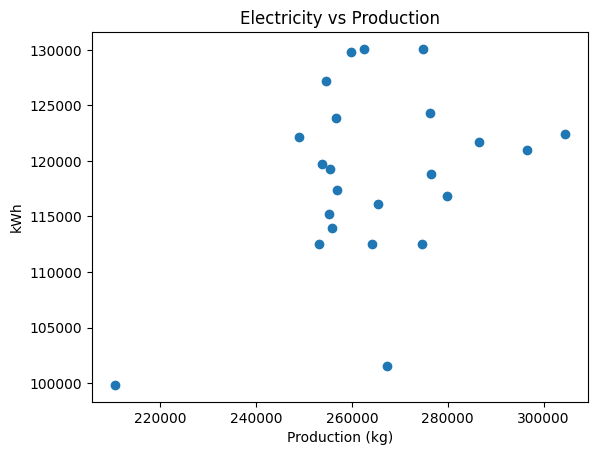

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(detail_backtest["production_kg"], detail_backtest["kwh_actual"])
plt.xlabel("Production (kg)")
plt.ylabel("kWh")
plt.title("Electricity vs Production")
plt.show()

In [ ]:
detail_backtest["demand_intensity"] = detail_backtest["kw_actual"] / detail_backtest["production_kg"]

In [ ]:
detail_backtest["demand_intensity"] = detail_backtest["kw_actual"] / detail_backtest["production_kg"]

In [ ]:
detail_backtest["production_per_day"] = (
    detail_backtest["production_kg"] /
    detail_backtest["days_actual"]
)

In [ ]:
detail_backtest.sort_values("production_per_day")

,start,end,days_actual,production_kg,summer,kwh_actual,kwh_pred,kwh_var,kw_actual,kw_pred,...,gst_actual_$,gst_pred_$,gst_var_$,total_actual_$,total_pred_$,total_var_$,total_var_%,kwh_per_kg,demand_intensity,production_per_day
2,2024-04-03,2024-05-01,29,210483.76,0,99840,103515.872670,-3675.872670,253.0,286.1875,...,470.897851,492.786263,-21.888412,9624.5600,10348.511522,-723.951522,-7.521918,0.474336,0.001202,7258.060690
4,2024-06-01,2024-07-02,32,254643.53,1,127200,128575.380143,-1375.380143,306.0,311.5714,...,601.325259,573.399177,27.926083,12410.4900,12041.382707,369.107293,2.974156,0.499522,0.001202,7957.610312
20,2025-09-27,2025-10-29,33,262631.86,0,130080,124281.474460,5798.525540,307.0,286.1875,...,633.724620,587.992513,45.732107,13809.4300,12347.842773,1461.587227,10.583979,0.495294,0.001169,7958.541212
22,2025-11-29,2025-12-30,32,256955.51,0,117360,120214.756678,-2854.756678,292.0,286.1875,...,581.846490,576.661860,5.184630,12218.7800,12109.899055,108.880945,0.891095,0.456733,0.001136,8029.859688
16,2025-05-31,2025-06-30,31,249002.29,0,122160,115800.141968,6359.858032,320.0,286.1875,...,616.363723,560.086069,56.277655,12943.6300,11761.807440,1181.822560,9.130534,0.490598,0.001285,8032.331935
8,2024-09-28,2024-10-30,33,276286.51,0,124320,126367.852157,-2047.852157,275.0,286.1875,...,572.190467,550.052785,22.137681,11801.2700,11551.108491,250.161509,2.119785,0.449968,0.000995,8372.318485
15,2025-05-01,2025-05-30,30,253152.78,0,112560,113234.927323,-674.927323,292.0,286.1875,...,554.938085,554.272871,0.665214,11653.6980,11639.730290,13.967710,0.119856,0.444633,0.001153,8438.426000
6,2024-07-31,2024-08-29,30,253762.96,1,119760,122042.045532,-2282.045532,317.0,311.5714,...,596.279541,553.776745,42.502796,12055.4400,11629.311644,426.128356,3.534739,0.471936,0.001249,8458.765333
11,2025-01-01,2025-01-30,30,255134.16,0,115200,113537.674522,1662.325478,271.0,286.1875,...,530.050276,512.468971,17.581305,10641.3090,10761.848387,-120.539387,-1.132750,0.451527,0.001062,8504.472000
18,2025-07-30,2025-08-28,30,259887.23,1,129840,122977.810296,6862.189704,325.0,311.5714,...,657.592257,599.769425,57.822833,13809.4300,12595.157918,1214.272082,8.793064,0.499601,0.001251,8662.907667


In [ ]:
detail_backtest["base_kwh"] = detail_backtest["days_actual"] * 2600
detail_backtest["production_kwh"] = detail_backtest["kwh_actual"] - detail_backtest["base_kwh"]

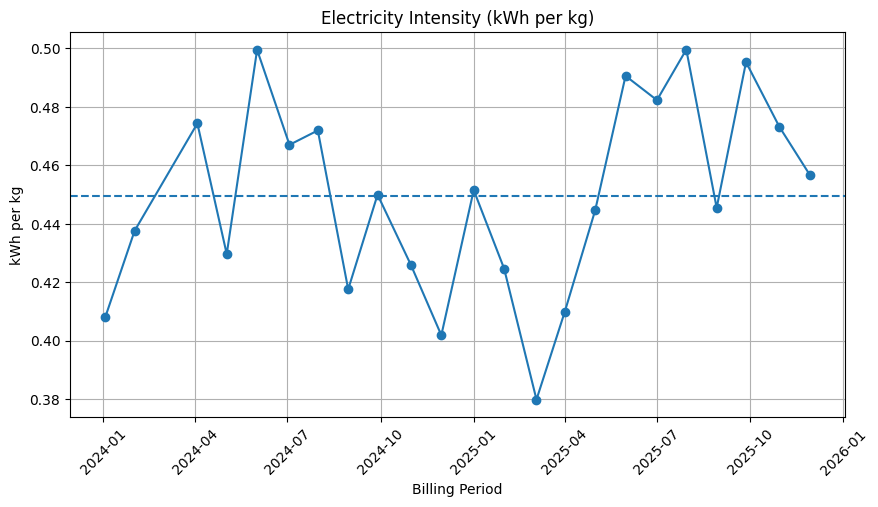

In [ ]:
import matplotlib.pyplot as plt

df = detail_backtest.copy()

df["kwh_per_kg"] = df["kwh_actual"] / df["production_kg"]

plt.figure(figsize=(10,5))
plt.plot(df["start"], df["kwh_per_kg"], marker="o")
plt.axhline(df["kwh_per_kg"].mean(), linestyle="--")

plt.title("Electricity Intensity (kWh per kg)")
plt.xlabel("Billing Period")
plt.ylabel("kWh per kg")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

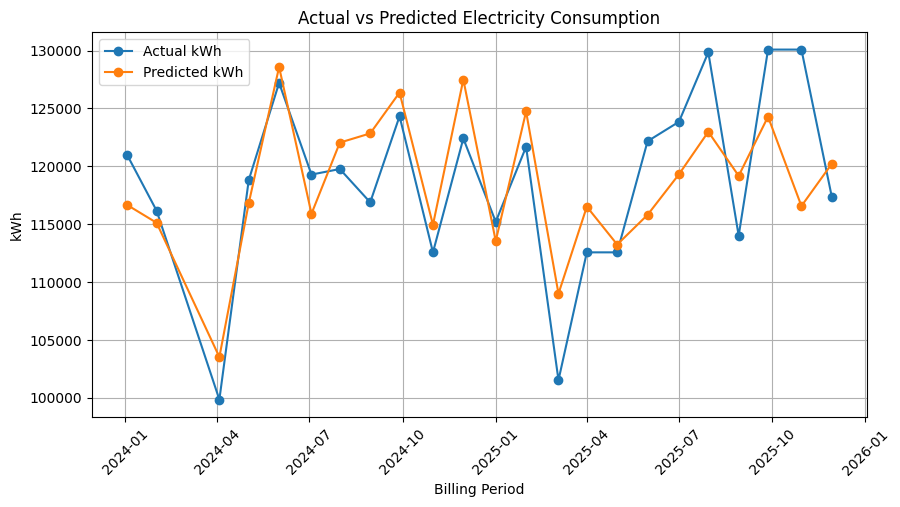

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["start"], df["kwh_actual"], label="Actual kWh", marker="o")
plt.plot(df["start"], df["kwh_pred"], label="Predicted kWh", marker="o")

plt.title("Actual vs Predicted Electricity Consumption")
plt.xlabel("Billing Period")
plt.ylabel("kWh")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

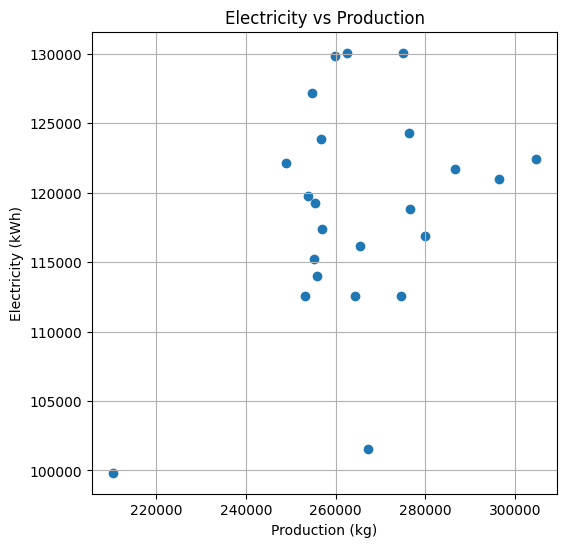

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(df["production_kg"], df["kwh_actual"])

plt.xlabel("Production (kg)")
plt.ylabel("Electricity (kWh)")
plt.title("Electricity vs Production")

plt.grid(True)
plt.show()

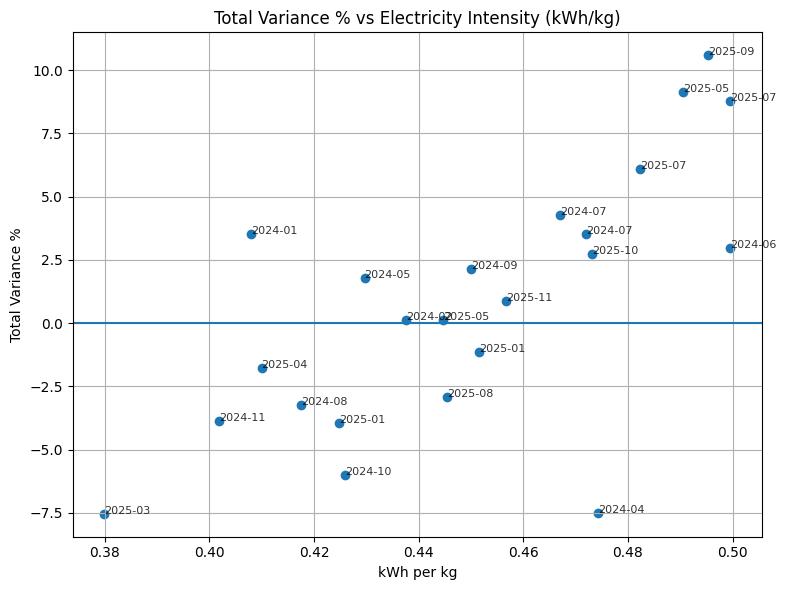

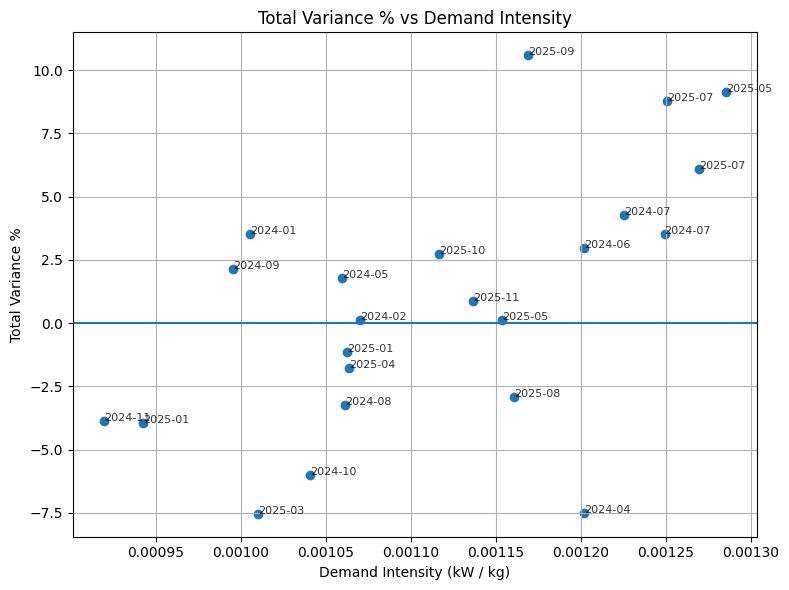

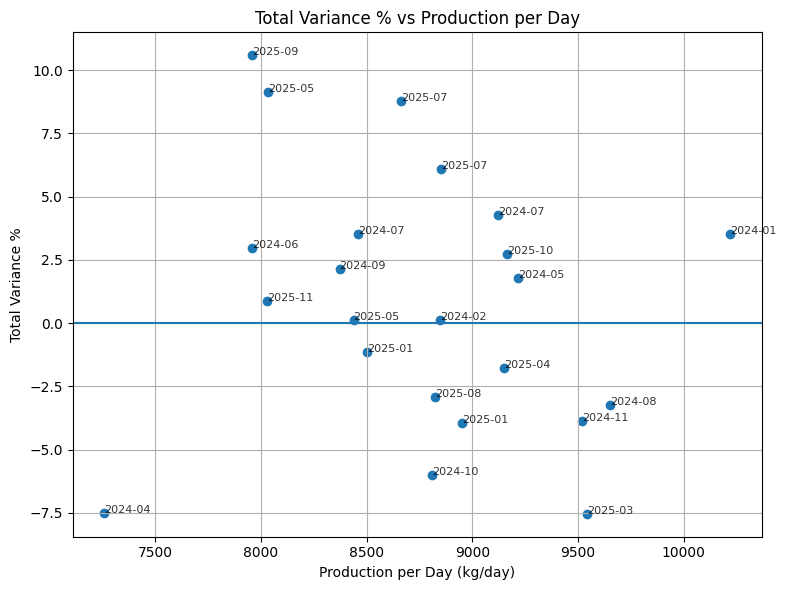

                    total_var_%  kwh_per_kg  demand_intensity  \
total_var_%            1.000000    0.699858          0.587268   
kwh_per_kg             0.699858    1.000000          0.824650   
demand_intensity       0.587268    0.824650          1.000000   
production_per_day    -0.185569   -0.709265         -0.547731   

                    production_per_day  
total_var_%                  -0.185569  
kwh_per_kg                   -0.709265  
demand_intensity             -0.547731  
production_per_day            1.000000  

Top 5 positive variance periods
        start        end  total_var_%  kwh_per_kg  demand_intensity  \
20 2025-09-27 2025-10-29    10.583979    0.495294          0.001169   
16 2025-05-31 2025-06-30     9.130534    0.490598          0.001285   
18 2025-07-30 2025-08-28     8.793064    0.499601          0.001251   
17 2025-07-01 2025-07-29     6.106375    0.482299          0.001270   
5  2024-07-03 2024-07-30     4.286512    0.467015          0.001225   

    produ

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = detail_backtest.copy()
df["start"] = pd.to_datetime(df["start"])

# -------------------------------------------------
# 1) Scatter: total variance % vs kWh per kg
# -------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["kwh_per_kg"], df["total_var_%"])

for _, row in df.iterrows():
    plt.annotate(
        row["start"].strftime("%Y-%m"),
        (row["kwh_per_kg"], row["total_var_%"]),
        fontsize=8,
        alpha=0.8
    )

plt.axhline(0)
plt.xlabel("kWh per kg")
plt.ylabel("Total Variance %")
plt.title("Total Variance % vs Electricity Intensity (kWh/kg)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 2) Scatter: total variance % vs demand intensity
# -------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["demand_intensity"], df["total_var_%"])

for _, row in df.iterrows():
    plt.annotate(
        row["start"].strftime("%Y-%m"),
        (row["demand_intensity"], row["total_var_%"]),
        fontsize=8,
        alpha=0.8
    )

plt.axhline(0)
plt.xlabel("Demand Intensity (kW / kg)")
plt.ylabel("Total Variance %")
plt.title("Total Variance % vs Demand Intensity")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3) Scatter: total variance % vs production per day
# -------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(df["production_per_day"], df["total_var_%"])

for _, row in df.iterrows():
    plt.annotate(
        row["start"].strftime("%Y-%m"),
        (row["production_per_day"], row["total_var_%"]),
        fontsize=8,
        alpha=0.8
    )

plt.axhline(0)
plt.xlabel("Production per Day (kg/day)")
plt.ylabel("Total Variance %")
plt.title("Total Variance % vs Production per Day")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4) Correlation check
# -------------------------------------------------
corr_cols = [
    "total_var_%",
    "kwh_per_kg",
    "demand_intensity",
    "production_per_day"
]

print(df[corr_cols].corr())

# -------------------------------------------------
# 5) Optional: top positive and negative variance rows
# -------------------------------------------------
print("\nTop 5 positive variance periods")
print(
    df.sort_values("total_var_%", ascending=False)[[
        "start", "end", "total_var_%", "kwh_per_kg",
        "demand_intensity", "production_per_day"
    ]].head(5)
)

print("\nTop 5 negative variance periods")
print(
    df.sort_values("total_var_%", ascending=True)[[
        "start", "end", "total_var_%", "kwh_per_kg",
        "demand_intensity", "production_per_day"
    ]].head(5)
)

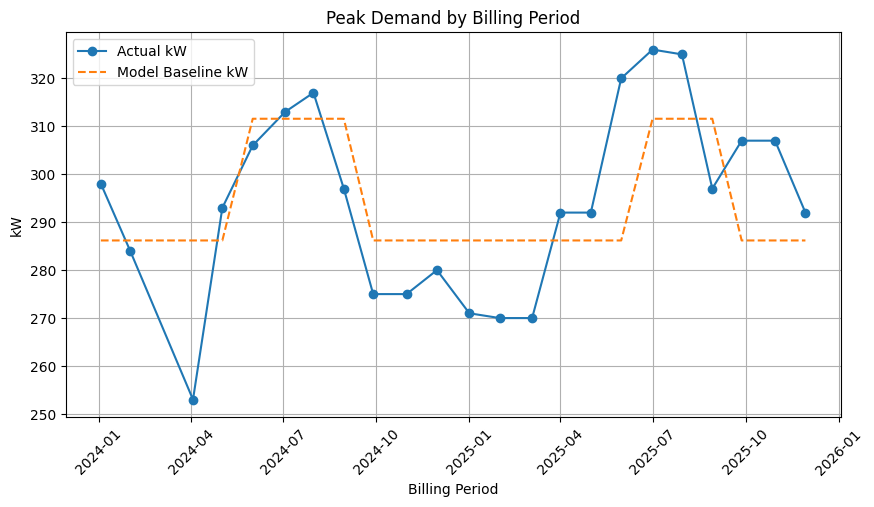

In [ ]:
import matplotlib.pyplot as plt

df = detail_backtest.copy()

plt.figure(figsize=(10,5))
plt.plot(df["start"], df["kw_actual"], marker="o", label="Actual kW")
plt.plot(df["start"], df["kw_pred"], linestyle="--", label="Model Baseline kW")

plt.title("Peak Demand by Billing Period")
plt.xlabel("Billing Period")
plt.ylabel("kW")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

In [ ]:
df = detail_backtest.copy()

DEMAND_RATE = df["demand_actual_$"].sum() / df["kw_actual"].sum()

df["kw_capped"] = df["kw_actual"].clip(upper=300)

df["demand_actual_$"] = df["kw_actual"] * DEMAND_RATE
df["demand_capped_$"] = df["kw_capped"] * DEMAND_RATE

df["demand_savings_$"] = df["demand_actual_$"] - df["demand_capped_$"]

print("Potential annual savings:", df["demand_savings_$"].sum())

Potential annual savings: 1623.18099112426


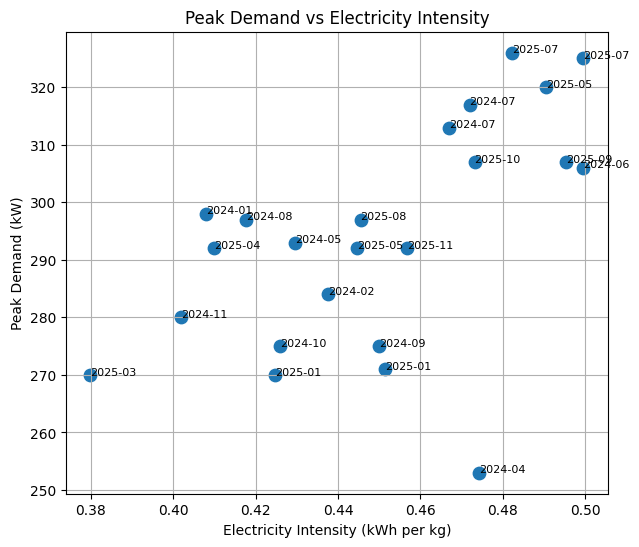

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    detail_backtest["kwh_per_kg"],
    detail_backtest["kw_actual"],
    s=80
)

plt.xlabel("Electricity Intensity (kWh per kg)")
plt.ylabel("Peak Demand (kW)")
plt.title("Peak Demand vs Electricity Intensity")

plt.grid(True)

for i,row in detail_backtest.iterrows():
    plt.text(row["kwh_per_kg"], row["kw_actual"], row["start"].strftime("%Y-%m"), fontsize=8)

plt.show()

2026 prediction

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# CONFIG
# =========================================================
QTY_2026_FILE = "/content/Quantity 2026.xlsx"
QTY_2026_SHEET = "Powell (Monthly)"
OUTPUT_FILE = "/content/powell_2026_electricity_forecast.xlsx"

# =========================================================
# MODEL COEFFICIENTS
# =========================================================
B0 = -21430
B_DAYS = 3199.3935
B_PROD = 0.1528
B_SUMMER = 8713.8851

KW_BASE = 286.1875
KW_SUMMER_UPLIFT = 25.3839

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

# =========================================================
# 1) CHECK SHEETS
# =========================================================
xls = pd.ExcelFile(QTY_2026_FILE)
print("=== SHEET NAMES ===")
print(xls.sheet_names)

# =========================================================
# 2) READ POWELL (MONTHLY) RAW
# =========================================================
raw = pd.read_excel(QTY_2026_FILE, sheet_name=QTY_2026_SHEET, header=None)
raw_str = raw.fillna("").astype(str).apply(lambda col: col.map(lambda x: x.replace("\n", " ").strip()))

print("\n=== TOP 15 RAW ROWS ===")
print(raw_str.head(15).to_string())

# =========================================================
# 3) FIND HEADER ROW CONTAINING JAN KG / FEB KG
# =========================================================
header_row = None
for i in range(len(raw_str)):
    row_vals = raw_str.iloc[i].tolist()
    row_text = " | ".join(row_vals)
    if "JAN KG" in row_text and "FEB KG" in row_text:
        header_row = i
        break

if header_row is None:
    raise ValueError("Could not find monthly header row with JAN KG / FEB KG in Powell (Monthly).")

print(f"\nDetected header row: {header_row}")

# =========================================================
# 4) RE-READ USING TRUE HEADER ROW
# =========================================================
q26 = pd.read_excel(QTY_2026_FILE, sheet_name=QTY_2026_SHEET, header=header_row)
q26 = normalize_cols(q26)

print("\n=== MONTHLY SHEET COLUMNS ===")
print(q26.columns.tolist())

# =========================================================
# 5) FIND GRAND TOTAL (INCLUDES CONCENTRATE) ROW
# =========================================================
row_mask = q26.astype(str).apply(
    lambda r: r.str.contains("Grand Total", case=False, na=False).any(),
    axis=1
)

if row_mask.sum() == 0:
    raise ValueError("Could not find row containing 'Grand Total (Includes Concentrate)'.")

grand_row = q26.loc[row_mask].iloc[0]

print("\n=== MATCHED GRAND TOTAL ROW ===")
print(grand_row)

# =========================================================
# 6) EXTRACT ONLY JAN KG, FEB KG, ... DEC KG
# =========================================================
months = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
kg_cols = [f"{m} KG" for m in months]

missing = [c for c in kg_cols if c not in q26.columns]
if missing:
    raise ValueError(f"Missing expected monthly KG columns: {missing}")

prod_2026 = pd.DataFrame({
    "month": months,
    "production_kg": [pd.to_numeric(grand_row[c], errors="coerce") for c in kg_cols]
})

print("\n=== EXTRACTED 2026 PRODUCTION KG ===")
print(prod_2026)

if prod_2026["production_kg"].isna().any():
    raise ValueError("Some production KG values are blank/non-numeric.")

# =========================================================
# 7) ADD DAYS / SUMMER
# =========================================================
month_map = {
    "JAN": 1, "FEB": 2, "MAR": 3, "APR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AUG": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12
}

prod_2026["month_num"] = prod_2026["month"].map(month_map)
prod_2026["date"] = pd.to_datetime(dict(year=2026, month=prod_2026["month_num"], day=1))
prod_2026["days"] = prod_2026["date"].dt.days_in_month
prod_2026["summer"] = prod_2026["month_num"].isin([6, 7, 8]).astype(int)

# =========================================================
# 8) PREDICT KWH / KW
# =========================================================
prod_2026["kwh_pred"] = (
    B0
    + B_DAYS * prod_2026["days"]
    + B_PROD * prod_2026["production_kg"]
    + B_SUMMER * prod_2026["summer"]
).clip(lower=0)

prod_2026["kw_pred"] = KW_BASE + KW_SUMMER_UPLIFT * prod_2026["summer"]

# =========================================================
# 9) USE HISTORICAL RATES FROM detail_backtest
# detail_backtest must already exist
# =========================================================
energy_rate = pd.to_numeric(detail_backtest["energy_rate_actual"], errors="coerce").median()
demand_rate = pd.to_numeric(detail_backtest["demand_rate_actual"], errors="coerce").median()
basic_per_day = (
    pd.to_numeric(detail_backtest["basic_actual_$"], errors="coerce") /
    pd.to_numeric(detail_backtest["days_actual"], errors="coerce")
).median()

rate_rider_monthly = pd.to_numeric(detail_backtest["rate_rider_actual_$"], errors="coerce").median()
trade_adj_monthly = pd.to_numeric(detail_backtest["trade_adj_actual_$"], errors="coerce").median()
credit_monthly = pd.to_numeric(detail_backtest["credit_actual_$"], errors="coerce").median()
transformer_monthly = pd.to_numeric(detail_backtest["transformer_actual_$"], errors="coerce").median()

print("\n=== RATE ASSUMPTIONS ===")
print(f"Energy rate ($/kWh): {energy_rate:.6f}")
print(f"Demand rate ($/kW): {demand_rate:.6f}")
print(f"Basic rate ($/day): {basic_per_day:.6f}")
print(f"Rate rider monthly: {rate_rider_monthly:.2f}")
print(f"Trade adj monthly : {trade_adj_monthly:.2f}")
print(f"Credit monthly    : {credit_monthly:.2f}")
print(f"Transformer monthly: {transformer_monthly:.2f}")

# =========================================================
# 10) BUILD 2026 BILL FORECAST
# =========================================================
prod_2026["basic_$"] = prod_2026["days"] * basic_per_day
prod_2026["energy_$"] = prod_2026["kwh_pred"] * energy_rate
prod_2026["demand_$"] = prod_2026["kw_pred"] * demand_rate
prod_2026["transformer_$"] = transformer_monthly
prod_2026["rate_rider_$"] = rate_rider_monthly
prod_2026["trade_adj_$"] = trade_adj_monthly
prod_2026["credit_$"] = credit_monthly

prod_2026["pretax_$"] = (
    prod_2026["basic_$"]
    + prod_2026["energy_$"]
    + prod_2026["demand_$"]
    + prod_2026["transformer_$"]
    + prod_2026["rate_rider_$"]
    + prod_2026["trade_adj_$"]
    + prod_2026["credit_$"]
)

prod_2026["gst_$"] = prod_2026["pretax_$"] * 0.05
prod_2026["total_$"] = prod_2026["pretax_$"] + prod_2026["gst_$"]

forecast_2026 = prod_2026[[
    "month",
    "production_kg",
    "days",
    "summer",
    "kwh_pred",
    "kw_pred",
    "basic_$",
    "energy_$",
    "demand_$",
    "transformer_$",
    "rate_rider_$",
    "trade_adj_$",
    "credit_$",
    "pretax_$",
    "gst_$",
    "total_$"
]].copy()

print("\n=== 2026 POWELL ELECTRICITY FORECAST ===")
print(forecast_2026)

print("\n=== 2026 ANNUAL TOTALS ===")
print(forecast_2026[[
    "production_kg",
    "kwh_pred",
    "pretax_$",
    "gst_$",
    "total_$"
]].sum())

# =========================================================
# 11) EXPORT
# =========================================================
forecast_2026.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== SHEET NAMES ===
['Powell (Weekly)', 'Powell (Monthly)']

=== TOP 15 RAW ROWS ===
   0  1               2                                              3        4                           5               6                7       8        9                   10                  11                  12                  13                  14                  15                  16                  17                 18                 19                  20                  21                  22                  23                  24                  25                  26                  27                  28                  29                  30                  31                  32                  33                  34                  35                          36       37
0                                                                                                                                                                                                        

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
POWELL_UTIL_FILE = "/content/Powell Utilities.xlsx"
POWELL_UTIL_SHEET = "Electricity"

QTY_2024_FILE = "/content/Quantity 2024.xlsx"
QTY_2025_FILE = "/content/Quantity 2025.xlsx"
ITEM_LEDGER_SHEET = "Item Ledger Entries"

OUTPUT_FILE = "/content/powell_backtest_kwh_kw_rebuilt.xlsx"

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried {candidates}\nAvailable: {list(df.columns)}")

def in_date_range(df, date_col, start_date, end_date):
    return df[(df[date_col] >= start_date) & (df[date_col] <= end_date)]

def detect_header_row(filepath, sheet_name, required_text="Posting Date", max_rows=20):
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    raw_str = raw.fillna("").astype(str)

    for i in range(min(max_rows, len(raw_str))):
        row_text = " | ".join(raw_str.iloc[i].tolist())
        if required_text.lower() in row_text.lower():
            return i

    raise ValueError(f"Could not detect header row containing '{required_text}' in {filepath} / {sheet_name}")

# =========================================================
# 1) LOAD ELECTRICITY BILL
# =========================================================
bill = pd.read_excel(POWELL_UTIL_FILE, sheet_name=POWELL_UTIL_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col = pick_first_col(bill, ["End Date"], "End Date")
days_col = pick_first_col(bill, ["Days"], "Days")
basic_col = pick_first_col(bill, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col = pick_first_col(bill, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
kw_col = pick_first_col(bill, ["Demand Registered"], "Demand Registered")
total_col = pick_first_col(bill, ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"], "Total Due")

all_cols = list(bill.columns)
subtotal_cols = [c for c in all_cols if "subtotal" in c.lower()]

kwh_idx = all_cols.index(kwh_col)
energy_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break
if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

kw_idx = all_cols.index(kw_col)
demand_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break
if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

gst_col = next((c for c in all_cols if "gst" in c.lower()), None)
transformer_col = next((c for c in all_cols if "transformer" in c.lower()), None)
rate_rider_col = next((c for c in all_cols if "deferral rate rider" in c.lower()), None)
trade_adj_col = next((c for c in all_cols if "trade income rate rider" in c.lower()), None)
credit_col = next((c for c in all_cols if "credit" in c.lower()), None)

bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col] = pd.to_datetime(bill[end_col], errors="coerce")

num_cols = [
    days_col, basic_col, kwh_col, kw_col,
    energy_subtotal_col, demand_subtotal_col,
    gst_col, transformer_col, rate_rider_col,
    trade_adj_col, credit_col, total_col
]
for c in num_cols:
    if c is not None and c in bill.columns:
        bill[c] = to_num(bill[c])

# remove 2-day transition bill
bill = bill[
    ~(
        (bill[start_col] == pd.Timestamp("2024-04-01")) &
        (bill[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

bill = bill.dropna(subset=[start_col, end_col, total_col]).copy()
bill = bill.sort_values(start_col).reset_index(drop=True)

print("=== BILL DATA PREVIEW ===")
print(bill[[start_col, end_col, days_col, kwh_col, kw_col, total_col]].head())

# =========================================================
# 2) LOAD 2024 ITEM LEDGER
# =========================================================
ledger_2024 = pd.read_excel(QTY_2024_FILE, sheet_name=ITEM_LEDGER_SHEET)
ledger_2024 = normalize_cols(ledger_2024)
ledger_2024.columns = make_unique_columns(ledger_2024.columns)

print("\n=== 2024 ITEM LEDGER COLUMNS ===")
print(ledger_2024.columns.tolist())

posting_date_2024 = pick_first_col(ledger_2024, ["Posting Date"], "Posting Date")
weight_col_2024 = pick_first_col(ledger_2024, ["2. Total Weight (kg)"], "2. Total Weight (kg)")
only_12022_col_2024 = pick_first_col(ledger_2024, ["12022 only"], "12022 only")

ledger_2024[posting_date_2024] = pd.to_datetime(ledger_2024[posting_date_2024], errors="coerce")
ledger_2024[weight_col_2024] = to_num(ledger_2024[weight_col_2024]).fillna(0)
ledger_2024[only_12022_col_2024] = to_num(ledger_2024[only_12022_col_2024]).fillna(0)
ledger_2024 = ledger_2024.dropna(subset=[posting_date_2024]).copy()

# =========================================================
# 3) LOAD 2025 ITEM LEDGER WITH HEADER DETECTION
# =========================================================
header_row_2025 = detect_header_row(QTY_2025_FILE, ITEM_LEDGER_SHEET, required_text="Posting Date", max_rows=20)
print(f"\nDetected 2025 header row: {header_row_2025}")

ledger_2025 = pd.read_excel(QTY_2025_FILE, sheet_name=ITEM_LEDGER_SHEET, header=header_row_2025)
ledger_2025 = normalize_cols(ledger_2025)
ledger_2025.columns = make_unique_columns(ledger_2025.columns)

print("\n=== 2025 ITEM LEDGER COLUMNS ===")
print(ledger_2025.columns.tolist())

posting_date_2025 = pick_first_col(ledger_2025, ["Posting Date"], "Posting Date")
weight_col_2025 = pick_first_col(ledger_2025, ["2. Total Weight (kg)"], "2. Total Weight (kg)")
only_12022_col_2025 = pick_first_col(ledger_2025, ["12022 only"], "12022 only")

ledger_2025[posting_date_2025] = pd.to_datetime(ledger_2025[posting_date_2025], errors="coerce")
ledger_2025[weight_col_2025] = to_num(ledger_2025[weight_col_2025]).fillna(0)
ledger_2025[only_12022_col_2025] = to_num(ledger_2025[only_12022_col_2025]).fillna(0)
ledger_2025 = ledger_2025.dropna(subset=[posting_date_2025]).copy()

# =========================================================
# 4) REBUILD PRODUCTION BY BILL DATE RANGE
# production_kg = sum(2. Total Weight (kg)) + sum(12022 only)
# =========================================================
rows = []

for _, r in bill.iterrows():
    start = r[start_col]
    end = r[end_col]
    days = r[days_col]
    kwh_actual = r[kwh_col]
    kw_actual = r[kw_col]
    year = start.year

    if year == 2024:
        led = in_date_range(ledger_2024, posting_date_2024, start, end)
        production_kg = led[weight_col_2024].sum() + led[only_12022_col_2024].sum()
    elif year == 2025:
        led = in_date_range(ledger_2025, posting_date_2025, start, end)
        production_kg = led[weight_col_2025].sum() + led[only_12022_col_2025].sum()
    else:
        continue

    rows.append({
        "start": start,
        "end": end,
        "days": days,
        "kwh": kwh_actual,
        "kw_actual": kw_actual,
        "production_kg": production_kg
    })

bt = pd.DataFrame(rows).sort_values("start").reset_index(drop=True)
bt["month"] = bt["start"].dt.month
bt["summer"] = bt["month"].isin([5, 6, 7, 8]).astype(int)

print("\n=== REBUILT MODEL DATASET ===")
print(bt)

# =========================================================
# 5) FIT KWH REGRESSION
# =========================================================
X_kwh = bt[["days", "production_kg", "summer"]]
X_kwh = sm.add_constant(X_kwh)
y_kwh = bt["kwh"]

model_kwh = sm.OLS(y_kwh, X_kwh).fit()
bt["kwh_pred"] = model_kwh.predict(X_kwh)

print("\n=== IMPROVED KWH MODEL ===")
print(model_kwh.summary())

# =========================================================
# 6) RECALCULATE KW SEASONAL MODEL
# =========================================================
KW_BASE = bt.loc[bt["summer"] == 0, "kw_actual"].mean()
KW_SUMMER_AVG = bt.loc[bt["summer"] == 1, "kw_actual"].mean()
KW_SUMMER_UPLIFT = KW_SUMMER_AVG - KW_BASE

bt["kw_pred"] = KW_BASE + KW_SUMMER_UPLIFT * bt["summer"]

print("\n=== RECALCULATED KW SEASONAL MODEL ===")
print(f"Non-summer avg kW : {KW_BASE:.4f}")
print(f"Summer avg kW     : {KW_SUMMER_AVG:.4f}")
print(f"Summer uplift kW  : {KW_SUMMER_UPLIFT:.4f}")

# =========================================================
# 7) MERGE MODEL DATA TO BILL
# =========================================================
detail = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="inner"
)

# =========================================================
# 8) ACTUAL BILL COLUMNS
# =========================================================
detail["days_actual"] = to_num(detail[days_col]).fillna(0)
detail["kwh_actual"] = to_num(detail[kwh_col]).fillna(0)
detail["kw_actual"] = to_num(detail[kw_col]).fillna(0)

detail["basic_actual_$"] = to_num(detail[basic_col]).fillna(0)
detail["energy_actual_$"] = to_num(detail[energy_subtotal_col]).fillna(0)
detail["demand_actual_$"] = to_num(detail[demand_subtotal_col]).fillna(0)

detail["transformer_actual_$"] = to_num(detail[transformer_col]).fillna(0) if transformer_col else 0
detail["rate_rider_actual_$"] = to_num(detail[rate_rider_col]).fillna(0) if rate_rider_col else 0
detail["trade_adj_actual_$"] = to_num(detail[trade_adj_col]).fillna(0) if trade_adj_col else 0
detail["credit_actual_$"] = to_num(detail[credit_col]).fillna(0) if credit_col else 0
detail["gst_actual_$"] = to_num(detail[gst_col]).fillna(0) if gst_col else 0
detail["total_actual_$"] = to_num(detail[total_col]).fillna(0)

detail["energy_rate_actual"] = np.where(
    detail["kwh_actual"] != 0,
    detail["energy_actual_$"] / detail["kwh_actual"],
    np.nan
)

detail["demand_rate_actual"] = np.where(
    detail["kw_actual"] != 0,
    detail["demand_actual_$"] / detail["kw_actual"],
    np.nan
)

# =========================================================
# 9) PREDICTED BILL COLUMNS
# =========================================================
detail["basic_pred_$"] = detail["basic_actual_$"]
detail["energy_pred_$"] = detail["kwh_pred"] * detail["energy_rate_actual"]
detail["demand_pred_$"] = detail["kw_pred"] * detail["demand_rate_actual"]

detail["transformer_pred_$"] = detail["transformer_actual_$"]
detail["rate_rider_pred_$"] = detail["rate_rider_actual_$"]
detail["trade_adj_pred_$"] = detail["trade_adj_actual_$"]
detail["credit_pred_$"] = detail["credit_actual_$"]

detail["pretax_actual_$"] = (
    detail["basic_actual_$"] +
    detail["energy_actual_$"] +
    detail["demand_actual_$"] +
    detail["transformer_actual_$"] +
    detail["rate_rider_actual_$"] +
    detail["trade_adj_actual_$"] +
    detail["credit_actual_$"]
)

detail["pretax_pred_$"] = (
    detail["basic_pred_$"] +
    detail["energy_pred_$"] +
    detail["demand_pred_$"] +
    detail["transformer_pred_$"] +
    detail["rate_rider_pred_$"] +
    detail["trade_adj_pred_$"] +
    detail["credit_pred_$"]
)

detail["gst_pred_$"] = detail["pretax_pred_$"] * 0.05
detail["total_pred_$"] = detail["pretax_pred_$"] + detail["gst_pred_$"]

# =========================================================
# 10) VARIANCES
# =========================================================
detail["kwh_var"] = detail["kwh_actual"] - detail["kwh_pred"]
detail["kw_var"] = detail["kw_actual"] - detail["kw_pred"]

detail["basic_var_$"] = detail["basic_actual_$"] - detail["basic_pred_$"]
detail["energy_var_$"] = detail["energy_actual_$"] - detail["energy_pred_$"]
detail["demand_var_$"] = detail["demand_actual_$"] - detail["demand_pred_$"]
detail["transformer_var_$"] = detail["transformer_actual_$"] - detail["transformer_pred_$"]
detail["rate_rider_var_$"] = detail["rate_rider_actual_$"] - detail["rate_rider_pred_$"]
detail["trade_adj_var_$"] = detail["trade_adj_actual_$"] - detail["trade_adj_pred_$"]
detail["credit_var_$"] = detail["credit_actual_$"] - detail["credit_pred_$"]
detail["pretax_var_$"] = detail["pretax_actual_$"] - detail["pretax_pred_$"]
detail["gst_var_$"] = detail["gst_actual_$"] - detail["gst_pred_$"]
detail["total_var_$"] = detail["total_actual_$"] - detail["total_pred_$"]
detail["total_var_%"] = np.where(
    detail["total_actual_$"] != 0,
    detail["total_var_$"] / detail["total_actual_$"] * 100,
    np.nan
)

# =========================================================
# 11) FINAL BACKTEST TABLE
# =========================================================
detail_backtest = detail[[
    "start",
    "end",
    "days_actual",
    "production_kg",
    "summer",
    "kwh_actual",
    "kwh_pred",
    "kwh_var",
    "kw_actual",
    "kw_pred",
    "kw_var",
    "energy_rate_actual",
    "demand_rate_actual",
    "basic_actual_$",
    "basic_pred_$",
    "basic_var_$",
    "energy_actual_$",
    "energy_pred_$",
    "energy_var_$",
    "demand_actual_$",
    "demand_pred_$",
    "demand_var_$",
    "transformer_actual_$",
    "transformer_pred_$",
    "transformer_var_$",
    "rate_rider_actual_$",
    "rate_rider_pred_$",
    "rate_rider_var_$",
    "trade_adj_actual_$",
    "trade_adj_pred_$",
    "trade_adj_var_$",
    "credit_actual_$",
    "credit_pred_$",
    "credit_var_$",
    "pretax_actual_$",
    "pretax_pred_$",
    "pretax_var_$",
    "gst_actual_$",
    "gst_pred_$",
    "gst_var_$",
    "total_actual_$",
    "total_pred_$",
    "total_var_$",
    "total_var_%"
]].copy()

detail_backtest = detail_backtest.sort_values("start").reset_index(drop=True)

# =========================================================
# 12) SUMMARY
# =========================================================
mae_total = detail_backtest["total_var_$"].abs().mean()
rmse_total = np.sqrt((detail_backtest["total_var_$"] ** 2).mean())
wape_total = detail_backtest["total_var_$"].abs().sum() / detail_backtest["total_actual_$"].sum() * 100

mae_energy = detail_backtest["energy_var_$"].abs().mean()
mae_demand = detail_backtest["demand_var_$"].abs().mean()

print("\n=== BACKTEST SUMMARY ===")
print(f"Total MAE $   : {mae_total:,.2f}")
print(f"Total RMSE $  : {rmse_total:,.2f}")
print(f"Total WAPE %  : {wape_total:.2f}%")
print(f"Energy MAE $  : {mae_energy:,.2f}")
print(f"Demand MAE $  : {mae_demand:,.2f}")

print("\n=== DETAIL BACKTEST TABLE ===")
print(detail_backtest)

# =========================================================
# 13) EXPORT
# =========================================================
detail_backtest.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== BILL DATA PREVIEW ===
  Start Date   End Date  Days  Energy Used  Demand Registered  Total Due
0 2024-01-03 2024-01-31    29       120960           298.0000   11600.60
1 2024-02-01 2024-03-01    30       116160           284.0000   11112.61
2 2024-03-02 2024-03-31    30       108000           269.0624   11122.40
3 2024-04-03 2024-05-01    29        99840           253.0000    9624.56
4 2024-05-02 2024-05-31    30       118800           293.0000   11145.11

=== 2024 ITEM LEDGER COLUMNS ===
['Week #', 'Posting Date', 'Entry Type', 'Document No.', 'Item No.', 'Description', 'Phy. Location Code', 'Lot No.', 'Location Code', 'Quantity', 'Unit of Measure Code', 'Column1', '3. FG  (in cases in LTR)', '3. FG weight per unit (kg and ltr)', '3. FG Total Weight (kg and Ltr)', 'FG cases', 'FG Total Weight', '2. WIP Tray (in trays)', '2. WIP Tray weight / unit', '2. Total Weight (kg)', '1. Extract (Ltr)', '12022 only', 'Tray in KG & 12022 Ltrs']

Detected 2025 header row: 2

=== 2025 ITEM LEDGE

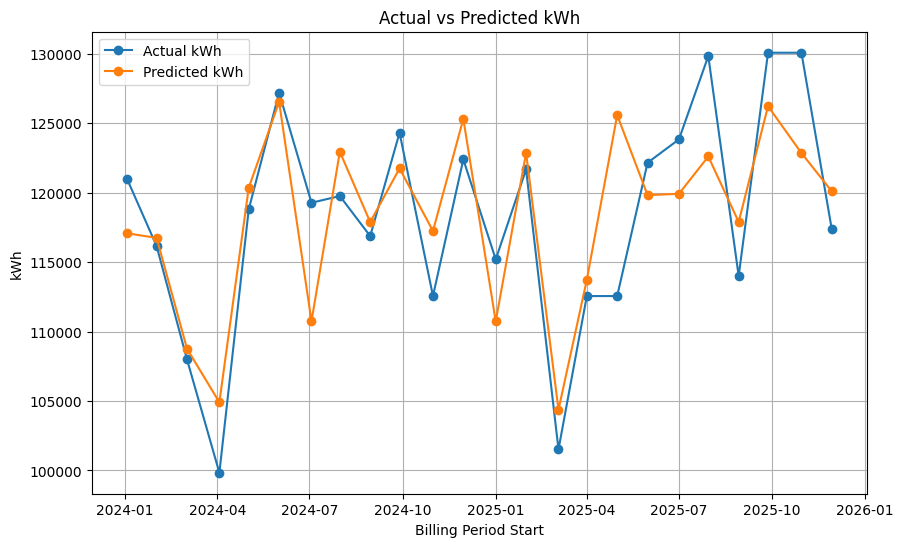

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(detail_backtest["start"], detail_backtest["kwh_actual"], marker='o', label="Actual kWh")
plt.plot(detail_backtest["start"], detail_backtest["kwh_pred"], marker='o', label="Predicted kWh")

plt.title("Actual vs Predicted kWh")
plt.xlabel("Billing Period Start")
plt.ylabel("kWh")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
POWELL_UTIL_FILE = "/content/Powell Utilities.xlsx"
POWELL_UTIL_SHEET = "Electricity"

QTY_2024_FILE = "/content/Quantity 2024.xlsx"
QTY_2025_FILE = "/content/Quantity 2025.xlsx"
ITEM_LEDGER_SHEET = "Item Ledger Entries"

OUTPUT_FILE = "/content/powell_backtest_with_second_processing.xlsx"

# define summer months
SUMMER_MONTHS = [5, 6, 7, 8]

# second processing keywords
SECOND_PROCESS_KEYWORDS = [
    "2nd processing",
    "fried tofu",
    "puff",
    "marinated tofu",
    "flav. dried tofu",
    "dried tofu",
    "smoked tofu"
]

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried {candidates}\nAvailable: {list(df.columns)}")

def in_date_range(df, date_col, start_date, end_date):
    return df[(df[date_col] >= start_date) & (df[date_col] <= end_date)]

def detect_header_row(filepath, sheet_name, required_text="Posting Date", max_rows=25):
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    raw_str = raw.fillna("").astype(str)

    for i in range(min(max_rows, len(raw_str))):
        row_text = " | ".join(raw_str.iloc[i].tolist())
        if required_text.lower() in row_text.lower():
            return i

    raise ValueError(f"Could not detect header row containing '{required_text}' in {filepath} / {sheet_name}")

# =========================================================
# 1) LOAD ELECTRICITY BILL
# =========================================================
bill = pd.read_excel(POWELL_UTIL_FILE, sheet_name=POWELL_UTIL_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col = pick_first_col(bill, ["End Date"], "End Date")
days_col = pick_first_col(bill, ["Days"], "Days")
basic_col = pick_first_col(bill, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col = pick_first_col(bill, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
kw_col = pick_first_col(bill, ["Demand Registered"], "Demand Registered")
total_col = pick_first_col(bill, ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"], "Total Due")

all_cols = list(bill.columns)
subtotal_cols = [c for c in all_cols if "subtotal" in c.lower()]

# energy subtotal
kwh_idx = all_cols.index(kwh_col)
energy_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break
if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

# demand subtotal
kw_idx = all_cols.index(kw_col)
demand_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break
if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

gst_col = next((c for c in all_cols if "gst" in c.lower()), None)
transformer_col = next((c for c in all_cols if "transformer" in c.lower()), None)
rate_rider_col = next((c for c in all_cols if "deferral rate rider" in c.lower()), None)
trade_adj_col = next((c for c in all_cols if "trade income rate rider" in c.lower()), None)
credit_col = next((c for c in all_cols if "credit" in c.lower()), None)

bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col] = pd.to_datetime(bill[end_col], errors="coerce")

num_cols = [
    days_col, basic_col, kwh_col, kw_col,
    energy_subtotal_col, demand_subtotal_col,
    gst_col, transformer_col, rate_rider_col,
    trade_adj_col, credit_col, total_col
]
for c in num_cols:
    if c is not None and c in bill.columns:
        bill[c] = to_num(bill[c])

# remove 2-day transition bill
bill = bill[
    ~(
        (bill[start_col] == pd.Timestamp("2024-04-01")) &
        (bill[end_col] == pd.Timestamp("2024-04-02"))
    )
].copy()

bill = bill.dropna(subset=[start_col, end_col, total_col]).copy()
bill = bill.sort_values(start_col).reset_index(drop=True)

print("=== BILL DATA PREVIEW ===")
print(bill[[start_col, end_col, days_col, kwh_col, kw_col, total_col]].head())

# =========================================================
# 2) LOAD 2024 ITEM LEDGER
# =========================================================
ledger_2024 = pd.read_excel(QTY_2024_FILE, sheet_name=ITEM_LEDGER_SHEET)
ledger_2024 = normalize_cols(ledger_2024)
ledger_2024.columns = make_unique_columns(ledger_2024.columns)

print("\n=== 2024 ITEM LEDGER COLUMNS ===")
print(ledger_2024.columns.tolist())

posting_date_2024 = pick_first_col(ledger_2024, ["Posting Date"], "Posting Date")
desc_col_2024 = pick_first_col(ledger_2024, ["Description"], "Description")
weight_col_2024 = pick_first_col(ledger_2024, ["2. Total Weight (kg)"], "2. Total Weight (kg)")
only_12022_col_2024 = pick_first_col(ledger_2024, ["12022 only"], "12022 only")

ledger_2024[posting_date_2024] = pd.to_datetime(ledger_2024[posting_date_2024], errors="coerce")
ledger_2024[desc_col_2024] = ledger_2024[desc_col_2024].astype(str).str.lower().str.strip()
ledger_2024[weight_col_2024] = to_num(ledger_2024[weight_col_2024]).fillna(0)
ledger_2024[only_12022_col_2024] = to_num(ledger_2024[only_12022_col_2024]).fillna(0)
ledger_2024 = ledger_2024.dropna(subset=[posting_date_2024]).copy()

# =========================================================
# 3) LOAD 2025 ITEM LEDGER WITH HEADER DETECTION
# =========================================================
header_row_2025 = detect_header_row(QTY_2025_FILE, ITEM_LEDGER_SHEET, required_text="Posting Date", max_rows=25)
print(f"\nDetected 2025 header row: {header_row_2025}")

ledger_2025 = pd.read_excel(QTY_2025_FILE, sheet_name=ITEM_LEDGER_SHEET, header=header_row_2025)
ledger_2025 = normalize_cols(ledger_2025)
ledger_2025.columns = make_unique_columns(ledger_2025.columns)

print("\n=== 2025 ITEM LEDGER COLUMNS ===")
print(ledger_2025.columns.tolist())

posting_date_2025 = pick_first_col(ledger_2025, ["Posting Date"], "Posting Date")
desc_col_2025 = pick_first_col(ledger_2025, ["Description"], "Description")
weight_col_2025 = pick_first_col(ledger_2025, ["2. Total Weight (kg)"], "2. Total Weight (kg)")
only_12022_col_2025 = pick_first_col(ledger_2025, ["12022 only"], "12022 only")

ledger_2025[posting_date_2025] = pd.to_datetime(ledger_2025[posting_date_2025], errors="coerce")
ledger_2025[desc_col_2025] = ledger_2025[desc_col_2025].astype(str).str.lower().str.strip()
ledger_2025[weight_col_2025] = to_num(ledger_2025[weight_col_2025]).fillna(0)
ledger_2025[only_12022_col_2025] = to_num(ledger_2025[only_12022_col_2025]).fillna(0)
ledger_2025 = ledger_2025.dropna(subset=[posting_date_2025]).copy()

# =========================================================
# 4) REBUILD PRODUCTION + SECOND PROCESSING BY BILL PERIOD
# production_kg = sum(2. Total Weight (kg)) + sum(12022 only)
# second_processing_kg = rows whose description matches keywords
# =========================================================
rows = []

for _, r in bill.iterrows():
    start = r[start_col]
    end = r[end_col]
    days = r[days_col]
    kwh_actual = r[kwh_col]
    kw_actual = r[kw_col]
    year = start.year

    if year == 2024:
        led = in_date_range(ledger_2024, posting_date_2024, start, end).copy()
        desc_col = desc_col_2024
        weight_col = weight_col_2024
        only_12022_col = only_12022_col_2024
    elif year == 2025:
        led = in_date_range(ledger_2025, posting_date_2025, start, end).copy()
        desc_col = desc_col_2025
        weight_col = weight_col_2025
        only_12022_col = only_12022_col_2025
    else:
        continue

    # total production basis
    production_kg = led[weight_col].sum() + led[only_12022_col].sum()

    # second processing classification from description
    desc = led[desc_col].fillna("").astype(str).str.lower()

    second_mask = pd.Series(False, index=led.index)
    for kw in SECOND_PROCESS_KEYWORDS:
        second_mask = second_mask | desc.str.contains(kw, na=False)

    second_processing_kg = led.loc[second_mask, weight_col].sum()
    primary_kg = production_kg - second_processing_kg

    rows.append({
        "start": start,
        "end": end,
        "days": days,
        "kwh": kwh_actual,
        "kw_actual": kw_actual,
        "production_kg": production_kg,
        "second_processing_kg": second_processing_kg,
        "primary_kg": primary_kg
    })

bt = pd.DataFrame(rows).sort_values("start").reset_index(drop=True)
bt["month"] = bt["start"].dt.month
bt["summer"] = bt["month"].isin(SUMMER_MONTHS).astype(int)

print("\n=== REBUILT MODEL DATASET ===")
print(bt[[
    "start", "end", "days", "production_kg",
    "primary_kg", "second_processing_kg", "summer", "kwh", "kw_actual"
]])

# =========================================================
# 5) FIT KWH MODEL WITH PRODUCT MIX
# kWh = const + days + summer + primary_kg + second_processing_kg
# =========================================================
X_kwh = bt[["days", "summer", "primary_kg", "second_processing_kg"]]
X_kwh = sm.add_constant(X_kwh)
y_kwh = bt["kwh"]

model_kwh_mix = sm.OLS(y_kwh, X_kwh).fit()
bt["kwh_pred"] = model_kwh_mix.predict(X_kwh)

print("\n=== KWH MODEL WITH SECOND PROCESSING ===")
print(model_kwh_mix.summary())

# =========================================================
# 6) RECALCULATE KW SEASONAL MODEL
# =========================================================
KW_BASE = bt.loc[bt["summer"] == 0, "kw_actual"].mean()
KW_SUMMER_AVG = bt.loc[bt["summer"] == 1, "kw_actual"].mean()
KW_SUMMER_UPLIFT = KW_SUMMER_AVG - KW_BASE

bt["kw_pred"] = KW_BASE + KW_SUMMER_UPLIFT * bt["summer"]

print("\n=== RECALCULATED KW SEASONAL MODEL ===")
print(f"Non-summer avg kW : {KW_BASE:.4f}")
print(f"Summer avg kW     : {KW_SUMMER_AVG:.4f}")
print(f"Summer uplift kW  : {KW_SUMMER_UPLIFT:.4f}")

# =========================================================
# 7) MERGE MODEL DATA TO BILL
# =========================================================
detail = bt.merge(
    bill,
    left_on=["start", "end"],
    right_on=[start_col, end_col],
    how="inner"
)

# =========================================================
# 8) ACTUAL BILL COLUMNS
# =========================================================
detail["days_actual"] = to_num(detail[days_col]).fillna(0)
detail["kwh_actual"] = to_num(detail[kwh_col]).fillna(0)
detail["kw_actual"] = to_num(detail[kw_col]).fillna(0)

detail["basic_actual_$"] = to_num(detail[basic_col]).fillna(0)
detail["energy_actual_$"] = to_num(detail[energy_subtotal_col]).fillna(0)
detail["demand_actual_$"] = to_num(detail[demand_subtotal_col]).fillna(0)

detail["transformer_actual_$"] = to_num(detail[transformer_col]).fillna(0) if transformer_col else 0
detail["rate_rider_actual_$"] = to_num(detail[rate_rider_col]).fillna(0) if rate_rider_col else 0
detail["trade_adj_actual_$"] = to_num(detail[trade_adj_col]).fillna(0) if trade_adj_col else 0
detail["credit_actual_$"] = to_num(detail[credit_col]).fillna(0) if credit_col else 0
detail["gst_actual_$"] = to_num(detail[gst_col]).fillna(0) if gst_col else 0
detail["total_actual_$"] = to_num(detail[total_col]).fillna(0)

detail["energy_rate_actual"] = np.where(
    detail["kwh_actual"] != 0,
    detail["energy_actual_$"] / detail["kwh_actual"],
    np.nan
)

detail["demand_rate_actual"] = np.where(
    detail["kw_actual"] != 0,
    detail["demand_actual_$"] / detail["kw_actual"],
    np.nan
)

# =========================================================
# 9) PREDICTED BILL COLUMNS
# =========================================================
detail["basic_pred_$"] = detail["basic_actual_$"]
detail["energy_pred_$"] = detail["kwh_pred"] * detail["energy_rate_actual"]
detail["demand_pred_$"] = detail["kw_pred"] * detail["demand_rate_actual"]

detail["transformer_pred_$"] = detail["transformer_actual_$"]
detail["rate_rider_pred_$"] = detail["rate_rider_actual_$"]
detail["trade_adj_pred_$"] = detail["trade_adj_actual_$"]
detail["credit_pred_$"] = detail["credit_actual_$"]

detail["pretax_actual_$"] = (
    detail["basic_actual_$"] +
    detail["energy_actual_$"] +
    detail["demand_actual_$"] +
    detail["transformer_actual_$"] +
    detail["rate_rider_actual_$"] +
    detail["trade_adj_actual_$"] +
    detail["credit_actual_$"]
)

detail["pretax_pred_$"] = (
    detail["basic_pred_$"] +
    detail["energy_pred_$"] +
    detail["demand_pred_$"] +
    detail["transformer_pred_$"] +
    detail["rate_rider_pred_$"] +
    detail["trade_adj_pred_$"] +
    detail["credit_pred_$"]
)

detail["gst_pred_$"] = detail["pretax_pred_$"] * 0.05
detail["total_pred_$"] = detail["pretax_pred_$"] + detail["gst_pred_$"]

# =========================================================
# 10) VARIANCES
# =========================================================
detail["kwh_var"] = detail["kwh_actual"] - detail["kwh_pred"]
detail["kw_var"] = detail["kw_actual"] - detail["kw_pred"]

detail["basic_var_$"] = detail["basic_actual_$"] - detail["basic_pred_$"]
detail["energy_var_$"] = detail["energy_actual_$"] - detail["energy_pred_$"]
detail["demand_var_$"] = detail["demand_actual_$"] - detail["demand_pred_$"]
detail["transformer_var_$"] = detail["transformer_actual_$"] - detail["transformer_pred_$"]
detail["rate_rider_var_$"] = detail["rate_rider_actual_$"] - detail["rate_rider_pred_$"]
detail["trade_adj_var_$"] = detail["trade_adj_actual_$"] - detail["trade_adj_pred_$"]
detail["credit_var_$"] = detail["credit_actual_$"] - detail["credit_pred_$"]
detail["pretax_var_$"] = detail["pretax_actual_$"] - detail["pretax_pred_$"]
detail["gst_var_$"] = detail["gst_actual_$"] - detail["gst_pred_$"]
detail["total_var_$"] = detail["total_actual_$"] - detail["total_pred_$"]
detail["total_var_%"] = np.where(
    detail["total_actual_$"] != 0,
    detail["total_var_$"] / detail["total_actual_$"] * 100,
    np.nan
)

# =========================================================
# 11) FINAL BACKTEST TABLE
# =========================================================
detail_backtest = detail[[
    "start",
    "end",
    "days_actual",
    "production_kg",
    "primary_kg",
    "second_processing_kg",
    "summer",

    "kwh_actual",
    "kwh_pred",
    "kwh_var",

    "kw_actual",
    "kw_pred",
    "kw_var",

    "energy_rate_actual",
    "demand_rate_actual",

    "basic_actual_$",
    "basic_pred_$",
    "basic_var_$",

    "energy_actual_$",
    "energy_pred_$",
    "energy_var_$",

    "demand_actual_$",
    "demand_pred_$",
    "demand_var_$",

    "transformer_actual_$",
    "transformer_pred_$",
    "transformer_var_$",

    "rate_rider_actual_$",
    "rate_rider_pred_$",
    "rate_rider_var_$",

    "trade_adj_actual_$",
    "trade_adj_pred_$",
    "trade_adj_var_$",

    "credit_actual_$",
    "credit_pred_$",
    "credit_var_$",

    "pretax_actual_$",
    "pretax_pred_$",
    "pretax_var_$",

    "gst_actual_$",
    "gst_pred_$",
    "gst_var_$",

    "total_actual_$",
    "total_pred_$",
    "total_var_$",
    "total_var_%"
]].copy()

detail_backtest = detail_backtest.sort_values("start").reset_index(drop=True)

# =========================================================
# 12) SUMMARY
# =========================================================
mae_total = detail_backtest["total_var_$"].abs().mean()
rmse_total = np.sqrt((detail_backtest["total_var_$"] ** 2).mean())
wape_total = detail_backtest["total_var_$"].abs().sum() / detail_backtest["total_actual_$"].sum() * 100

mae_energy = detail_backtest["energy_var_$"].abs().mean()
mae_demand = detail_backtest["demand_var_$"].abs().mean()

print("\n=== BACKTEST SUMMARY ===")
print(f"Total MAE $   : {mae_total:,.2f}")
print(f"Total RMSE $  : {rmse_total:,.2f}")
print(f"Total WAPE %  : {wape_total:.2f}%")
print(f"Energy MAE $  : {mae_energy:,.2f}")
print(f"Demand MAE $  : {mae_demand:,.2f}")

print("\n=== DETAIL BACKTEST TABLE ===")
print(detail_backtest)

# =========================================================
# 13) EXPORT
# =========================================================
detail_backtest.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== BILL DATA PREVIEW ===
  Start Date   End Date  Days  Energy Used  Demand Registered  Total Due
0 2024-01-03 2024-01-31    29       120960           298.0000   11600.60
1 2024-02-01 2024-03-01    30       116160           284.0000   11112.61
2 2024-03-02 2024-03-31    30       108000           269.0624   11122.40
3 2024-04-03 2024-05-01    29        99840           253.0000    9624.56
4 2024-05-02 2024-05-31    30       118800           293.0000   11145.11

=== 2024 ITEM LEDGER COLUMNS ===
['Week #', 'Posting Date', 'Entry Type', 'Document No.', 'Item No.', 'Description', 'Phy. Location Code', 'Lot No.', 'Location Code', 'Quantity', 'Unit of Measure Code', 'Column1', '3. FG  (in cases in LTR)', '3. FG weight per unit (kg and ltr)', '3. FG Total Weight (kg and Ltr)', 'FG cases', 'FG Total Weight', '2. WIP Tray (in trays)', '2. WIP Tray weight / unit', '2. Total Weight (kg)', '1. Extract (Ltr)', '12022 only', 'Tray in KG & 12022 Ltrs']

Detected 2025 header row: 2

=== 2025 ITEM LEDGE

In [ ]:
import statsmodels.api as sm
import numpy as np

# build share
bt = bt.copy()
bt["second_processing_share"] = np.where(
    bt["production_kg"] != 0,
    bt["second_processing_kg"] / bt["production_kg"],
    0
)

# regression: scale + mix share
X_kwh = bt[["days", "production_kg", "summer", "second_processing_share"]]
X_kwh = sm.add_constant(X_kwh)
y_kwh = bt["kwh"]

model_kwh_share = sm.OLS(y_kwh, X_kwh).fit()
bt["kwh_pred"] = model_kwh_share.predict(X_kwh)

print("=== KWH MODEL WITH SECOND PROCESSING SHARE ===")
print(model_kwh_share.summary())

=== KWH MODEL WITH SECOND PROCESSING SHARE ===
                            OLS Regression Results                            
Dep. Variable:                    kwh   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     8.536
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000405
Time:                        15:55:07   Log-Likelihood:                -236.90
No. Observations:                  24   AIC:                             483.8
Df Residuals:                      19   BIC:                             489.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

# **Approved 2026 forecast**

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
UTIL_FILE = "/content/Powell Utilities.xlsx"
UTIL_SHEET = "Electricity"

PROD_2026_FILE = "/content/Quantity 2026.xlsx"
PROD_2026_SHEET = "Powell (Monthly)"

OUTPUT_FILE = "/content/powell_2026_billing_period_forecast_clean.xlsx"

SUMMER_MONTHS = [5, 6, 7, 8]

# fallback coefficients if model_kwh is not already in memory
FALLBACK_B0 = -21430
FALLBACK_B_DAYS = 3199.3935
FALLBACK_B_PROD = 0.1528
FALLBACK_B_SUMMER = 8713.8851

# fallback kW model if KW_BASE / KW_SUMMER_UPLIFT not already in memory
FALLBACK_KW_BASE = 281.6473143
FALLBACK_KW_SUMMER_UPLIFT = 26.9526857

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried {candidates}\nAvailable: {list(df.columns)}")

def detect_header_row(filepath, sheet_name, required_values=("JAN KG", "FEB KG"), max_rows=20):
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    raw = raw.fillna("").astype(str)
    for i in range(min(max_rows, len(raw))):
        row_text = " | ".join(raw.iloc[i].tolist())
        if all(v.lower() in row_text.lower() for v in required_values):
            return i
    raise ValueError(
        f"Could not detect header row in {filepath} / {sheet_name} "
        f"containing {required_values}"
    )

def month_overlap_days(period_start, period_end, month_start, month_end):
    overlap_start = max(period_start, month_start)
    overlap_end = min(period_end, month_end)
    if overlap_start > overlap_end:
        return 0
    return (overlap_end - overlap_start).days + 1

# =========================================================
# 1) LOAD ELECTRICITY BILL DATA
# =========================================================
bill = pd.read_excel(UTIL_FILE, sheet_name=UTIL_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col = pick_first_col(bill, ["End Date"], "End Date")
days_col = pick_first_col(bill, ["Days"], "Days")
basic_col = pick_first_col(bill, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col = pick_first_col(bill, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
kw_col = pick_first_col(bill, ["Demand Registered"], "Demand Registered")
total_col = pick_first_col(bill, ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"], "Total Due")

all_cols = list(bill.columns)
subtotal_cols = [c for c in all_cols if "subtotal" in c.lower()]

# energy subtotal = first subtotal after Energy Used
kwh_idx = all_cols.index(kwh_col)
energy_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break
if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

# demand subtotal = first subtotal after Demand Registered
kw_idx = all_cols.index(kw_col)
demand_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break
if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

gst_col = next((c for c in all_cols if "gst" in c.lower()), None)
transformer_col = next((c for c in all_cols if "transformer" in c.lower()), None)
rate_rider_col = next((c for c in all_cols if "deferral rate rider" in c.lower()), None)
trade_adj_col = next((c for c in all_cols if "trade income rate rider" in c.lower()), None)
credit_col = next((c for c in all_cols if "credit" in c.lower()), None)

bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col] = pd.to_datetime(bill[end_col], errors="coerce")

num_cols = [
    days_col, basic_col, kwh_col, kw_col,
    energy_subtotal_col, demand_subtotal_col,
    gst_col, transformer_col, rate_rider_col,
    trade_adj_col, credit_col, total_col
]
for c in num_cols:
    if c is not None and c in bill.columns:
        bill[c] = to_num(bill[c])

bill = bill.dropna(subset=[start_col, end_col, total_col]).copy()
bill = bill.sort_values(start_col).reset_index(drop=True)
bill["days_int"] = bill[days_col].astype(int)

print("=== LAST 5 ACTUAL BILLS ===")
print(bill[[start_col, end_col, days_col, kwh_col, kw_col, total_col]].tail())

# =========================================================
# 2) BUILD 2025 TEMPLATE FOR CHARGES
# =========================================================
bill_2025 = bill[bill[start_col].dt.year == 2025].copy().reset_index(drop=True)
if len(bill_2025) == 0:
    raise ValueError("No 2025 bills found. Cannot build 2025 template.")

bill_2025["energy_rate_template"] = (
    to_num(bill_2025[energy_subtotal_col]) / to_num(bill_2025[kwh_col])
)
bill_2025["demand_rate_template"] = (
    to_num(bill_2025[demand_subtotal_col]) / to_num(bill_2025[kw_col])
)
bill_2025["basic_per_day_template"] = (
    to_num(bill_2025[basic_col]) / to_num(bill_2025[days_col])
)

bill_2025["transformer_template"] = (
    to_num(bill_2025[transformer_col]).fillna(0) if transformer_col else 0
)
bill_2025["rate_rider_template"] = (
    to_num(bill_2025[rate_rider_col]).fillna(0) if rate_rider_col else 0
)
bill_2025["trade_adj_template"] = (
    to_num(bill_2025[trade_adj_col]).fillna(0) if trade_adj_col else 0
)
bill_2025["credit_template"] = (
    to_num(bill_2025[credit_col]).fillna(0) if credit_col else 0
)

print("\n=== 2025 TEMPLATE CHARGES ===")
print(
    bill_2025[[
        start_col, end_col, days_col,
        "energy_rate_template", "demand_rate_template", "basic_per_day_template",
        "transformer_template", "rate_rider_template", "trade_adj_template", "credit_template"
    ]]
)

# use 2025 median rates
energy_rate_2026 = bill_2025["energy_rate_template"].median()
demand_rate_2026 = bill_2025["demand_rate_template"].median()
basic_per_day_2026 = bill_2025["basic_per_day_template"].median()

print("\n=== 2026 RATE TEMPLATE FROM 2025 ACTUALS ===")
print(f"Energy rate ($/kWh) : {energy_rate_2026:.6f}")
print(f"Demand rate ($/kW)  : {demand_rate_2026:.6f}")
print(f"Basic rate ($/day)  : {basic_per_day_2026:.6f}")

# =========================================================
# 3) BUILD 2026 BILLING CALENDAR
# =========================================================
cycle_lengths = bill_2025["days_int"].tolist()
print("\n=== BILLING CYCLE LENGTHS USED ===")
print(cycle_lengths)

forecast_periods = []
current_start = pd.Timestamp("2025-12-31")
cycle_idx = 0

while len(forecast_periods) < 12:
    days_this = cycle_lengths[cycle_idx % len(cycle_lengths)]
    current_end = current_start + pd.Timedelta(days=days_this - 1)

    forecast_periods.append({
        "period_no": len(forecast_periods) + 1,
        "start": current_start,
        "end": current_end,
        "days": days_this
    })

    current_start = current_end + pd.Timedelta(days=1)
    cycle_idx += 1

forecast_2026 = pd.DataFrame(forecast_periods)

print("\n=== 2026 BILLING PERIODS ===")
print(forecast_2026)

# =========================================================
# 4) LOAD 2026 MONTHLY PRODUCTION BUDGET
# =========================================================
header_row_2026 = detect_header_row(
    PROD_2026_FILE,
    PROD_2026_SHEET,
    required_values=("JAN KG", "FEB KG"),
    max_rows=20
)
print(f"\nDetected 2026 monthly header row: {header_row_2026}")

prod_monthly = pd.read_excel(PROD_2026_FILE, sheet_name=PROD_2026_SHEET, header=header_row_2026)
prod_monthly = normalize_cols(prod_monthly)

print("\n=== 2026 MONTHLY COLUMNS ===")
print(prod_monthly.columns.tolist())

row_mask = prod_monthly.astype(str).apply(
    lambda r: r.str.contains("Grand Total", case=False, na=False).any(),
    axis=1
)
if row_mask.sum() == 0:
    raise ValueError("Could not find 'Grand Total (Includes Concentrate)' row.")

grand_row = prod_monthly.loc[row_mask].iloc[0]

months = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
kg_cols = [f"{m} KG" for m in months]

missing = [c for c in kg_cols if c not in prod_monthly.columns]
if missing:
    raise ValueError(f"Missing expected monthly KG columns: {missing}")

monthly_budget = pd.DataFrame({
    "month": months,
    "production_kg_month": [pd.to_numeric(grand_row[c], errors="coerce") for c in kg_cols]
})

month_map = {
    "JAN": 1, "FEB": 2, "MAR": 3, "APR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AUG": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12
}

monthly_budget["month_num"] = monthly_budget["month"].map(month_map)
monthly_budget["month_start"] = pd.to_datetime(dict(year=2026, month=monthly_budget["month_num"], day=1))
monthly_budget["month_end"] = monthly_budget["month_start"] + pd.offsets.MonthEnd(0)
monthly_budget["days_in_month"] = monthly_budget["month_start"].dt.days_in_month
monthly_budget["kg_per_day"] = monthly_budget["production_kg_month"] / monthly_budget["days_in_month"]

print("\n=== 2026 MONTHLY PRODUCTION BUDGET ===")
print(monthly_budget[["month", "production_kg_month", "days_in_month", "kg_per_day"]])

# =========================================================
# 5) PRORATE MONTHLY PRODUCTION INTO BILLING PERIODS
# =========================================================
period_production = []

for _, p in forecast_2026.iterrows():
    total_kg = 0.0
    for _, m in monthly_budget.iterrows():
        overlap = month_overlap_days(p["start"], p["end"], m["month_start"], m["month_end"])
        total_kg += overlap * m["kg_per_day"]
    period_production.append(total_kg)

forecast_2026["production_kg"] = period_production
forecast_2026["month_num_start"] = forecast_2026["start"].dt.month
forecast_2026["summer"] = forecast_2026["month_num_start"].isin(SUMMER_MONTHS).astype(int)

print("\n=== 2026 BILLING PERIOD PRODUCTION (PRORATED) ===")
print(forecast_2026[["period_no", "start", "end", "days", "production_kg", "summer"]])

# =========================================================
# 6) PREDICT KWH
# =========================================================
if "model_kwh" in globals():
    X_2026 = forecast_2026[["days", "production_kg", "summer"]].copy()
    X_2026 = sm.add_constant(X_2026, has_constant="add")
    forecast_2026["kwh_pred"] = model_kwh.predict(X_2026)
    print("\nUsing coefficients from model_kwh in memory.")
else:
    forecast_2026["kwh_pred"] = (
        FALLBACK_B0
        + FALLBACK_B_DAYS * forecast_2026["days"]
        + FALLBACK_B_PROD * forecast_2026["production_kg"]
        + FALLBACK_B_SUMMER * forecast_2026["summer"]
    )
    print("\nUsing fallback coefficients.")

forecast_2026["kwh_pred"] = forecast_2026["kwh_pred"].clip(lower=0)

# =========================================================
# 7) PREDICT KW
# =========================================================
KW_BASE_USE = globals().get("KW_BASE", FALLBACK_KW_BASE)
KW_SUMMER_UPLIFT_USE = globals().get("KW_SUMMER_UPLIFT", FALLBACK_KW_SUMMER_UPLIFT)

forecast_2026["kw_pred"] = KW_BASE_USE + KW_SUMMER_UPLIFT_USE * forecast_2026["summer"]

# =========================================================
# 8) COPY EXACT 2025 OTHER-CHARGE BEHAVIOR BY PERIOD POSITION
# =========================================================
template_rows = bill_2025.reset_index(drop=True)
forecast_2026["template_idx"] = np.arange(len(forecast_2026)) % len(template_rows)

forecast_2026["basic_$"] = forecast_2026["days"] * basic_per_day_2026
forecast_2026["energy_$"] = forecast_2026["kwh_pred"] * energy_rate_2026
forecast_2026["demand_$"] = forecast_2026["kw_pred"] * demand_rate_2026

template_transformer = template_rows["transformer_template"].to_dict()
template_rate_rider = template_rows["rate_rider_template"].to_dict()
template_trade_adj = template_rows["trade_adj_template"].to_dict()
template_credit = template_rows["credit_template"].to_dict()

forecast_2026["transformer_$"] = forecast_2026["template_idx"].map(template_transformer).fillna(0)
forecast_2026["rate_rider_$"] = forecast_2026["template_idx"].map(template_rate_rider).fillna(0)
forecast_2026["trade_adj_$"] = forecast_2026["template_idx"].map(template_trade_adj).fillna(0)
forecast_2026["credit_$"] = forecast_2026["template_idx"].map(template_credit).fillna(0)

forecast_2026["pretax_$"] = (
    forecast_2026["basic_$"]
    + forecast_2026["energy_$"]
    + forecast_2026["demand_$"]
    + forecast_2026["transformer_$"]
    + forecast_2026["rate_rider_$"]
    + forecast_2026["trade_adj_$"]
    + forecast_2026["credit_$"]
)

forecast_2026["gst_$"] = forecast_2026["pretax_$"] * 0.05
forecast_2026["total_$"] = forecast_2026["pretax_$"] + forecast_2026["gst_$"]

# =========================================================
# 9) FINAL OUTPUT
# =========================================================
final_2026 = forecast_2026[[
    "period_no",
    "start",
    "end",
    "days",
    "template_idx",
    "production_kg",
    "summer",
    "kwh_pred",
    "kw_pred",
    "basic_$",
    "energy_$",
    "demand_$",
    "transformer_$",
    "rate_rider_$",
    "trade_adj_$",
    "credit_$",
    "pretax_$",
    "gst_$",
    "total_$"
]].copy()

print("\n=== 2026 BILLING-PERIOD FORECAST ===")
print(final_2026)

print("\n=== 2026 ANNUAL TOTALS ===")
print(final_2026[[
    "production_kg",
    "kwh_pred",
    "energy_$",
    "demand_$",
    "pretax_$",
    "gst_$",
    "total_$"
]].sum())

# =========================================================
# 10) EXPORT
# =========================================================
final_2026.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== LAST 5 ACTUAL BILLS ===
   Start Date   End Date  Days  Energy Used  Demand Registered   Total Due
19 2025-07-30 2025-08-28    30       129840              325.0  13809.4300
20 2025-08-29 2025-09-26    29       114000              297.0  12056.1915
21 2025-09-27 2025-10-29    33       130080              307.0  13809.4300
22 2025-10-30 2025-11-28    30       130080              307.0  12128.7700
23 2025-11-29 2025-12-30    32       117360              292.0  12218.7800

=== 2025 TEMPLATE CHARGES ===
   Start Date   End Date  Days  energy_rate_template  demand_rate_template  \
0  2025-01-01 2025-01-30    30                0.0653                 13.30   
1  2025-01-31 2025-03-03    32                0.0653                 13.30   
2  2025-03-04 2025-03-31    28                0.0653                 13.30   
3  2025-04-01 2025-04-30    30                0.0675                 13.75   
4  2025-05-01 2025-05-30    30                0.0675                 13.75   
5  2025-05-31 2025-06-3

Explore kW model

=== AVAILABLE COLUMNS ===
['start', 'end', 'days', 'kwh', 'kw_actual', 'production_kg', 'second_processing_kg', 'primary_kg', 'month', 'summer', 'kwh_pred', 'kw_pred', 'second_processing_share', 'kw']

=== DATA PREVIEW ===
       start        kw  production_kg  summer
0 2024-01-03  298.0000      621033.97       0
1 2024-02-01  284.0000      577926.38       0
2 2024-03-02  269.0624      493356.23       0
3 2024-04-03  253.0000      492007.76       0
4 2024-05-02  293.0000      519431.35       1

=== KW MODEL 1: production only ===
                            OLS Regression Results                            
Dep. Variable:                     kw   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.036
Method:                 Least Squares   F-statistic:                    0.2081
Date:                Wed, 11 Mar 2026   Prob (F-statistic):              0.653
Time:                        15:55:17   Log-Likelihood:              

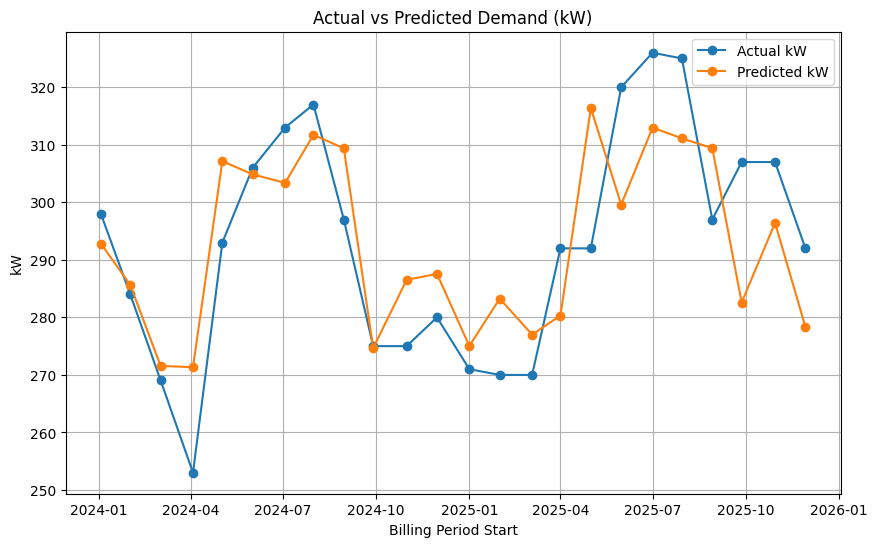

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = bt.copy()

# bring in actual kW if needed
if "kw_actual" not in df.columns:
    df = df.merge(
        detail_backtest[["start", "kw_actual"]],
        on="start",
        how="left"
    )

# create summer
df["month"] = pd.to_datetime(df["start"]).dt.month
df["summer"] = df["month"].isin([5, 6, 7, 8]).astype(int)

# actual kw
df["kw"] = pd.to_numeric(df["kw_actual"], errors="coerce")

print("=== AVAILABLE COLUMNS ===")
print(df.columns.tolist())

print("\n=== DATA PREVIEW ===")
print(df[["start", "kw", "production_kg", "summer"]].head())

# Model 1: production only
X1 = df[["production_kg"]]
X1 = sm.add_constant(X1)
model_kw_1 = sm.OLS(df["kw"], X1, missing="drop").fit()

print("\n=== KW MODEL 1: production only ===")
print(model_kw_1.summary())

# Model 2: production + summer
X2 = df[["production_kg", "summer"]]
X2 = sm.add_constant(X2)
model_kw_2 = sm.OLS(df["kw"], X2, missing="drop").fit()

print("\n=== KW MODEL 2: production + summer ===")
print(model_kw_2.summary())

# predictions from model 2
df["kw_pred_reg"] = model_kw_2.predict(X2)

print("\n=== ACTUAL vs PREDICTED KW ===")
print(df[["start", "kw", "kw_pred_reg"]])

# plot
plt.figure(figsize=(10, 6))
plt.plot(df["start"], df["kw"], marker="o", label="Actual kW")
plt.plot(df["start"], df["kw_pred_reg"], marker="o", label="Predicted kW")
plt.title("Actual vs Predicted Demand (kW)")
plt.xlabel("Billing Period Start")
plt.ylabel("kW")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
X4 = df[["production_kg","summer","second_processing_share"]]
X4 = sm.add_constant(X4)

model_kw_4 = sm.OLS(df["kw"], X4).fit()

print(model_kw_4.summary())

                            OLS Regression Results                            
Dep. Variable:                     kw   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     9.182
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000504
Time:                        15:55:22   Log-Likelihood:                -94.855
No. Observations:                  24   AIC:                             197.7
Df Residuals:                      20   BIC:                             202.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================================================
# CONFIG
# =========================================================
UTIL_FILE = "/content/Powell Utilities.xlsx"
UTIL_SHEET = "Electricity"

PROD_2026_FILE = "/content/Quantity 2026.xlsx"
PROD_2026_SHEET = "Powell (Monthly)"

OUTPUT_FILE = "/content/powell_2026_bill_forecast_kw_regression.xlsx"

SUMMER_MONTHS = [5, 6, 7, 8]

# ---------------------------------------------------------
# FALLBACK KWH COEFFICIENTS
# only used if model_kwh is not already in memory
# replace these if your final chosen kWh model has different coefficients
# ---------------------------------------------------------
FALLBACK_KWH_B0 = -21430
FALLBACK_KWH_DAYS = 3199.3935
FALLBACK_KWH_PROD = 0.1528
FALLBACK_KWH_SUMMER = 8713.8851

# ---------------------------------------------------------
# NEW KW MODEL COEFFICIENTS (from your regression output)
# kW = 189.4282 + 0.0002*production_kg + 31.2430*summer
# ---------------------------------------------------------
KW_B0 = 189.4282
KW_PROD = 0.0002
KW_SUMMER = 31.2430

# =========================================================
# HELPERS
# =========================================================
def normalize_cols(df):
    df = df.copy()
    df.columns = (
        pd.Index(df.columns)
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.strip()
    )
    return df

def make_unique_columns(cols):
    seen = {}
    out = []
    for c in cols:
        if c not in seen:
            seen[c] = 0
            out.append(c)
        else:
            seen[c] += 1
            out.append(f"{c}.{seen[c]}")
    return out

def to_num(series):
    return pd.to_numeric(series, errors="coerce")

def pick_first_col(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find '{label}'. Tried {candidates}\nAvailable: {list(df.columns)}")

def detect_header_row(filepath, sheet_name, required_values=("JAN KG", "FEB KG"), max_rows=20):
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None)
    raw = raw.fillna("").astype(str)
    for i in range(min(max_rows, len(raw))):
        row_text = " | ".join(raw.iloc[i].tolist())
        if all(v.lower() in row_text.lower() for v in required_values):
            return i
    raise ValueError(
        f"Could not detect header row in {filepath} / {sheet_name} containing {required_values}"
    )

def month_overlap_days(period_start, period_end, month_start, month_end):
    overlap_start = max(period_start, month_start)
    overlap_end = min(period_end, month_end)
    if overlap_start > overlap_end:
        return 0
    return (overlap_end - overlap_start).days + 1

# =========================================================
# 1) LOAD ACTUAL BILL HISTORY
# =========================================================
bill = pd.read_excel(UTIL_FILE, sheet_name=UTIL_SHEET)
bill = normalize_cols(bill)
bill.columns = make_unique_columns(bill.columns)

start_col = pick_first_col(bill, ["Start Date"], "Start Date")
end_col = pick_first_col(bill, ["End Date"], "End Date")
days_col = pick_first_col(bill, ["Days"], "Days")
basic_col = pick_first_col(bill, ["Basic Charges (Days x rate)", "Basic Charges"], "Basic Charges")
kwh_col = pick_first_col(bill, ["Energy Used", "Energy Used.1", "Energy Used (kWh)", "kWh"], "Energy Used")
kw_col = pick_first_col(bill, ["Demand Registered"], "Demand Registered")
total_col = pick_first_col(bill, ["Total Due", "Total Due $", "Total Due $.1", "Total Due Amount"], "Total Due")

all_cols = list(bill.columns)
subtotal_cols = [c for c in all_cols if "subtotal" in c.lower()]

kwh_idx = all_cols.index(kwh_col)
energy_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kwh_idx:
        energy_subtotal_col = c
        break
if energy_subtotal_col is None:
    raise ValueError("Could not locate energy subtotal column.")

kw_idx = all_cols.index(kw_col)
demand_subtotal_col = None
for c in subtotal_cols:
    if all_cols.index(c) > kw_idx:
        demand_subtotal_col = c
        break
if demand_subtotal_col is None:
    raise ValueError("Could not locate demand subtotal column.")

gst_col = next((c for c in all_cols if "gst" in c.lower()), None)
transformer_col = next((c for c in all_cols if "transformer" in c.lower()), None)
rate_rider_col = next((c for c in all_cols if "deferral rate rider" in c.lower()), None)
trade_adj_col = next((c for c in all_cols if "trade income rate rider" in c.lower()), None)
credit_col = next((c for c in all_cols if "credit" in c.lower()), None)

bill[start_col] = pd.to_datetime(bill[start_col], errors="coerce")
bill[end_col] = pd.to_datetime(bill[end_col], errors="coerce")

num_cols = [
    days_col, basic_col, kwh_col, kw_col,
    energy_subtotal_col, demand_subtotal_col,
    gst_col, transformer_col, rate_rider_col,
    trade_adj_col, credit_col, total_col
]
for c in num_cols:
    if c is not None and c in bill.columns:
        bill[c] = to_num(bill[c])

bill = bill.dropna(subset=[start_col, end_col, total_col]).copy()
bill = bill.sort_values(start_col).reset_index(drop=True)
bill["days_int"] = bill[days_col].astype(int)

print("=== LAST 5 ACTUAL BILLS ===")
print(bill[[start_col, end_col, days_col, kwh_col, kw_col, total_col]].tail())

# =========================================================
# 2) BUILD 2025 TEMPLATE FOR RATES + OTHER CHARGES
# =========================================================
bill_2025 = bill[bill[start_col].dt.year == 2025].copy().reset_index(drop=True)
if len(bill_2025) == 0:
    raise ValueError("No 2025 bills found.")

bill_2025["energy_rate_template"] = (
    to_num(bill_2025[energy_subtotal_col]) / to_num(bill_2025[kwh_col])
)
bill_2025["demand_rate_template"] = (
    to_num(bill_2025[demand_subtotal_col]) / to_num(bill_2025[kw_col])
)
bill_2025["basic_per_day_template"] = (
    to_num(bill_2025[basic_col]) / to_num(bill_2025[days_col])
)

bill_2025["transformer_template"] = (
    to_num(bill_2025[transformer_col]).fillna(0) if transformer_col else 0
)
bill_2025["rate_rider_template"] = (
    to_num(bill_2025[rate_rider_col]).fillna(0) if rate_rider_col else 0
)
bill_2025["trade_adj_template"] = (
    to_num(bill_2025[trade_adj_col]).fillna(0) if trade_adj_col else 0
)
bill_2025["credit_template"] = (
    to_num(bill_2025[credit_col]).fillna(0) if credit_col else 0
)

energy_rate_2026 = bill_2025["energy_rate_template"].median()
demand_rate_2026 = bill_2025["demand_rate_template"].median()
basic_per_day_2026 = bill_2025["basic_per_day_template"].median()

print("\n=== 2025 TEMPLATE CHARGES ===")
print(
    bill_2025[[
        start_col, end_col, days_col,
        "energy_rate_template", "demand_rate_template", "basic_per_day_template",
        "transformer_template", "rate_rider_template", "trade_adj_template", "credit_template"
    ]]
)

print("\n=== 2026 RATE TEMPLATE FROM 2025 ACTUALS ===")
print(f"Energy rate ($/kWh): {energy_rate_2026:.6f}")
print(f"Demand rate ($/kW) : {demand_rate_2026:.6f}")
print(f"Basic rate ($/day) : {basic_per_day_2026:.6f}")

# =========================================================
# 3) BUILD 2026 BILLING CALENDAR
# use 2025 cycle lengths starting from 2025-12-31
# =========================================================
cycle_lengths = bill_2025["days_int"].tolist()

forecast_periods = []
current_start = pd.Timestamp("2025-12-31")
cycle_idx = 0

while len(forecast_periods) < 12:
    days_this = cycle_lengths[cycle_idx % len(cycle_lengths)]
    current_end = current_start + pd.Timedelta(days=days_this - 1)

    forecast_periods.append({
        "period_no": len(forecast_periods) + 1,
        "start": current_start,
        "end": current_end,
        "days": days_this
    })

    current_start = current_end + pd.Timedelta(days=1)
    cycle_idx += 1

forecast_2026 = pd.DataFrame(forecast_periods)

print("\n=== 2026 BILLING PERIODS ===")
print(forecast_2026)

# =========================================================
# 4) LOAD 2026 MONTHLY PRODUCTION BUDGET
# =========================================================
header_row_2026 = detect_header_row(
    PROD_2026_FILE,
    PROD_2026_SHEET,
    required_values=("JAN KG", "FEB KG"),
    max_rows=20
)

print(f"\nDetected 2026 monthly header row: {header_row_2026}")

prod_monthly = pd.read_excel(PROD_2026_FILE, sheet_name=PROD_2026_SHEET, header=header_row_2026)
prod_monthly = normalize_cols(prod_monthly)

print("\n=== 2026 MONTHLY COLUMNS ===")
print(prod_monthly.columns.tolist())

row_mask = prod_monthly.astype(str).apply(
    lambda r: r.str.contains("Grand Total", case=False, na=False).any(),
    axis=1
)
if row_mask.sum() == 0:
    raise ValueError("Could not find 'Grand Total (Includes Concentrate)' row.")

grand_row = prod_monthly.loc[row_mask].iloc[0]

months = ["JAN","FEB","MAR","APR","MAY","JUN","JUL","AUG","SEP","OCT","NOV","DEC"]
kg_cols = [f"{m} KG" for m in months]

missing = [c for c in kg_cols if c not in prod_monthly.columns]
if missing:
    raise ValueError(f"Missing expected monthly KG columns: {missing}")

monthly_budget = pd.DataFrame({
    "month": months,
    "production_kg_month": [pd.to_numeric(grand_row[c], errors="coerce") for c in kg_cols]
})

month_map = {
    "JAN": 1, "FEB": 2, "MAR": 3, "APR": 4,
    "MAY": 5, "JUN": 6, "JUL": 7, "AUG": 8,
    "SEP": 9, "OCT": 10, "NOV": 11, "DEC": 12
}

monthly_budget["month_num"] = monthly_budget["month"].map(month_map)
monthly_budget["month_start"] = pd.to_datetime(dict(year=2026, month=monthly_budget["month_num"], day=1))
monthly_budget["month_end"] = monthly_budget["month_start"] + pd.offsets.MonthEnd(0)
monthly_budget["days_in_month"] = monthly_budget["month_start"].dt.days_in_month
monthly_budget["kg_per_day"] = monthly_budget["production_kg_month"] / monthly_budget["days_in_month"]

print("\n=== 2026 MONTHLY PRODUCTION BUDGET ===")
print(monthly_budget[["month", "production_kg_month", "days_in_month", "kg_per_day"]])

# =========================================================
# 5) PRORATE MONTHLY PRODUCTION INTO BILLING PERIODS
# =========================================================
period_production = []

for _, p in forecast_2026.iterrows():
    total_kg = 0.0
    for _, m in monthly_budget.iterrows():
        overlap = month_overlap_days(p["start"], p["end"], m["month_start"], m["month_end"])
        total_kg += overlap * m["kg_per_day"]
    period_production.append(total_kg)

forecast_2026["production_kg"] = period_production
forecast_2026["month_num_start"] = forecast_2026["start"].dt.month
forecast_2026["summer"] = forecast_2026["month_num_start"].isin(SUMMER_MONTHS).astype(int)

print("\n=== 2026 BILLING PERIOD PRODUCTION (PRORATED) ===")
print(forecast_2026[["period_no", "start", "end", "days", "production_kg", "summer"]])

# =========================================================
# 6) PREDICT KWH
# =========================================================
if "model_kwh" in globals():
    X_2026 = forecast_2026[["days", "production_kg", "summer"]].copy()
    X_2026 = sm.add_constant(X_2026, has_constant="add")
    forecast_2026["kwh_pred"] = model_kwh.predict(X_2026)
    print("\nUsing model_kwh from memory.")
else:
    forecast_2026["kwh_pred"] = (
        FALLBACK_KWH_B0
        + FALLBACK_KWH_DAYS * forecast_2026["days"]
        + FALLBACK_KWH_PROD * forecast_2026["production_kg"]
        + FALLBACK_KWH_SUMMER * forecast_2026["summer"]
    )
    print("\nUsing fallback kWh coefficients.")

forecast_2026["kwh_pred"] = forecast_2026["kwh_pred"].clip(lower=0)

# =========================================================
# 7) PREDICT KW USING NEW REGRESSION MODEL
# =========================================================
forecast_2026["kw_pred"] = (
    KW_B0
    + KW_PROD * forecast_2026["production_kg"]
    + KW_SUMMER * forecast_2026["summer"]
)

# =========================================================
# 8) COPY EXACT 2025 OTHER-CHARGE BEHAVIOR BY PERIOD INDEX
# =========================================================
template_rows = bill_2025.reset_index(drop=True)
forecast_2026["template_idx"] = np.arange(len(forecast_2026)) % len(template_rows)

forecast_2026["basic_$"] = forecast_2026["days"] * basic_per_day_2026
forecast_2026["energy_$"] = forecast_2026["kwh_pred"] * energy_rate_2026
forecast_2026["demand_$"] = forecast_2026["kw_pred"] * demand_rate_2026

forecast_2026["transformer_$"] = forecast_2026["template_idx"].map(
    template_rows["transformer_template"].to_dict()
).fillna(0)

forecast_2026["rate_rider_$"] = forecast_2026["template_idx"].map(
    template_rows["rate_rider_template"].to_dict()
).fillna(0)

forecast_2026["trade_adj_$"] = forecast_2026["template_idx"].map(
    template_rows["trade_adj_template"].to_dict()
).fillna(0)

forecast_2026["credit_$"] = forecast_2026["template_idx"].map(
    template_rows["credit_template"].to_dict()
).fillna(0)

forecast_2026["pretax_$"] = (
    forecast_2026["basic_$"]
    + forecast_2026["energy_$"]
    + forecast_2026["demand_$"]
    + forecast_2026["transformer_$"]
    + forecast_2026["rate_rider_$"]
    + forecast_2026["trade_adj_$"]
    + forecast_2026["credit_$"]
)

forecast_2026["gst_$"] = forecast_2026["pretax_$"] * 0.05
forecast_2026["total_$"] = forecast_2026["pretax_$"] + forecast_2026["gst_$"]

# =========================================================
# 9) FINAL OUTPUT
# =========================================================
final_2026 = forecast_2026[[
    "period_no",
    "start",
    "end",
    "days",
    "template_idx",
    "production_kg",
    "summer",
    "kwh_pred",
    "kw_pred",
    "basic_$",
    "energy_$",
    "demand_$",
    "transformer_$",
    "rate_rider_$",
    "trade_adj_$",
    "credit_$",
    "pretax_$",
    "gst_$",
    "total_$"
]].copy()

print("\n=== 2026 BILL FORECAST ===")
print(final_2026)

print("\n=== 2026 ANNUAL TOTALS ===")
print(final_2026[[
    "production_kg",
    "kwh_pred",
    "kw_pred",
    "energy_$",
    "demand_$",
    "pretax_$",
    "gst_$",
    "total_$"
]].sum())

# =========================================================
# 10) EXPORT
# =========================================================
final_2026.to_excel(OUTPUT_FILE, index=False)
print(f"\nSaved to: {OUTPUT_FILE}")

=== LAST 5 ACTUAL BILLS ===
   Start Date   End Date  Days  Energy Used  Demand Registered   Total Due
19 2025-07-30 2025-08-28    30       129840              325.0  13809.4300
20 2025-08-29 2025-09-26    29       114000              297.0  12056.1915
21 2025-09-27 2025-10-29    33       130080              307.0  13809.4300
22 2025-10-30 2025-11-28    30       130080              307.0  12128.7700
23 2025-11-29 2025-12-30    32       117360              292.0  12218.7800

=== 2025 TEMPLATE CHARGES ===
   Start Date   End Date  Days  energy_rate_template  demand_rate_template  \
0  2025-01-01 2025-01-30    30                0.0653                 13.30   
1  2025-01-31 2025-03-03    32                0.0653                 13.30   
2  2025-03-04 2025-03-31    28                0.0653                 13.30   
3  2025-04-01 2025-04-30    30                0.0675                 13.75   
4  2025-05-01 2025-05-30    30                0.0675                 13.75   
5  2025-05-31 2025-06-3

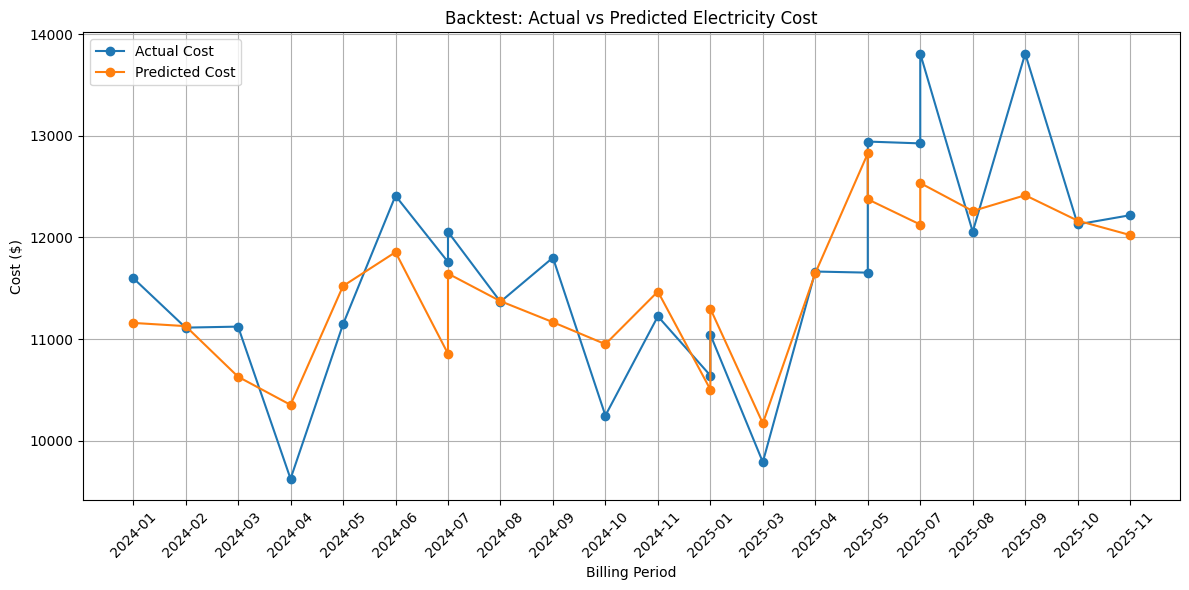

In [ ]:
detail_backtest["period_label"] = detail_backtest["start"].dt.strftime("%Y-%m")

plt.figure(figsize=(12, 6))
plt.plot(detail_backtest["period_label"], detail_backtest["total_actual_$"], marker="o", label="Actual Cost")
plt.plot(detail_backtest["period_label"], detail_backtest["total_pred_$"], marker="o", label="Predicted Cost")

plt.title("Backtest: Actual vs Predicted Electricity Cost")
plt.xlabel("Billing Period")
plt.ylabel("Cost ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

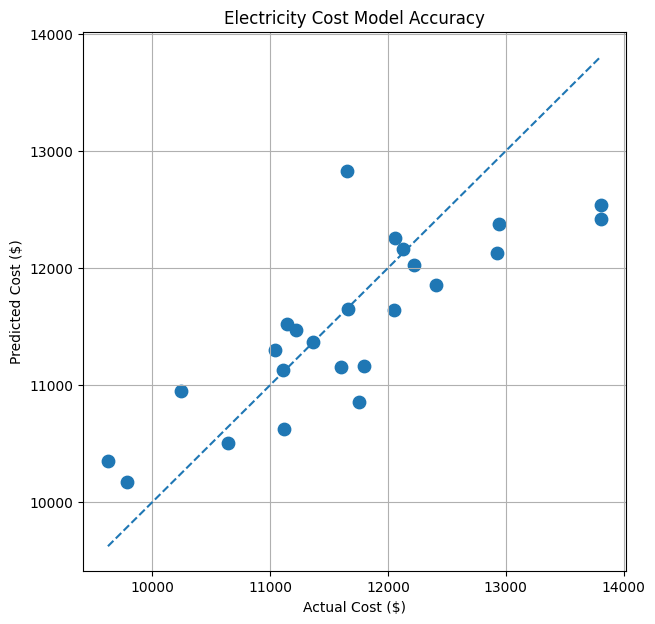

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

actual = detail_backtest["total_actual_$"]
pred = detail_backtest["total_pred_$"]

plt.figure(figsize=(7,7))

plt.scatter(actual, pred, s=80)

# 45 degree line
min_val = min(actual.min(), pred.min())
max_val = max(actual.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Electricity Cost Model Accuracy")
plt.xlabel("Actual Cost ($)")
plt.ylabel("Predicted Cost ($)")

plt.grid(True)

plt.show()

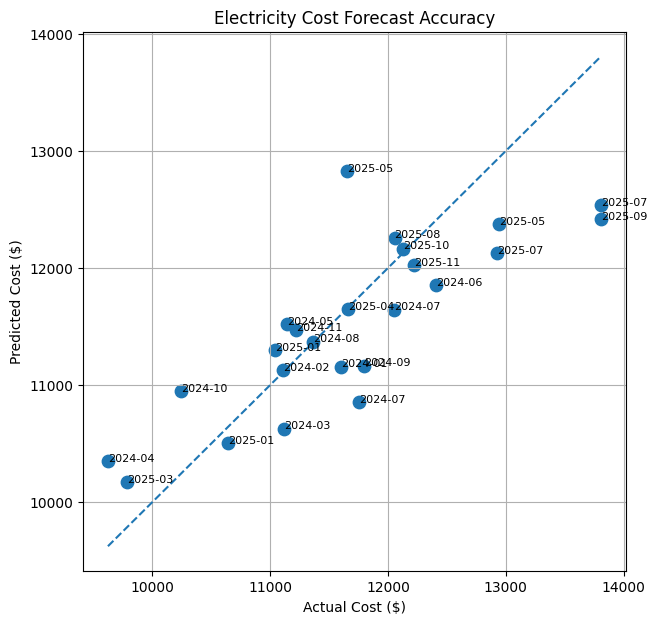

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(actual, pred, s=80)

for i, txt in enumerate(detail_backtest["start"].dt.strftime("%Y-%m")):
    plt.annotate(txt, (actual.iloc[i], pred.iloc[i]), fontsize=8)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("Electricity Cost Forecast Accuracy")
plt.xlabel("Actual Cost ($)")
plt.ylabel("Predicted Cost ($)")

plt.grid(True)

plt.show()